# Exercise 3: Time series with ARIMA

## Do not start the exercise until you fully understand the submission guidelines.

- The homework assignments are executed automatically.
- Failure to comply with the following instructions will result in a significant penalty.
- Appeals regarding your failure to read these instructions will be denied.
- Kind reminder: the homework assignments contribute 60% of the final grade.

## Read the following instructions carefully:

1. This Jupyter notebook contains all the step-by-step instructions needed for this exercise.
1. Write **efficient**, **vectorized** code whenever possible. Some calculations in this exercise may take several minutes when implemented efficiently, and might take much longer otherwise. Unnecessary loops will result in point deductions.
1. You are responsible for the correctness of your code and should add as many tests as you see fit to this jupyter notebook. Tests will not be graded nor checked.
1. You are allowed to use functions and methods from the [Python Standard Library](https://docs.python.org/3/library/).
1. Your code must run without errors. Use at least `numpy` 1.15.4. Any code that cannot run will not be graded.
1. Write your own code. Cheating will not be tolerated.
1. Submission includes a zip file that contains this notebook, with your ID as the file name. For example, `hw1_123456789_987654321.zip` if you submitted in pairs and `hw1_123456789.zip` if you submitted the exercise alone. The name of the notebook should follow the same structure.

Please use only a **zip** file in your submission.

---

---

## Please sign that you have read and understood the instructions:

316492776
318900016

---

---


In [1]:
!pip3 install statsmodels
!pip3 install seaborn
!pip3 install numpy
!pip3 install pandas
!pip3 install tqdm
!pip3 install scikit-learn
!pip3 install yfinance

In [2]:
# Import necessary libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yfinance as yf
from statsmodels.graphics import tsaplots
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.tsa.stattools import adfuller
from sklearn.linear_model import LinearRegression
sns.set_theme()
np.random.seed(42)

# Design your algorithm

Make sure to describe the algorithm, its limitations, and describe use-cases.


# Your implementations

You may add new cells, write helper functions or test code as you see fit.
Please use the cell below and include a description of your implementation.
Explain code design consideration, algorithmic choices and any other details you think is relevant to understanding your implementation.
Failing to explain your code will lead to point deductions.


Our implementation consists on ARMA with a "layer" of differentiation upon it which makes it ARIMA. We implemented this using inheritance,
which makes the code short, readable and easy to extend. We made sure that everything is vectorized and avoided loops as much as we could.
In terms of extra features we added:
- an option to manually pass the order of the ARIMA (p,d,q). By default these parameters are automatically deduced from the given data
- verbosity option for easy debugging
- the ability to calibrate the also the autocorrelation significance threshold. A large thrshold means less parameters hence a simpler model, at the risk of underfitting. Smaller threshold will cause more parameters and risk overfitting.

The implementation works as follows:
1. [ARIMA only, if d is not set] Differentiation is calculated - the decision whether to differentiate is taken based on the stationarity of the data, which we calculate using Augmented Dickey–Fuller test. We allow d to be only 0,1 or 2, since higher orders are very unlikely to occur naturally.
2. [if p,q are not set] We calculate p,q - as seen in class, we calculate ACF and PACF values, setting p,d according to where the correlation stops being significant.
3. We fit the AR model - using the last p observations to predict the next one, we fit a linear regressor to find the best $\phi_i$ for the given data.
4. We fit the MA model - using the last q *errors* (which are calculated by the difference between the actual value and the AR estimation) to predict the next error we decide what should be the correction to tweak the AR. We again use a (different) linear regressor to find the best $\theta_j$.
5. Now that the model is calibrated, we can predict the next values using $x_t=\sum_{i=1}^{p}{\phi_i x_{t-i}}+\sum_{j=1}^{q}{\theta_j w_{t-j}}$ with the parameters computed before and noise estimation in each prediction step.
6. [ARIMA only, if d > 0] Since we run on differentiated values we need to integrate back to the get the data and not its derivatives.

In [ ]:
class ARMACustom:
    def __init__(self, X: np.ndarray, order: tuple = (None, None), verbose: bool = True, ac_thresh: float = 0.1):
        self.verbose = verbose
        self.ac_thresh = ac_thresh
        self.X = X
        self.order = order
        self.set_params()

    def set_params(self):
        self.p, self.q = self.order

    def fit(self) -> None:
        self.find_p()
        self.find_q()
        self.fit_AR()
        self.fit_MA()

    def find_p(self) -> None:
        if self.p:
            return None
        X_pacf = pacf(self.X)
        p = np.argmax(np.abs(X_pacf) < self.ac_thresh)
        if self.verbose:
            print(f"p: {p}")
            print(f"pacf: {X_pacf}")
        assert 0 < p < len(self.X), "Cannot fit AR model to the given data"
        self.p = p

    def find_q(self) -> None:
        if self.q:
            return None
        X_acf = acf(self.X)
        q = np.argmax(np.abs(X_acf) < self.ac_thresh)
        if self.verbose:
            print(f"q: {q}")
            print(f"acf: {X_acf}")
        assert 0 < q < len(self.X), "Cannot fit MA model to the given data"
        self.q = q

    def fit_AR(self) -> None:
        data = np.vstack([self.X[i-self.p:i] for i in range(self.p, len(self.X))])
        reg = LinearRegression().fit(data, self.X[self.p: len(self.X)])
        self.phi_ = reg.coef_

    def fit_MA(self) -> None:
        w = np.zeros(len(self.X))
        for i in range(self.p, len(self.X)):
            ar = (self.phi_ * self.X[i-self.p:i]).sum()
            w[i] = self.X[i] - ar
        # we start from p+q since it is the first index that allows full derivation of errors looking back in time
        data = np.vstack([w[i-self.q:i] for i in range(self.q + self.p, len(self.X))])
        reg = LinearRegression().fit(data, self.X[self.q + self.p: len(self.X)])
        self.theta_ = reg.coef_
    
    def forecast(self, steps: int) -> np.ndarray:
        n = len(self.X)
        preds = np.concatenate([self.X, np.zeros(steps)])
        noise_preds = np.zeros_like(preds) # same size for vectorization
        for i in range(n - self.p, n + steps): # we go back p steps to estimate the noise
            ar = (self.phi_ * preds[i-self.p:i]).sum()
            ma = (self.theta_ * noise_preds[i-self.q:i]).sum()
            if i >= n:
                preds[i] = ar + ma  # we change only future indexes
            else:
                noise_preds[i] = preds[i] - ar - ma # will be 0 for new indexes, since we don't know X[i] for i >= n
        return preds[n:] 



class ARIMACustom(ARMACustom):
    def __init__(self, X: np.ndarray, order: tuple = (None, None, None), verbose = True, ac_thresh: float = 0.1, stationarity_conf: float = 0.05):
        super().__init__(X, order, verbose, ac_thresh)
        self.stationarity_conf = stationarity_conf

    
    def set_params(self):
        self.p, self.d, self.q = self.order

    def find_d(self) -> None:
        if self.d:
            return None
        for d in [0,1,2]: # no more than a second derivative
            p_val = adfuller(np.diff(self.X, d))[1] # p-value
            if p_val < self.stationarity_conf:
                if self.verbose:
                    print(f"d: {d}")
                self.d = d
                return None
        raise Exception("Data is not stationary, even after differentiating twice")
    
    def fit_I(self) -> None:
        self.Z = self.X # to maintain inheritance
        self.X = np.diff(self.X, self.d)
    
    def fit(self) -> None:
        self.find_d()
        self.fit_I()
        super().fit()

    def forecast(self, steps: int) -> np.ndarray:
        match self.d:
            case 0:
                return super().forecast(steps)
            case 1:
                return super().forecast(steps).cumsum() + self.Z[-1]
            case 2:
                return super().forecast(steps).cumsum().cumsum() + 2*self.Z[-1] - self.Z[-2]
            case _:
                raise Exception(f"self.d={self.d} which is invalid")

# A sample dataset

Please use the cell below to discuss your dataset choice and why it is appropriate (or not) for this algorithm.


For the sample data (Unit Test), we chose to use a sample dataset from Kaggle https://www.kaggle.com/datasets/prashant111/dataset. This is a simple dataset that contains a sample time series data with two columns:
1. date -> with a format of YYYY-MM-DD
2. value -> a sample numeric value

In [4]:
path = './sample_dataset.csv'

sample_dataset = pd.read_csv(path)

sample_dataset.head()

,date,value
0,1991-07-01,3.526591
1,1991-08-01,3.180891
2,1991-09-01,3.252221
3,1991-10-01,3.611003
4,1991-11-01,3.565869


In [5]:
X = sample_dataset["value"].values
a = ARIMACustom(X)

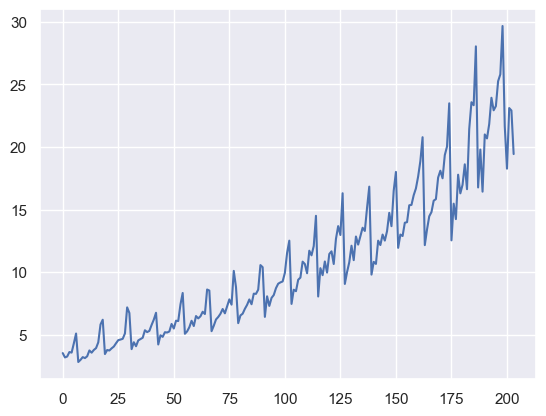

In [6]:
plt.plot(X)

c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


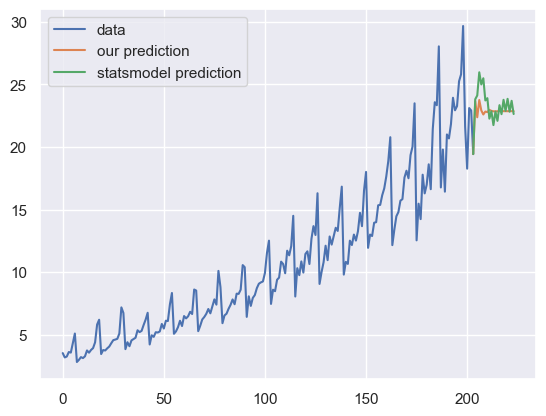

In [7]:
# our_model = ARIMACustom(X)
our_model = ARIMACustom(X, order=(4,1,3))
our_model.fit()
statsmodel_model = ARIMA(X, order=(our_model.p, our_model.d, our_model.q))
statsmodel_model = statsmodel_model.fit()
steps = 20

our_forecast = our_model.forecast(steps)
statsmodel_forecast = statsmodel_model.get_forecast(steps).predicted_mean
plt.plot(X, label="data")
plt.plot(range(len(X)-1,len(X)+steps), np.insert(our_forecast, 0, X[-1]), label="our prediction")
plt.plot(range(len(X)-1,len(X)+steps), np.insert(statsmodel_forecast, 0, X[-1]), label="statsmodel prediction")
plt.legend()

In [8]:
model = ARIMA(X, order=(8,2,3))
model_fit = model.fit()
steps = 20

c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [9]:
model_fit.params

array([-1.1521472 , -1.43355952, -0.95716187, -0.76519701, -0.63733586,
       -0.54325022, -0.46911353, -0.33629007, -0.3040949 ,  0.2439785 ,
       -0.93046319,  3.17037727])

In [10]:
Y = np.diff(X, 1)

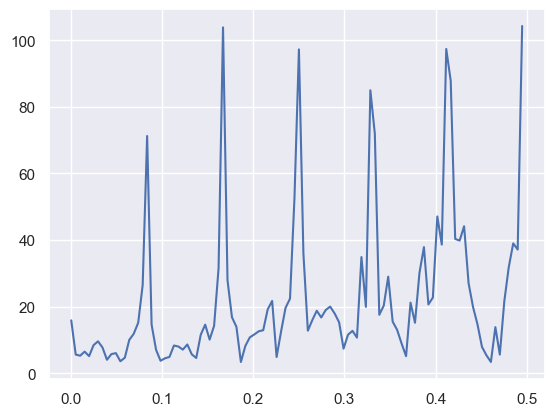

In [11]:
import numpy as np
from scipy.fftpack import fft

n = len(X)
freqs = np.fft.fftfreq(n)
fft_values = np.abs(fft(np.diff(X,1)))

plt.plot(freqs[:n//2], fft_values[:n//2])  # Plot only positive frequencies
plt.show()

In [12]:
fft_values[:n//2]

array([ 15.905149  ,   5.63352294,   5.28814947,   6.50914796,
         5.164294  ,   8.45616801,   9.60479997,   7.75813759,
         4.06930965,   5.77636183,   6.0661944 ,   3.62343095,
         4.68067989,  10.04528239,  11.87429769,  15.19894268,
        26.49989657,  71.25420541,  14.59926585,   7.06192397,
         3.7697075 ,   4.50981684,   4.91290629,   8.34839316,
         8.04416696,   7.11769621,   8.66190419,   5.69061044,
         4.59900996,  11.55236055,  14.61538701,  10.12676733,
        14.26217991,  31.55881177, 103.86410074,  27.97104687,
        16.83129203,  13.96464305,   3.39736536,   8.23030489,
        10.79984159,  11.6632275 ,  12.6206298 ,  12.93819423,
        19.16798263,  21.73478534,   4.89566133,  12.54486541,
        19.64802467,  22.40933379,  52.58783383,  97.25892386,
        36.064247  ,  12.79966995,  15.98800218,  18.78386544,
        16.76410162,  19.00834334,  20.03752282,  17.97611552,
        15.32121497,   7.40753943,  11.61116251,  12.74

In [13]:
Y

array([ -0.3457    ,   0.07133   ,   0.358782  ,  -0.045134  ,
         0.740502  ,   0.781964  ,  -2.273815  ,   0.171291  ,
         0.218969  ,  -0.077202  ,   0.142945  ,   0.46732782,
        -0.17907473,   0.21842564,   0.14728869,   0.4620405 ,
         1.42401825,   0.38151852,  -2.7412107 ,   0.32144987,
        -0.03800396,   0.17109602,   0.14428822,   0.26587838,
         0.24661903,   0.04647748,   0.05918926,   0.42599016,
         2.08612075,  -0.44848912,  -2.8901955 ,   0.55279799,
        -0.31873484,   0.46530417,   0.10497018,   0.10699145,
         0.59799814,  -0.14614983,   0.09719646,   0.47209086,
         0.43085132,   0.54489034,  -2.53341647,   0.73328211,
        -0.12630456,   0.37170929,  -0.02396708,   0.08595446,
         0.59853572,  -0.36454828,   0.62456422,  -0.02682039,
         1.32812508,   0.9128542 ,  -3.25965627,   0.19276082,
         0.33456961,   0.51316972,  -0.42113516,   0.79768849,
        -0.18628   ,   0.16690641,   0.36115365,  -0.17

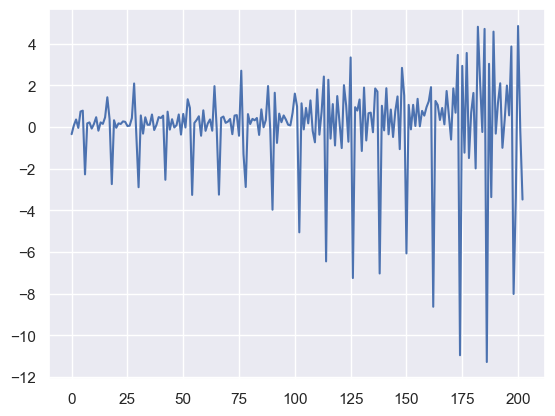

In [14]:
plt.plot(Y)

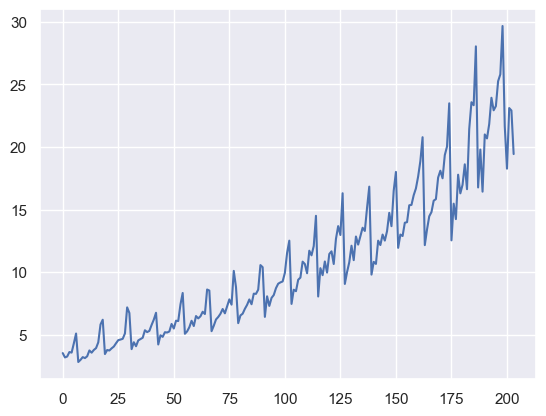

In [15]:
plt.plot(X)

In [16]:
date_filter = sample_dataset['date'].loc[sample_dataset['date'].str.endswith('01-01')]
date_filter

6      1992-01-01
18     1993-01-01
30     1994-01-01
42     1995-01-01
54     1996-01-01
66     1997-01-01
78     1998-01-01
90     1999-01-01
102    2000-01-01
114    2001-01-01
126    2002-01-01
138    2003-01-01
150    2004-01-01
162    2005-01-01
174    2006-01-01
186    2007-01-01
198    2008-01-01
Name: date, dtype: object

In [17]:
result = adfuller(sample_dataset.value.dropna())
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')

ADF Statistic: 3.145185689306738
p-value: 1.0


In [18]:
def plot_acf(values, title, samples_per_lag):
    
    plt.rcParams.update({'figure.figsize':(20, 5), 'figure.dpi':120})

    # Create subplot for ACF
    fig, axes = plt.subplots(1, 1, sharex=True)
    # Original Series ACF
    axes.plot(values)
    axes.set_title(title)

    # Create subplot for ACF
    fig, axes = plt.subplots(1, 2, sharex=True)
    tsaplots.plot_acf(values, lags = samples_per_lag, ax=axes[0])
    tsaplots.plot_pacf(values, lags = samples_per_lag, ax=axes[1])
    
    # 1st Differencing ACF
    fig, axes = plt.subplots(1, 1, sharex=True)
    axes.plot(values.diff())
    axes.set_title(f'{title} - 1st Order Differencing')

    # Create subplot for ACF
    fig, axes = plt.subplots(1, 2, sharex=True)
    tsaplots.plot_acf(values.diff().dropna(), lags = samples_per_lag, ax=axes[0])
    tsaplots.plot_pacf(values.diff().dropna(), lags = samples_per_lag, ax=axes[1])

    
    # 2nd Differencing ACF
    fig, axes = plt.subplots(1, 1, sharex=True)
    axes.plot(values.diff().diff())
    axes.set_title(f'{title} - 2nd Order Differencing')
    
    # Create subplot for ACF
    fig, axes = plt.subplots(1, 2, sharex=True)
    tsaplots.plot_acf(values.diff().diff().dropna(), lags = samples_per_lag, ax=axes[0])
    tsaplots.plot_pacf(values.diff().diff().dropna(), lags = samples_per_lag, ax=axes[1])
    
    plt.show()

# Arima demonstration

Demonstrate your Arima implementation.

Add plots and figures.

Please use the cell below to describe your results and tests.

Describe the difference between your implementation and the statsmodels implementation. Hint: you can look at the documentation.


In order to demonstrate the Arima implementation, we configured the following graphs and plots:

The first graphs sections focused on the stationarity and the correlation between the value, without making forecasts
1. A simple graph of the original dataset with the "date" as X-axis and "value" as Y-axis
2. Auto-correlation (ACF) graph of the original dataset - ACF is a method to find a correlation different time lags. This method seperates the data into some time lags (We used a month as a time lag -> Each lag contains 30 samples). The X-axis is the lag number (If a lag contains 30 samples, there are 12 lags in a period of year) and the Y-axis is the correlation between lag T and lag T-1. 1 -> Strong positive correlation (Increase with the same trend). -1 -> Strong negative correlation (Decrease after increase and vice versa) and 0 -> no any correlation
3. Partial auto-correlation (PACF) graph of the original dataset - PACF is similar to ACF but measures a dirrect correlation between lag T and lag T-1 with no attention to all the samples inside lag T-1 (Despite ACF that measures the correlation day-to-day, PACF measures the direct correlation between 1st day of month T-1 to 1st day of month T)
4. In addition, we include graphs of the 1st and 2nd differences of the original dataset, including the ACF and PACF values of the differences (In a 1st order difference, each value is v(i)-v(i-1) and in 2nd order difference, each value is v(i)-2v(i-1)+v(i-2)). That's in order to measure the stationarity between the values in the graph and the correlation between them
5. Each one of the 1st and 2nd differences graphs contains also the ACF and PACF values

The second part includes a forecasting of a various of examples with the following graphs:
1. Residuals / Density in order to measure the performance of the model (Can be thought as the loss values)
2. A graph that contains the original dataset values as a function of the time units, but with some differences:
   * The left part of the graph contains the first X% part of the dataset as it's original values (Train set). This data part is being fitted by the model
   * The right part of the graph contains the remaining (100-X)% part of the dataset with both it's original values (Test set) and it's forecast values: One forecast by the custom ARIMA model and the other by the StatsLib ARIMA model
   * The forecast values are also covered by a gray area which indicates the lower and upper standard deviation of the forecasted value. If the forecast is done well, the true value of the test set should be inside the standard deviation



In [19]:
def run_arima(dataset, param, date_label):
    print("Training based on:")
    for k, v in param.items():
        print(f"{k} -> {v}")
        
    model = ARIMA(dataset.value, order=param["order"])
    model_fit = model.fit()
    print(model_fit.summary())

    plt.rcParams.update({'figure.figsize':(20, 5), 'figure.dpi':120})
    residuals = pd.DataFrame(model_fit.resid)
    fig, ax = plt.subplots(1,2)
    residuals.plot(title="Residuals", ax=ax[0])
    residuals.plot(kind='kde', title='Density', ax=ax[1])
    plt.show()

    forecast = model_fit.predict()
    forecast_df = pd.DataFrame({'date':dataset['date'], 'value':forecast.values})
    print(type(forecast))
    plt.plot(list(dataset['date']), list(forecast), label = "forecast")
    plt.plot(list(dataset['date']), list(dataset['value']), label = "actual")
    plt.xticks(date_label, rotation=30)
    plt.legend()
    plt.title('Actual vs forecast')
    plt.show()

    return forecast_df

In [20]:
def run_arima_train_test(dataset, param, date_label):
    print("Train / Test based on:")

    split = int(len(dataset)*param["train_rate"])
    train_dataset = dataset[:split]
    test_dataset = dataset[split:]
    
    for k, v in param.items():
        print(f"{k} -> {v}")
    
    model = ARIMA(train_dataset.value, order=param["order"])
    model_fit = model.fit()
    print(model_fit.summary())

    custom_model = ARIMACustom(train_dataset.value.values, order=param["order"])
    custom_model.fit()
    
    plt.rcParams.update({'figure.figsize':(20, 5), 'figure.dpi':120})
    residuals = pd.DataFrame(model_fit.resid)
    fig, ax = plt.subplots(1,2)
    residuals.plot(title="Residuals", ax=ax[0])
    residuals.plot(kind='kde', title='Density', ax=ax[1])
    plt.show()

    forecast = model_fit.get_forecast((len(dataset) - split), alpha=0.05)  # 95% conf
    forecast_df = pd.DataFrame({'date':test_dataset['date'], 'value': forecast.predicted_mean})
    
    custom_forecast = custom_model.forecast((len(dataset) - split))
    custom_forecast_df = pd.DataFrame({'date':test_dataset['date'], 'value': custom_forecast})
    
    #print(type(forecast))
    plt.plot(list(train_dataset['date']), list(train_dataset['value']), label = "training")
    plt.plot(list(test_dataset['date']), list(test_dataset['value']), label = "actual")
    plt.plot(list(forecast_df['date']), list(forecast_df['value']), label = "forecast - statsmodel")
    plt.plot(list(custom_forecast_df['date']), list(custom_forecast_df['value']), label = "forecast - custom")
    plt.fill_between(list(forecast_df['date']), 
                 forecast.conf_int().iloc[:, 0], 
                 forecast.conf_int().iloc[:, 1], 
                 color='k', alpha=.15)
    plt.xticks(date_label, rotation=30)
    plt.legend()
    plt.title('Training / Actual vs forecast')
    plt.show()

    return forecast_df

ACF / PACF of original data


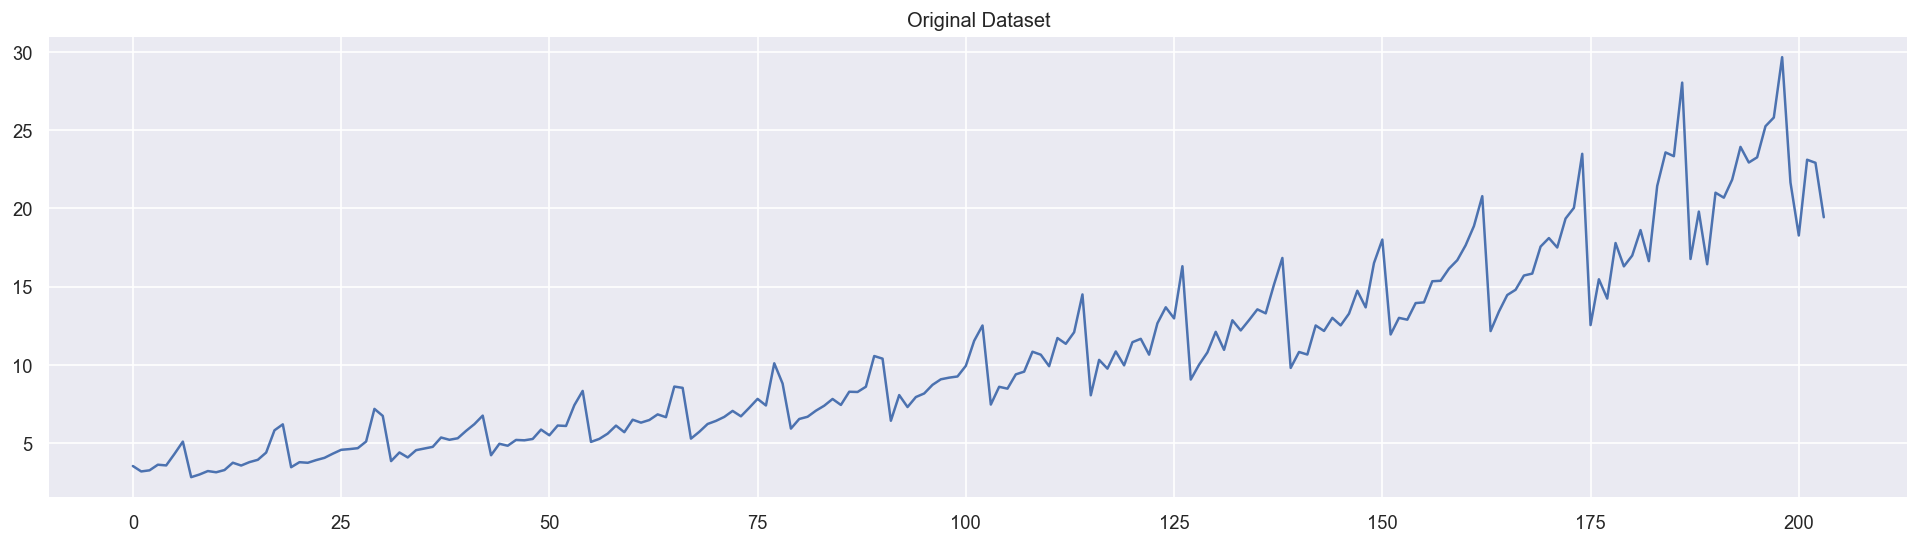

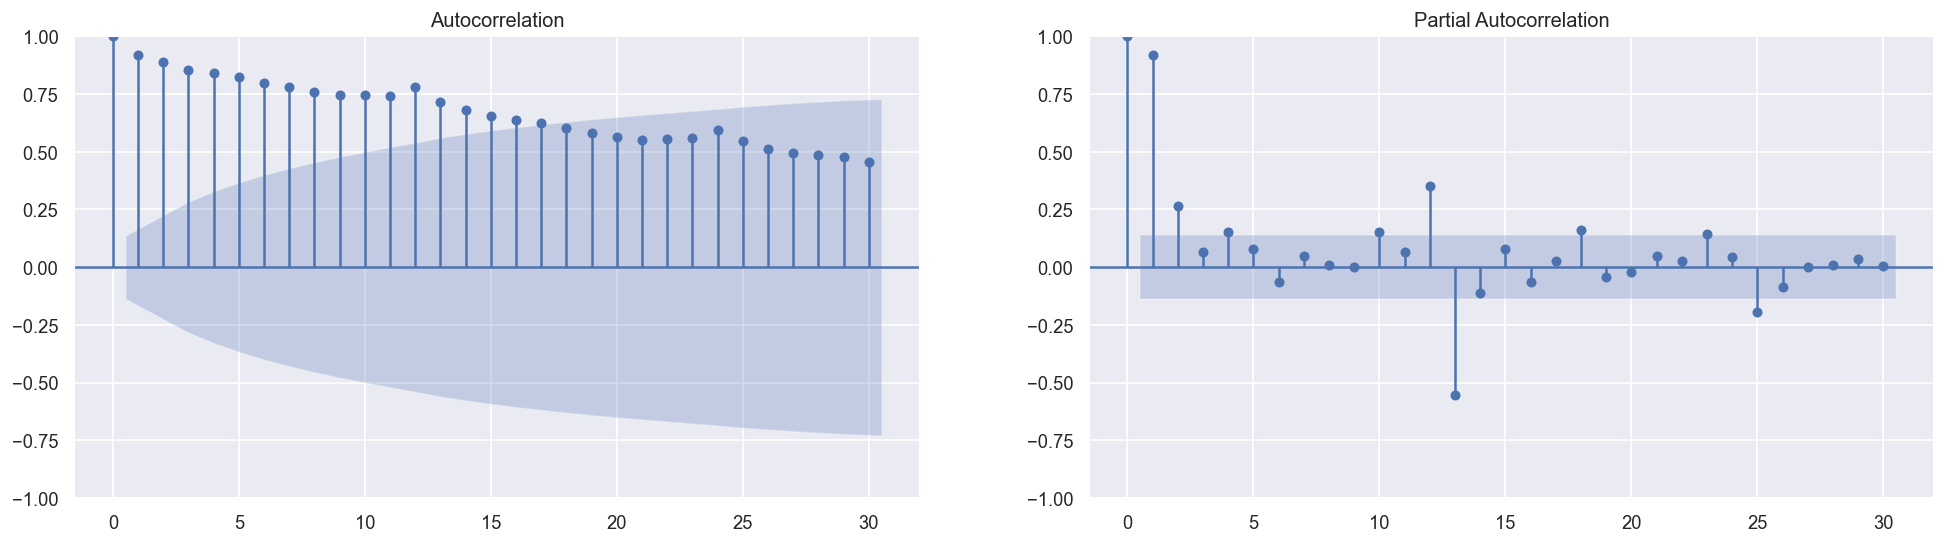

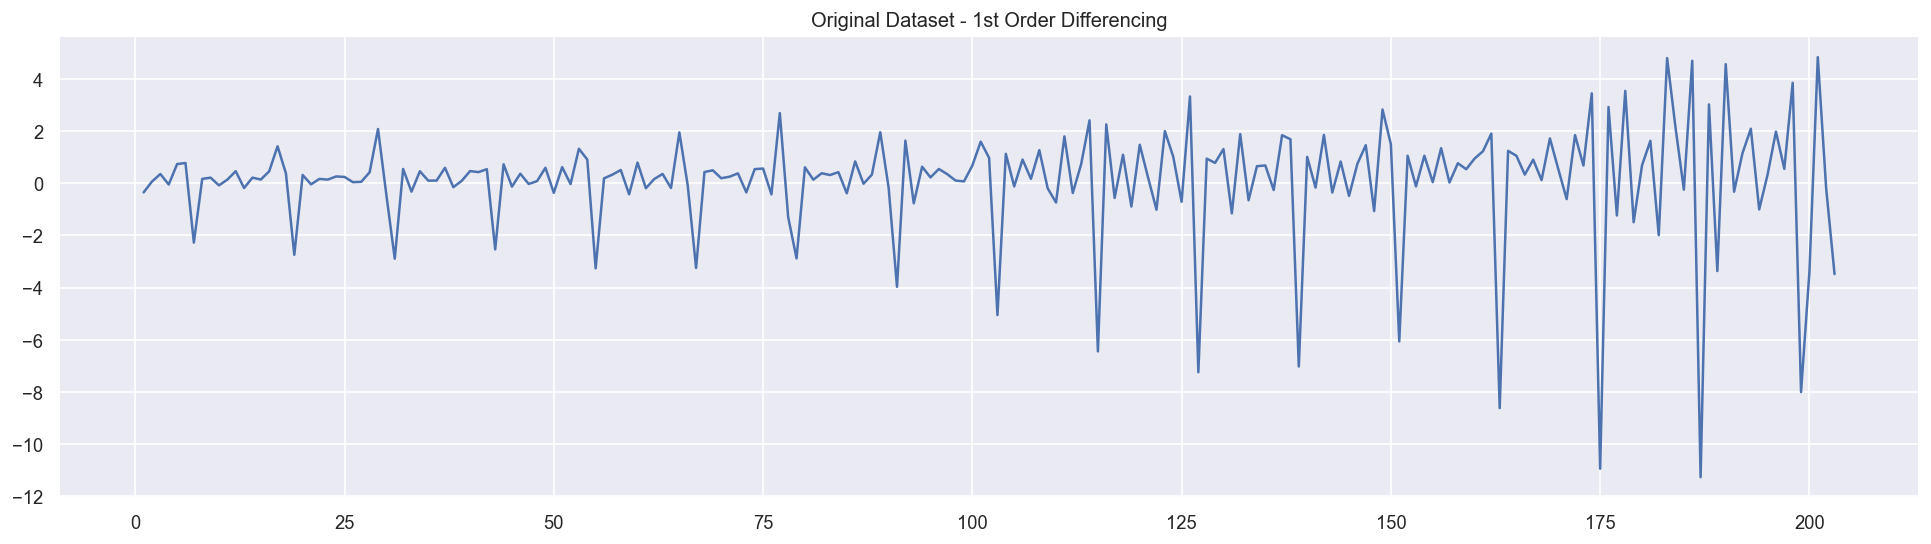

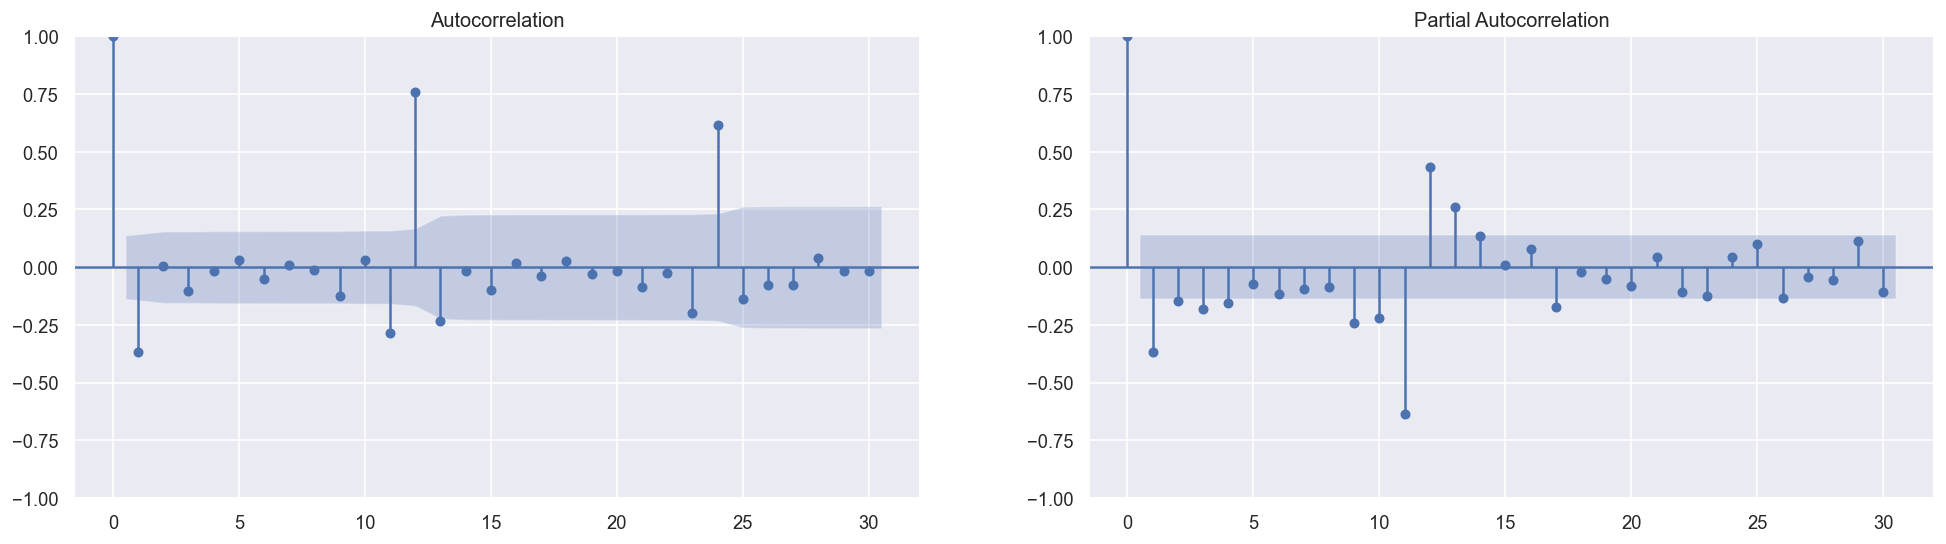

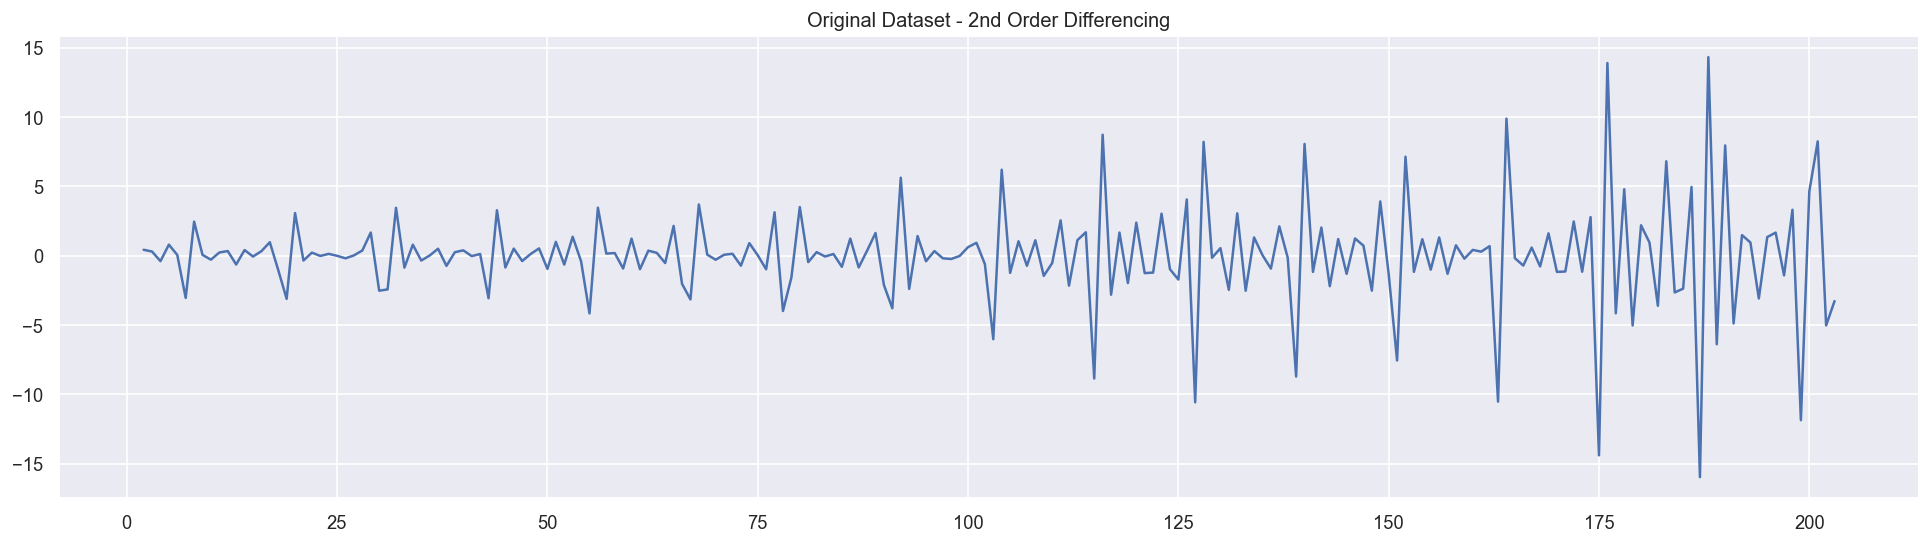

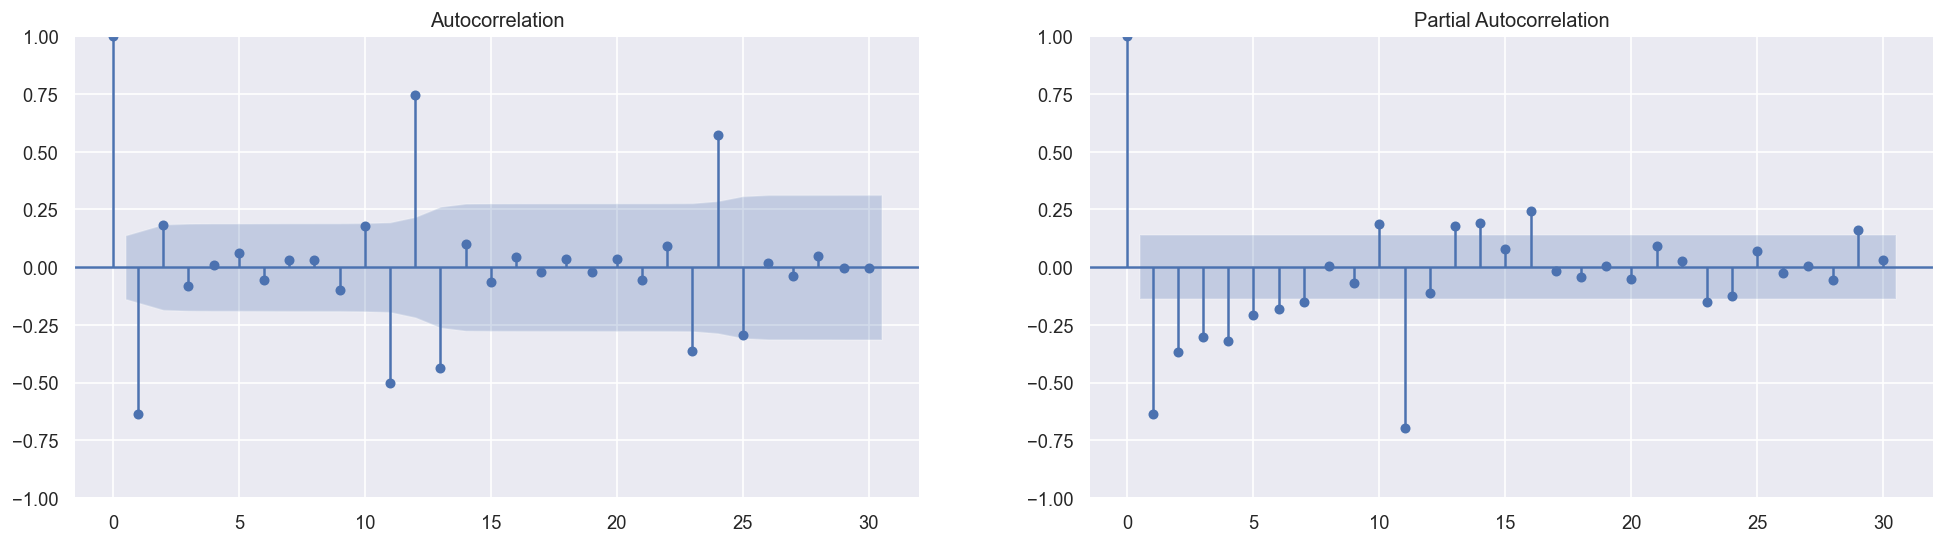

6      1992-01-01
18     1993-01-01
30     1994-01-01
42     1995-01-01
54     1996-01-01
66     1997-01-01
78     1998-01-01
90     1999-01-01
102    2000-01-01
114    2001-01-01
126    2002-01-01
138    2003-01-01
150    2004-01-01
162    2005-01-01
174    2006-01-01
186    2007-01-01
198    2008-01-01
Name: date, dtype: object
Train / Test based on:
order -> (3, 2, 1)
train_rate -> 0.7
                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                  142
Model:                 ARIMA(3, 2, 1)   Log Likelihood                -251.244
Date:                Thu, 13 Mar 2025   AIC                            512.488
Time:                        15:51:10   BIC                            527.196
Sample:                             0   HQIC                           518.465
                                - 142                                         
Covariance Type:                  opg                  

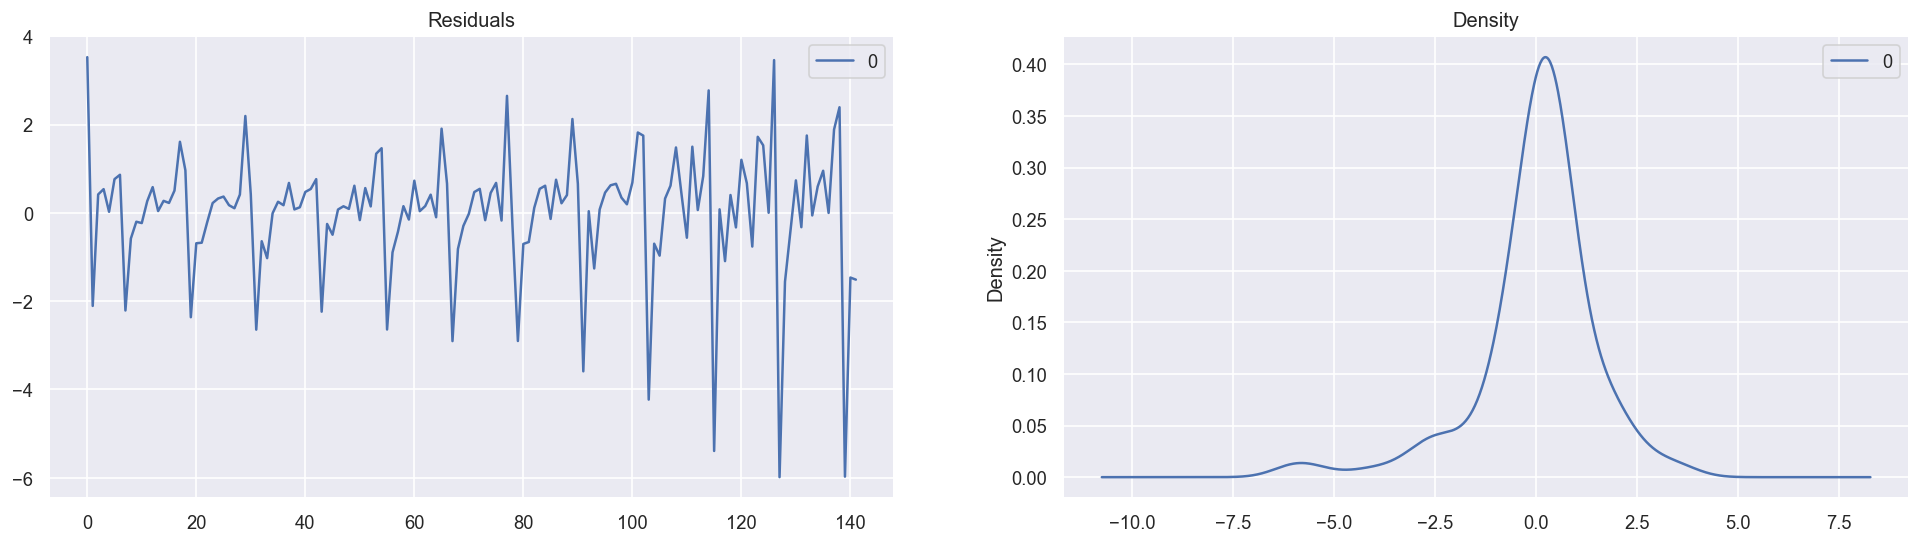

c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['alpha']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


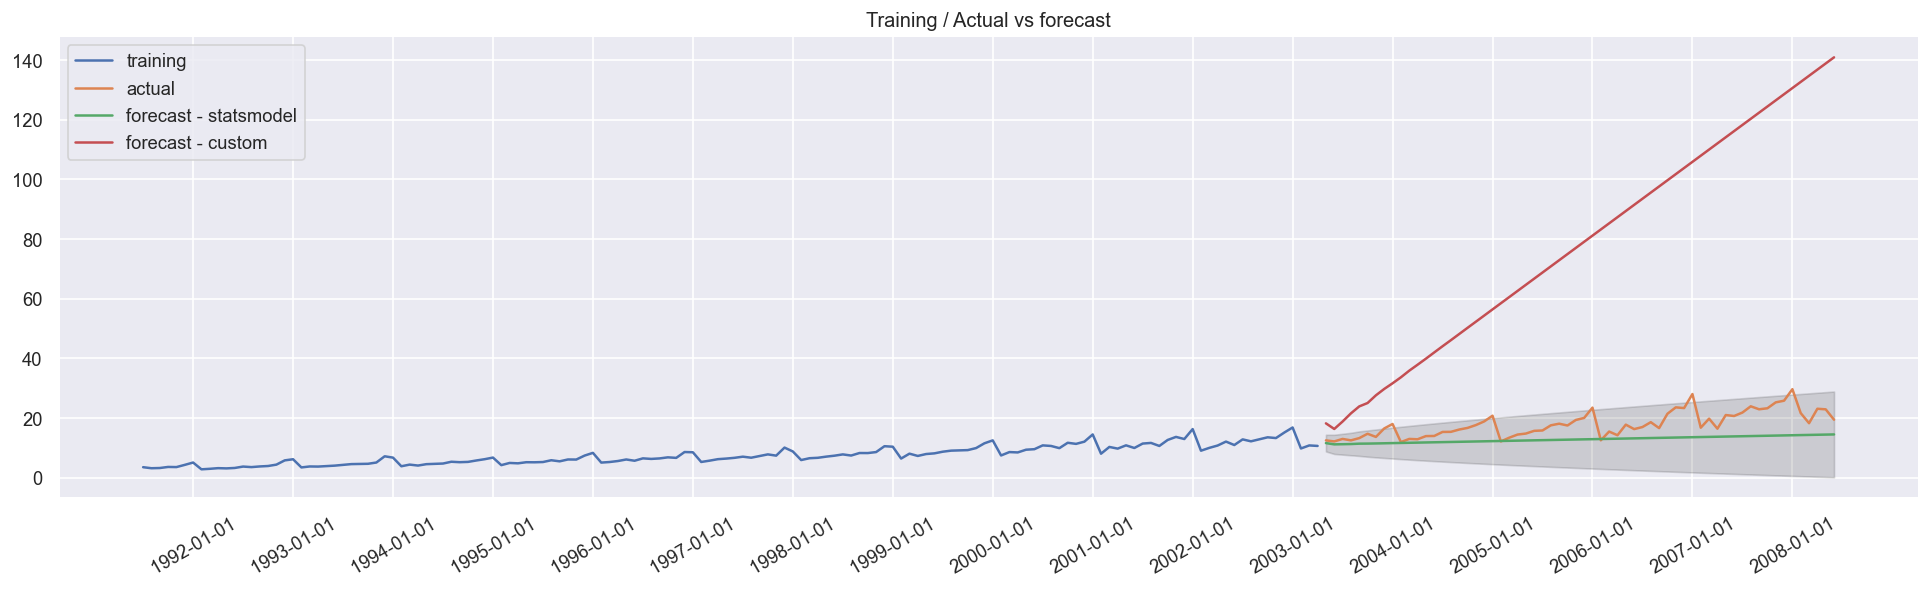

Train / Test based on:
order -> (1, 1, 2)
train_rate -> 0.7
                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                  142
Model:                 ARIMA(1, 1, 2)   Log Likelihood                -242.893
Date:                Thu, 13 Mar 2025   AIC                            493.786
Time:                        15:51:14   BIC                            505.581
Sample:                             0   HQIC                           498.579
                                - 142                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2453      0.591      0.415      0.678      -0.914       1.404
ma.L1         -0.8013      0.569     -1.408      0.159      -1.917     

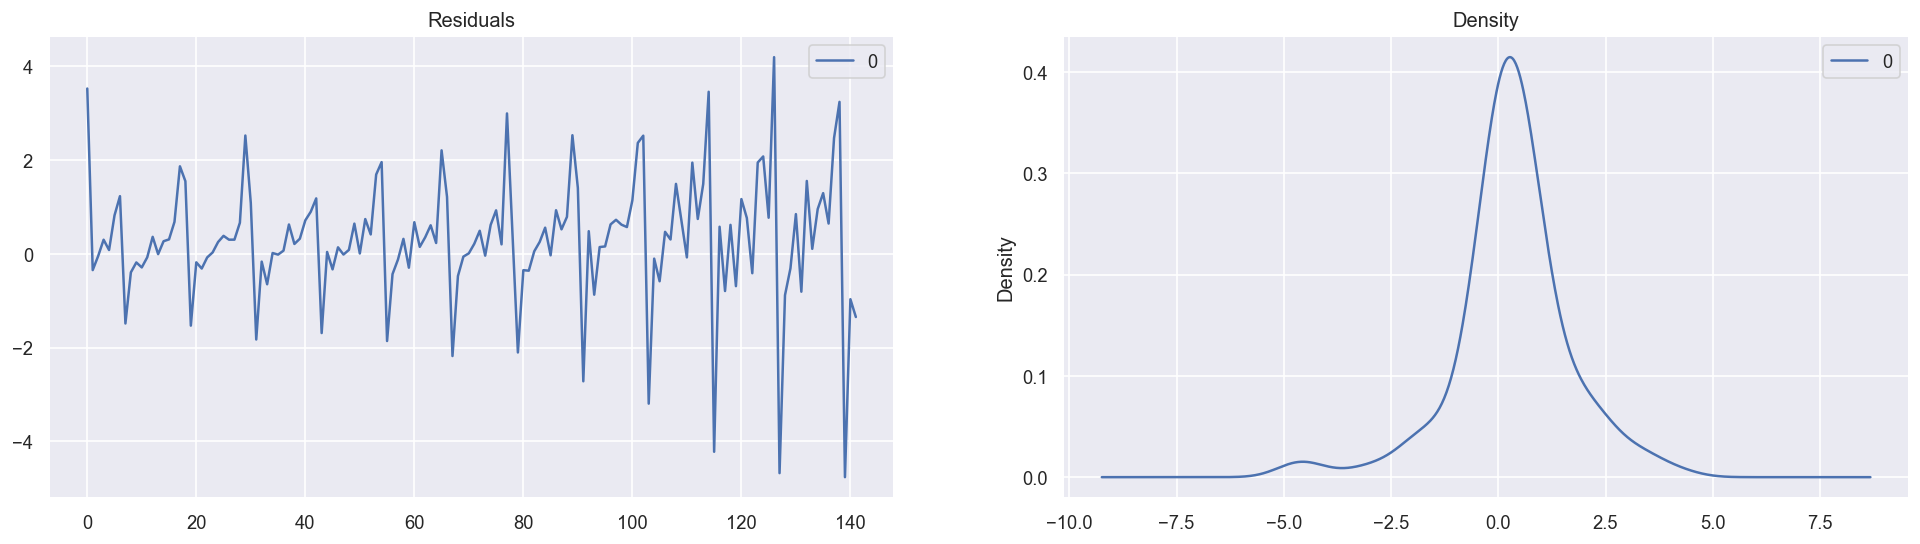

c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['alpha']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


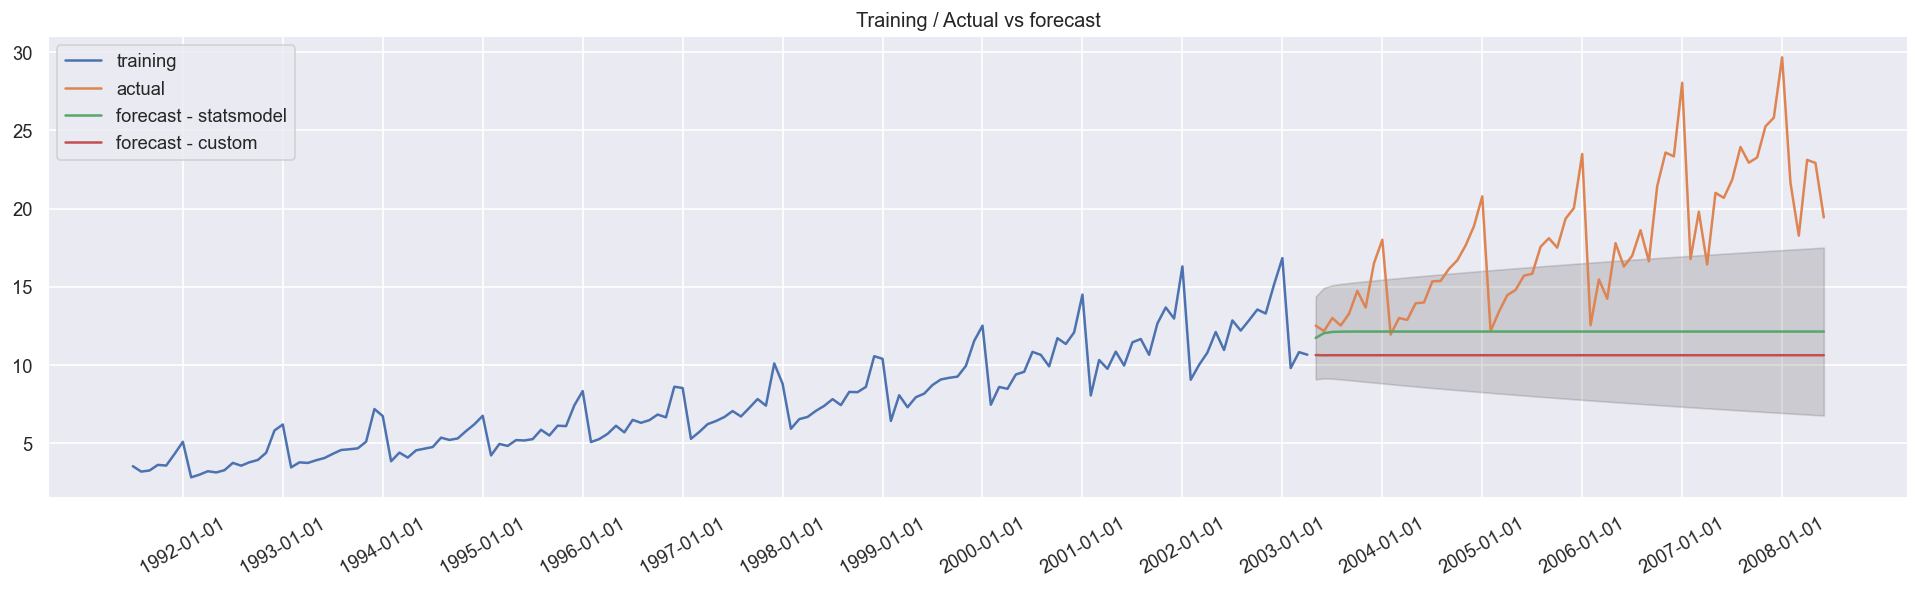

Train / Test based on:
order -> (1, 1, 1)
train_rate -> 0.7
                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                  142
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -242.904
Date:                Thu, 13 Mar 2025   AIC                            491.808
Time:                        15:51:18   BIC                            500.654
Sample:                             0   HQIC                           495.402
                                - 142                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2844      0.185      1.539      0.124      -0.078       0.647
ma.L1         -0.8431      0.089     -9.435      0.000      -1.018     

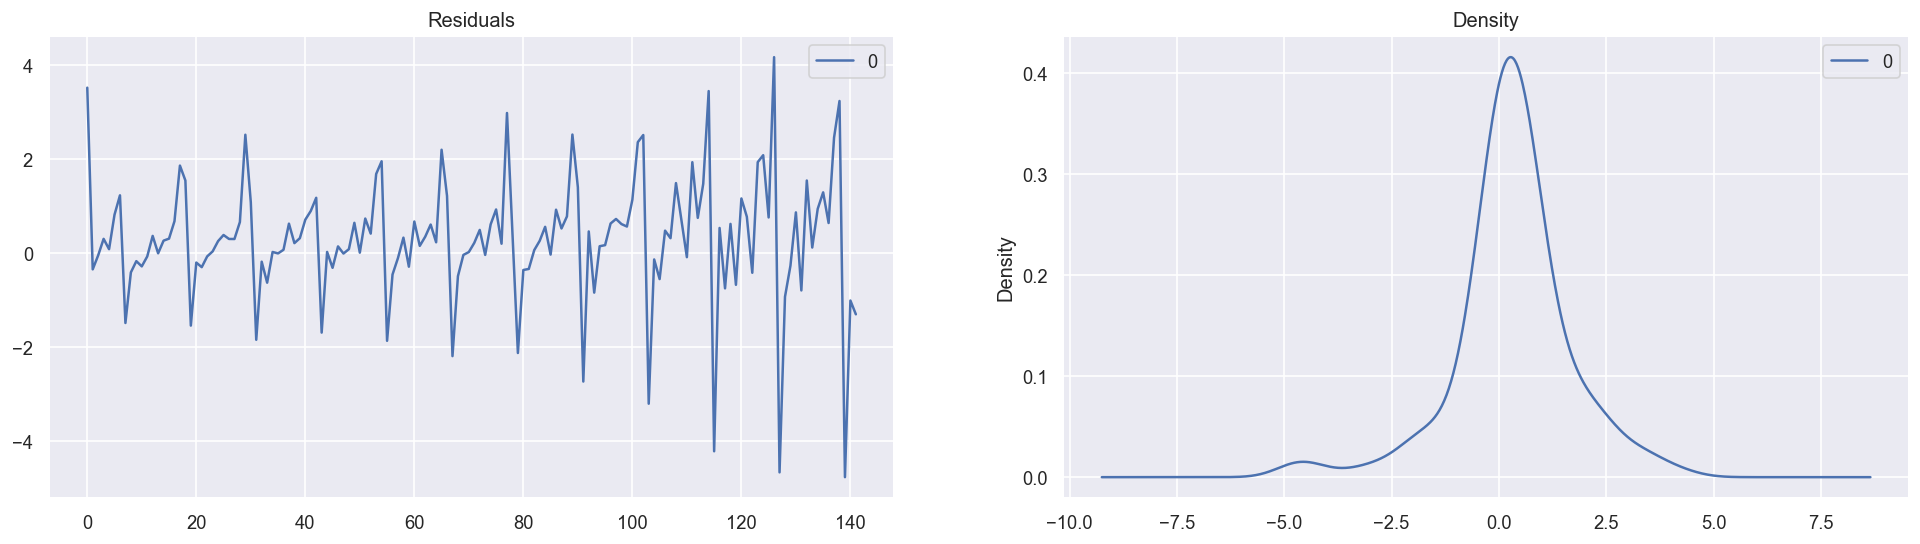

c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['alpha']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


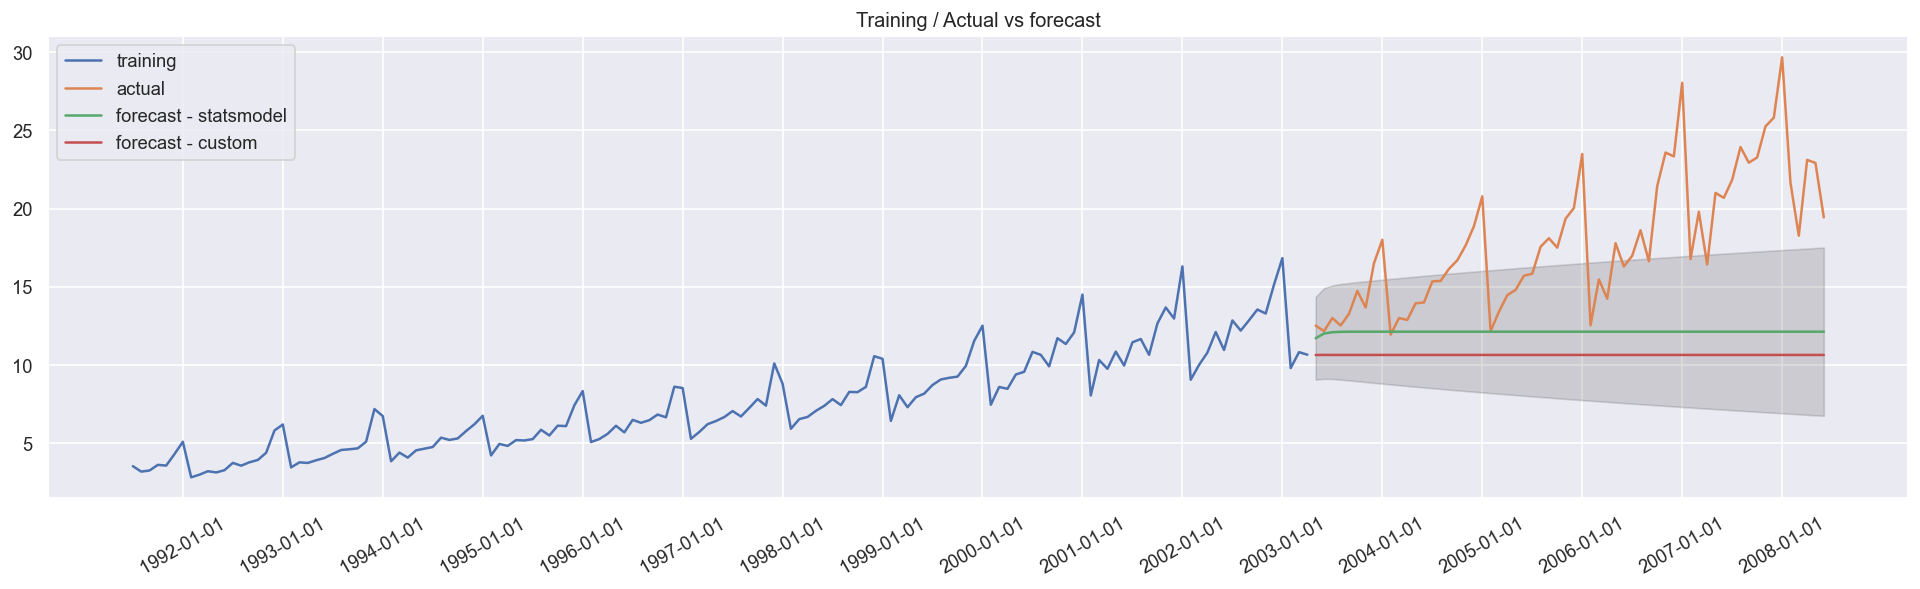

In [21]:
hyperparams = [{
    "order": (3, 2, 1),
     "train_rate": 0.7
},{
    "order": (1, 1, 2),
     "train_rate": 0.7
},{
    "order": (1, 1, 1),
     "train_rate": 0.7
}]

# Monthly correlation
SAMPLES_PER_LAG = 30

print("ACF / PACF of original data")
plot_acf(sample_dataset.value, "Original Dataset", SAMPLES_PER_LAG)
print("==================================================================================================")
date_label = sample_dataset['date'].loc[sample_dataset['date'].str.endswith('01-01')]

print(date_label)
for idx, param in enumerate(hyperparams):
    #predicted_dataset = run_arima(sample_dataset, param, date_label)
    #print("==================================================================================================")
    predicted_dataset = run_arima_train_test(sample_dataset, param, date_label)
    print("==================================================================================================")

# AMZN Dataset


We used the stock information of Amazon directly using the Yahoo Finance package (Not the static file provided in the exercise). And we made the following pre-process:
1. The "Date" field contained an ISO format "YYYY-MM-DD hh:mm:ss.ms" and we converted it just to YYYY-MM-DD
2. We made two measures base on this dataset: The first measure is the mean stock price per day ((High - Low) / 2) and the second one is the Volume per day
3. While printing the X-values in the graphs, in order to make it clean to read, we printed just yearly timestamps (We took the first commerce day of a fiscal year as an X label) + The first and last values

In [22]:
ticker = yf.Ticker('AMZN')

amzn_dataset_original = ticker.history(period="max").reset_index() 
amzn_dataset_original['Date'] = amzn_dataset_original['Date'].astype(str)
amzn_dataset_original['Date'] = amzn_dataset_original['Date'].str.split().str[0]

amzn_dataset_original.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,1997-05-15,0.121875,0.125000,0.096354,0.097917,1443120000,0.0,0.0
1,1997-05-16,0.098438,0.098958,0.085417,0.086458,294000000,0.0,0.0
2,1997-05-19,0.088021,0.088542,0.081250,0.085417,122136000,0.0,0.0
3,1997-05-20,0.086458,0.087500,0.081771,0.081771,109344000,0.0,0.0
4,1997-05-21,0.081771,0.082292,0.068750,0.071354,377064000,0.0,0.0


In [23]:
mean_list = np.mean( np.array([ amzn_dataset_original['Low'], amzn_dataset_original['High'] ]), axis=0 )
datasets = {
    #'open': pd.DataFrame({'date':amzn_dataset_original['Date'], 'value':amzn_dataset_original['Open']}),
    #'close': pd.DataFrame({'date':amzn_dataset_original['Date'], 'value':amzn_dataset_original['Close']}),
    #'high': pd.DataFrame({'date':amzn_dataset_original['Date'], 'value':amzn_dataset_original['High']}),
    #'low': pd.DataFrame({'date':amzn_dataset_original['Date'], 'value':amzn_dataset_original['Low']}),
    'mean': pd.DataFrame({'date':amzn_dataset_original['Date'], 'value':mean_list}),
    'volume': pd.DataFrame({'date':amzn_dataset_original['Date'], 'value':amzn_dataset_original['Volume']})
}

In [24]:
def get_date_labels_amzn(dataset):
    date_filter = dataset.loc[dataset['date'].str.endswith('01-02') ^ dataset['date'].str.endswith('01-03') ^ dataset['date'].str.endswith('01-04')]
    date_filter['year'] = date_filter['date'].str.split('-').str[0]
    date_filter.loc[0] = dataset.iloc[0]
    date_filter.at[0, 'year'] = 'first'
    date_filter.loc[len(dataset)-1] = dataset.iloc[-1]
    date_filter.at[len(dataset)-1, 'year'] = 'last'
    date_filter = date_filter.drop_duplicates(subset=['year'], keep='first')
    date_filter = date_filter.loc[:, 'date']
    date_filter = date_filter.sort_index()
    
    return date_filter

C:\Users\Roey\AppData\Local\Temp\ipykernel_18592\2499829597.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  date_filter['year'] = date_filter['date'].str.split('-').str[0]
C:\Users\Roey\AppData\Local\Temp\ipykernel_18592\2499829597.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  date_filter.loc[0] = dataset.iloc[0]
C:\Users\Roey\AppData\Local\Temp\ipykernel_18592\2499829597.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/use

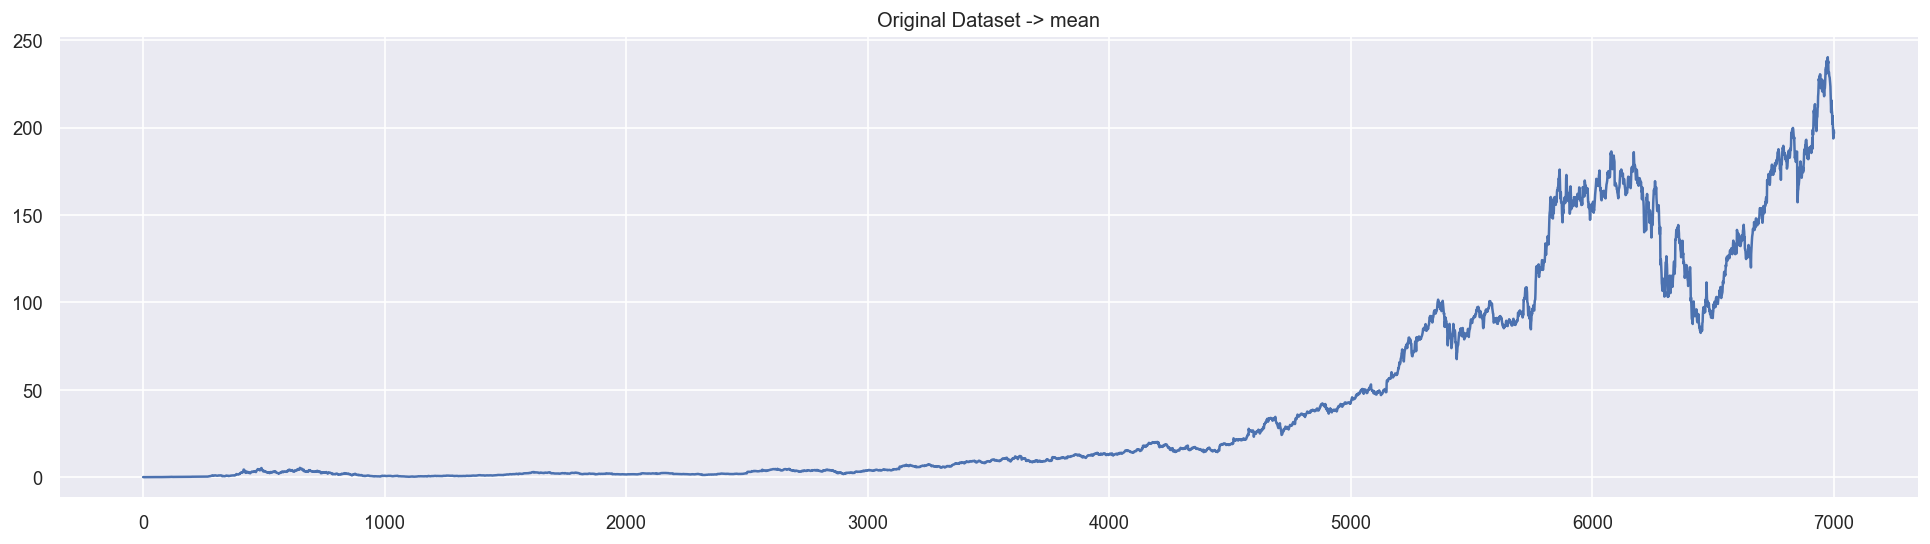

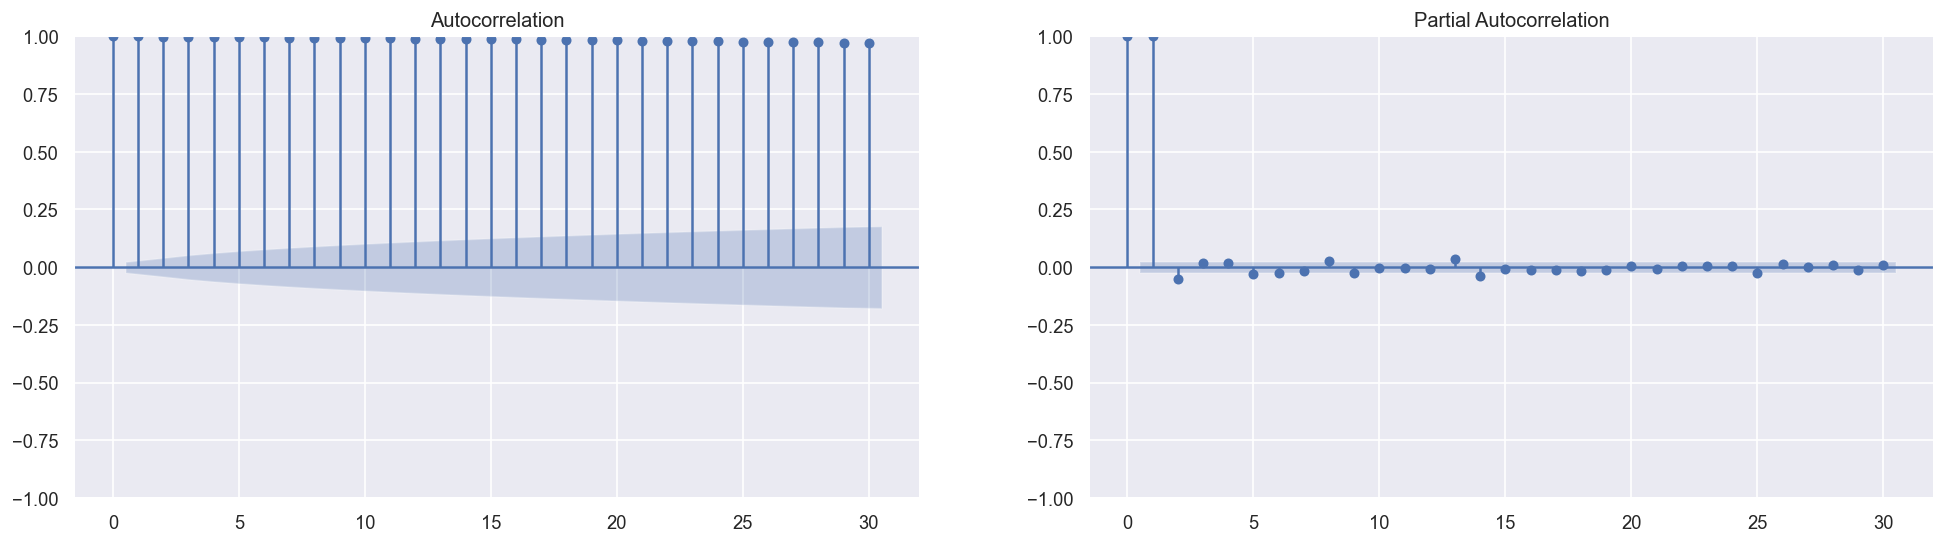

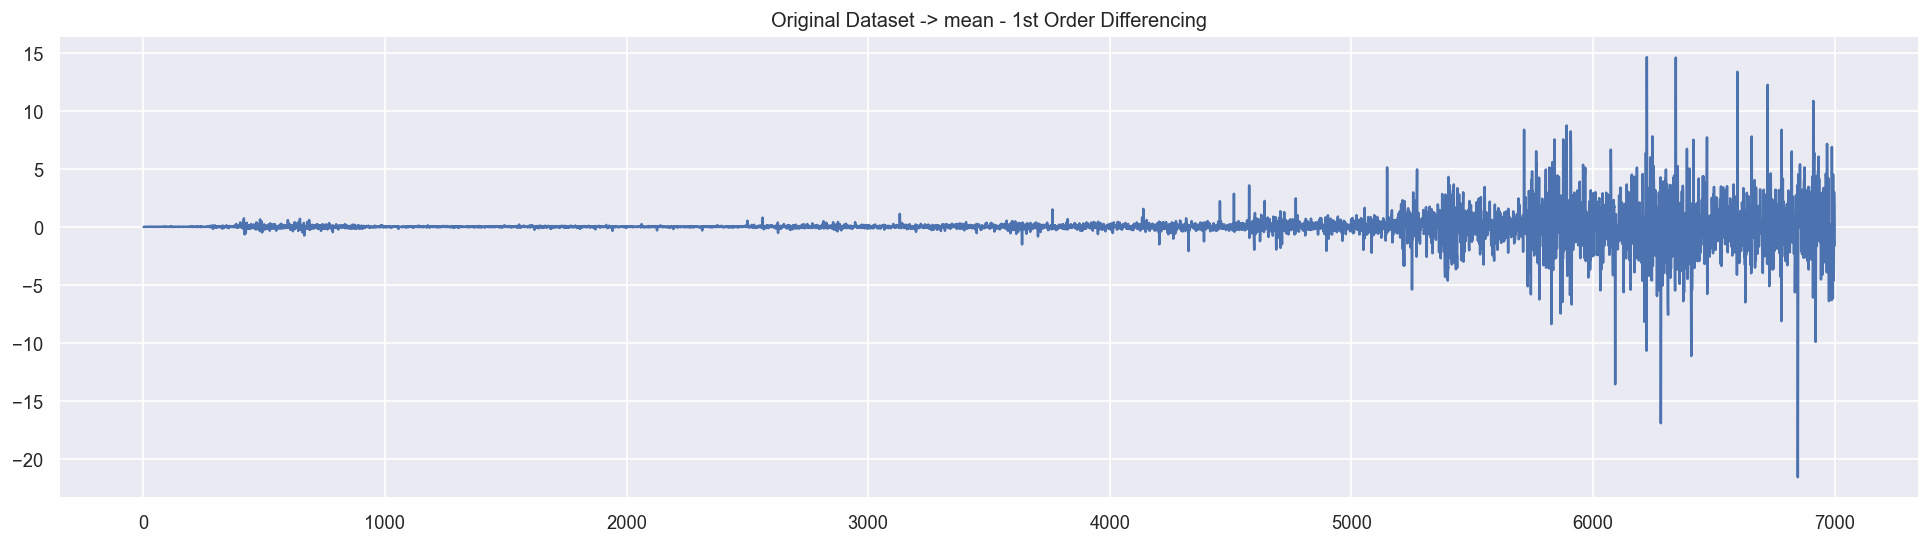

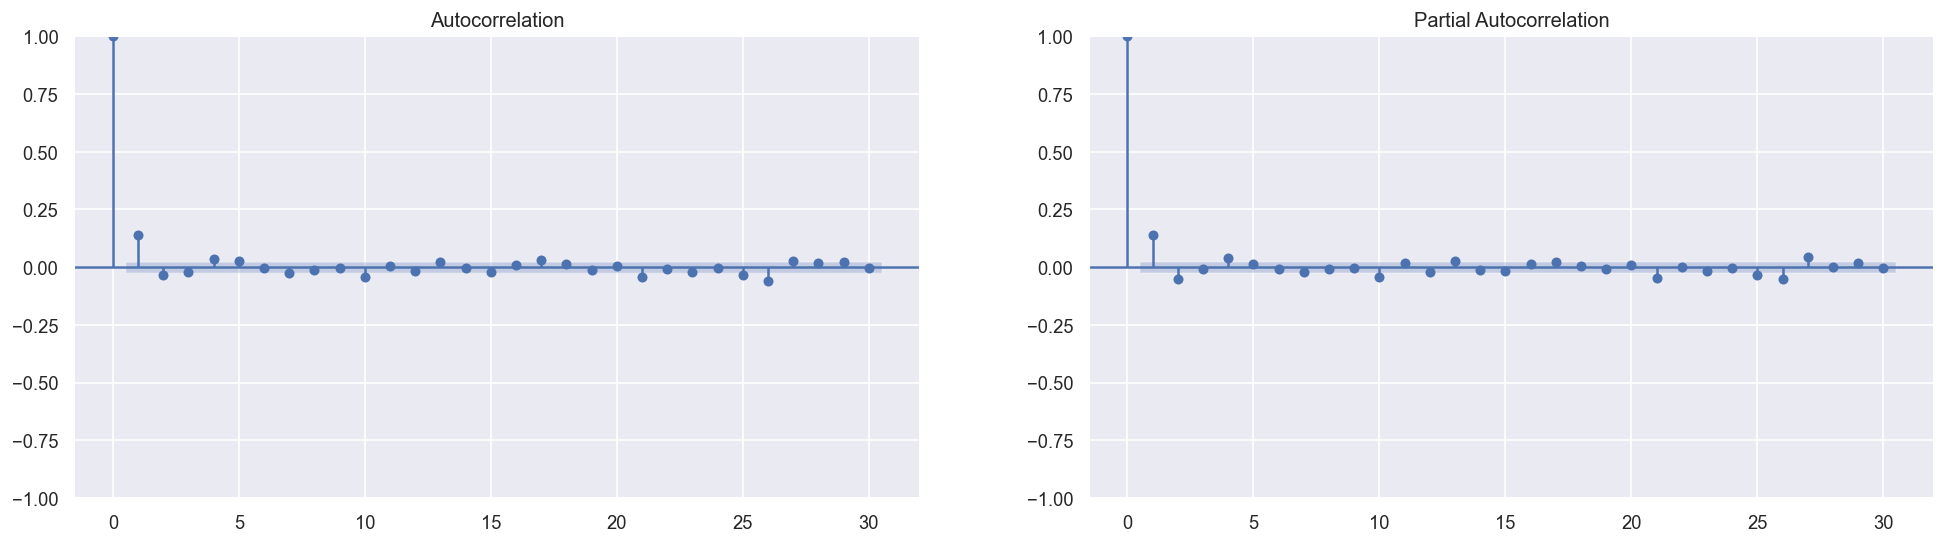

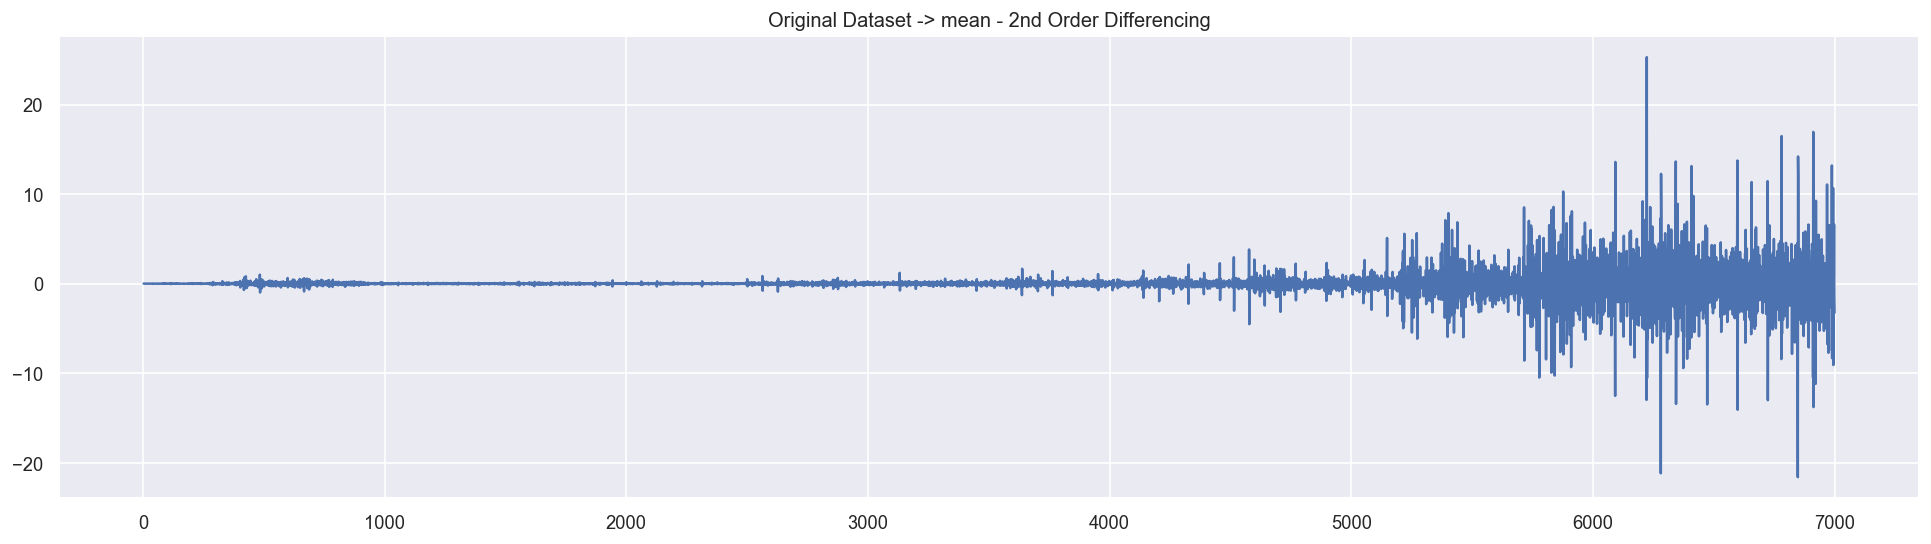

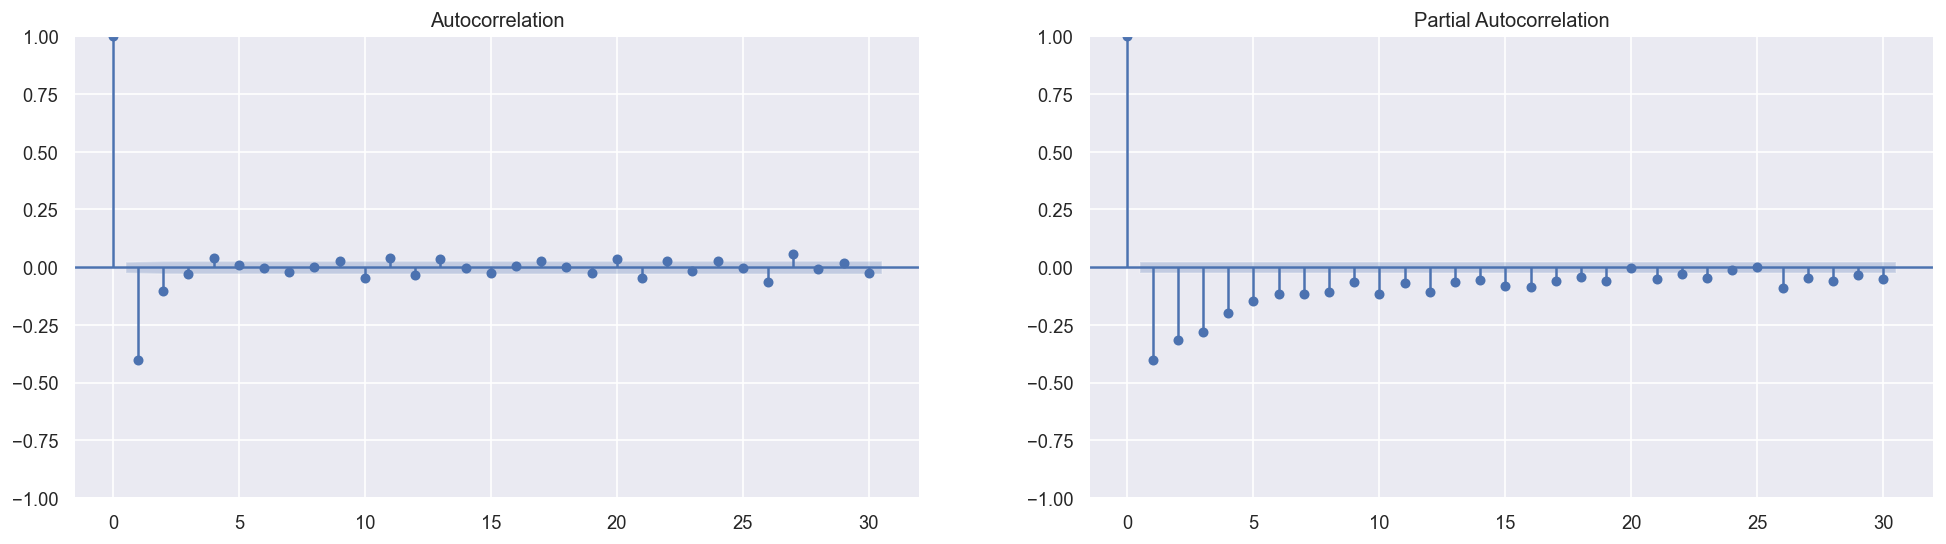

Train / Test based on:
order -> (1, 1, 2)
train_rate -> 0.7
                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                 4900
Model:                 ARIMA(1, 1, 2)   Log Likelihood                1021.279
Date:                Thu, 13 Mar 2025   AIC                          -2034.558
Time:                        15:51:35   BIC                          -2008.571
Sample:                             0   HQIC                         -2025.441
                               - 4900                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6411      0.211      3.033      0.002       0.227       1.055
ma.L1         -0.5016      0.210     -2.383      0.017      -0.914     

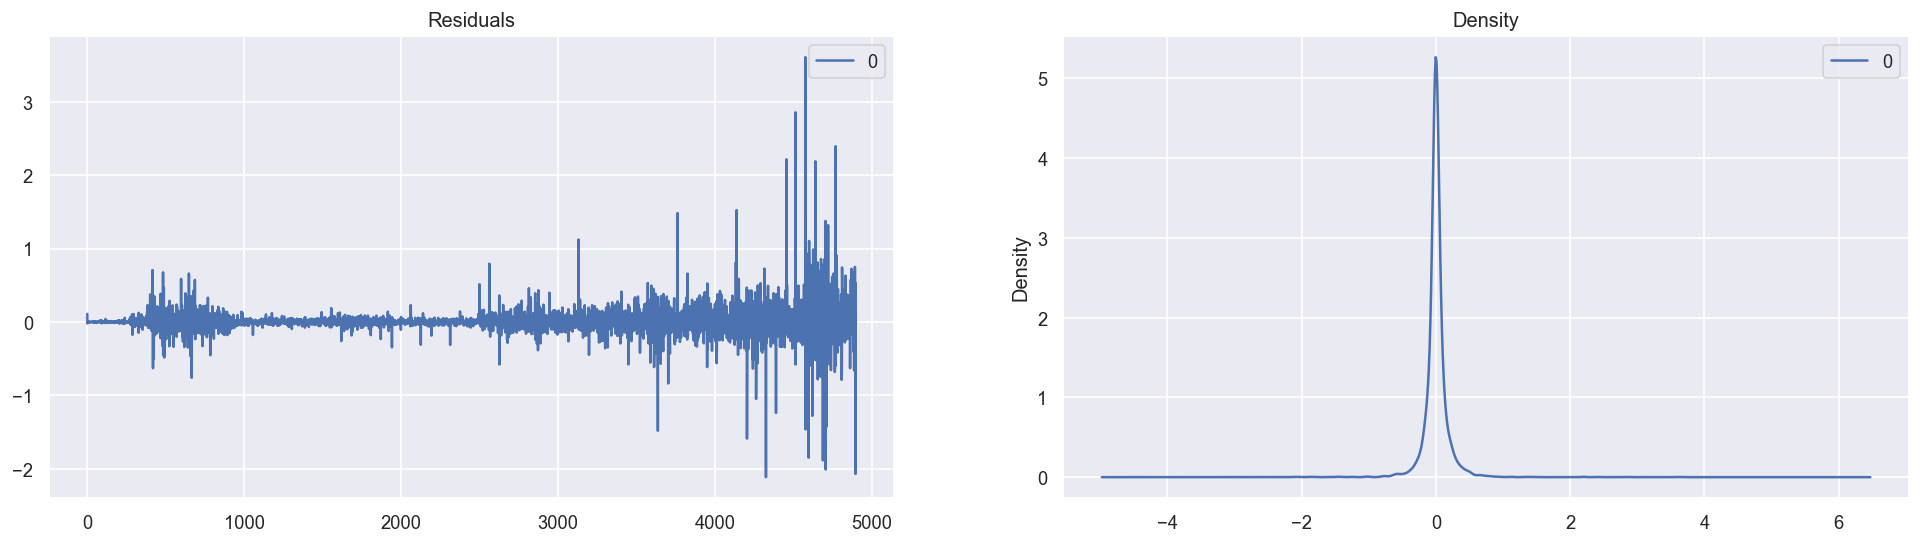

c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['alpha']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


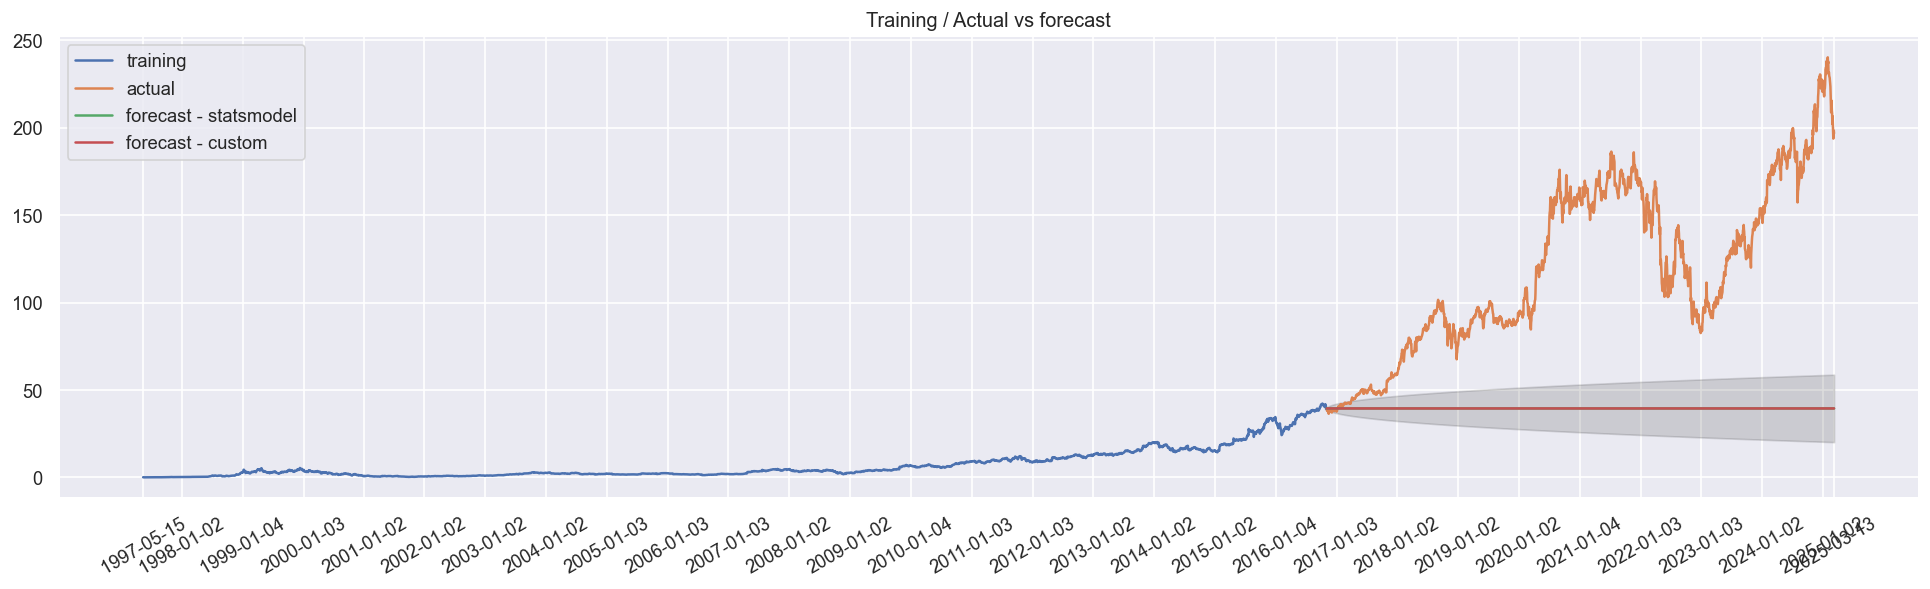

Train / Test based on:
order -> (1, 1, 1)
train_rate -> 0.7
                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                 4900
Model:                 ARIMA(1, 1, 1)   Log Likelihood                1020.264
Date:                Thu, 13 Mar 2025   AIC                          -2034.528
Time:                        15:51:46   BIC                          -2015.037
Sample:                             0   HQIC                         -2027.690
                               - 4900                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0001      0.055     -0.003      0.998      -0.108       0.108
ma.L1          0.1429      0.055      2.614      0.009       0.036     

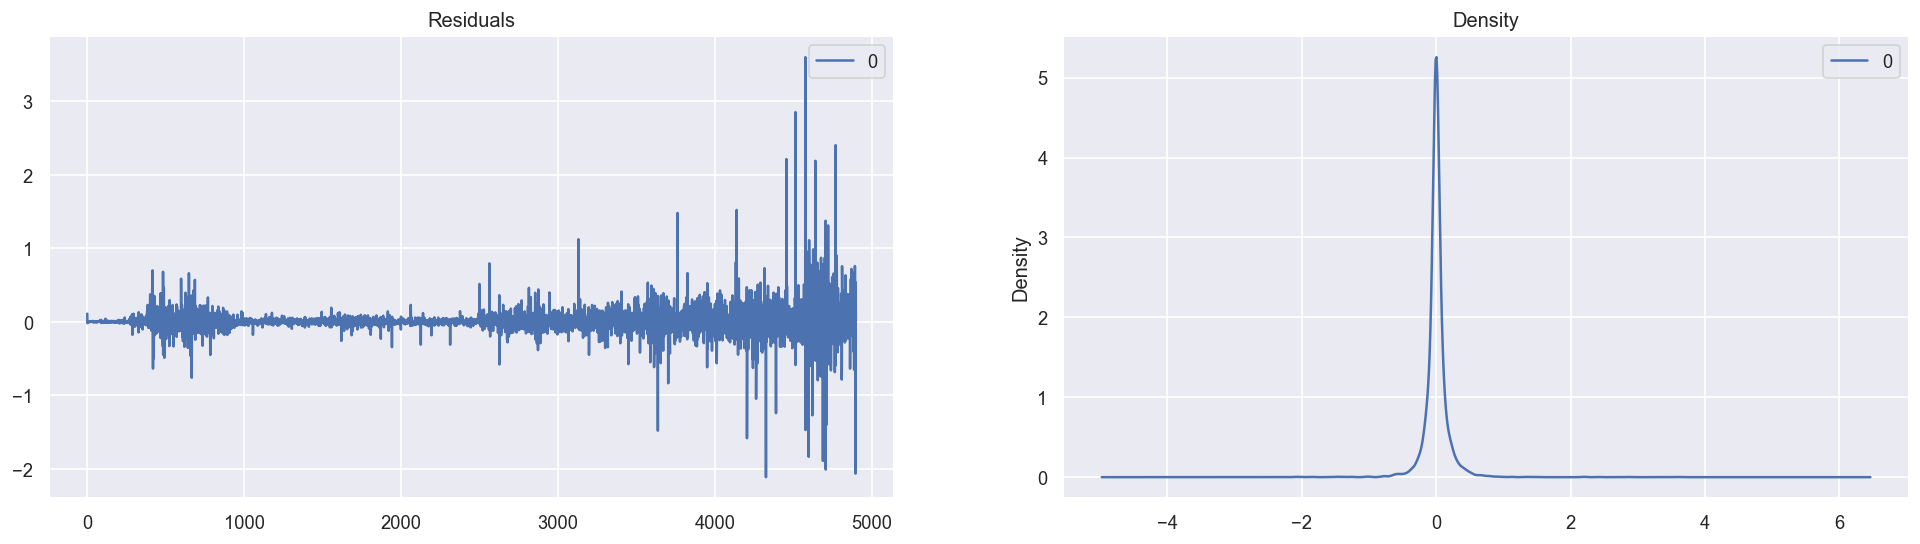

c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['alpha']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


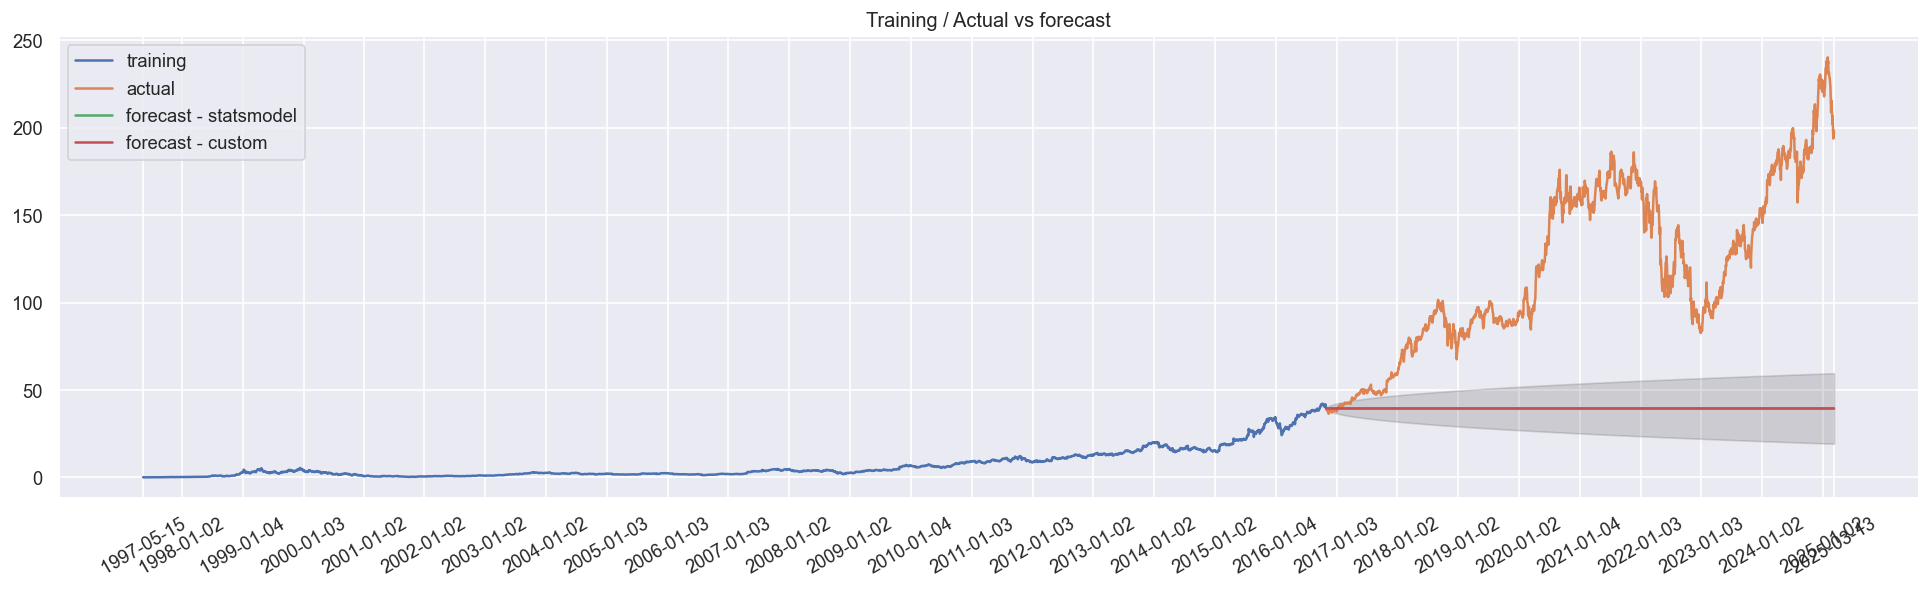

Train / Test based on:
order -> (3, 2, 3)
train_rate -> 0.7


c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                 4900
Model:                 ARIMA(3, 2, 3)   Log Likelihood                1032.089
Date:                Thu, 13 Mar 2025   AIC                          -2050.178
Time:                        15:52:08   BIC                          -2004.702
Sample:                             0   HQIC                         -2034.223
                               - 4900                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.3369      0.009   -151.502      0.000      -1.354      -1.320
ar.L2         -0.7771      0.008    -92.211      0.000      -0.794      -0.761
ar.L3          0.1201      0.006     19.129      0.0

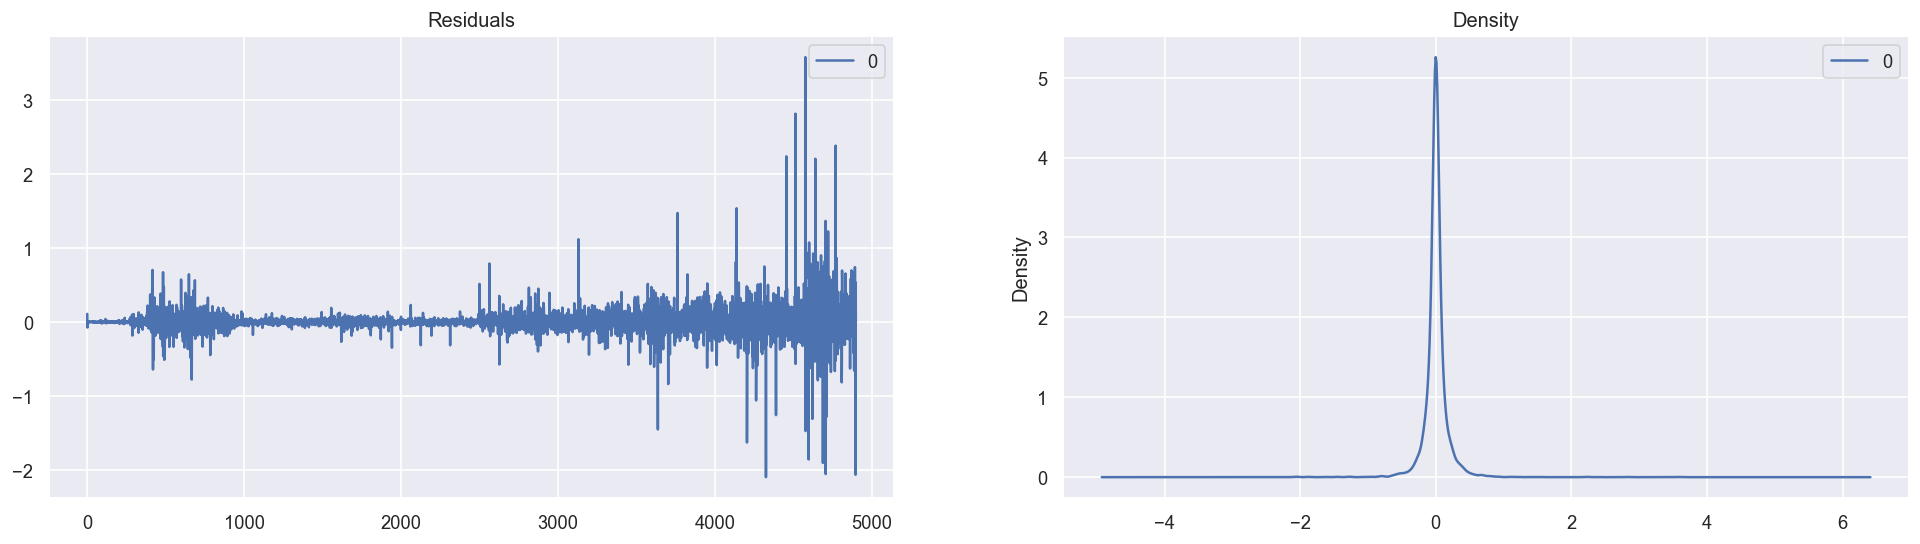

c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['alpha']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


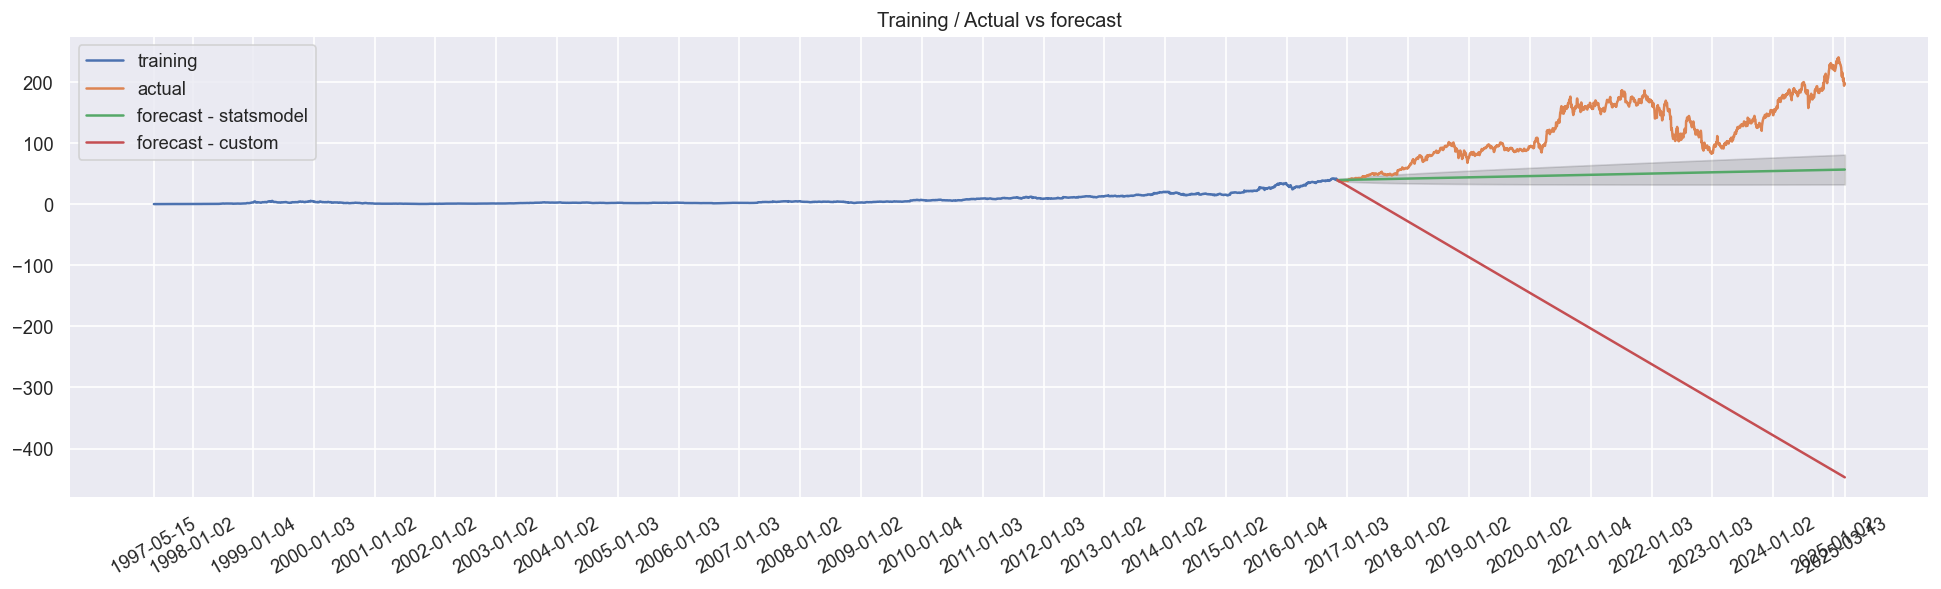

Train / Test based on:
order -> (3, 2, 1)
train_rate -> 0.7
                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                 4900
Model:                 ARIMA(3, 2, 1)   Log Likelihood                1025.530
Date:                Thu, 13 Mar 2025   AIC                          -2041.060
Time:                        15:52:27   BIC                          -2008.577
Sample:                             0   HQIC                         -2029.664
                               - 4900                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1394      0.005     28.643      0.000       0.130       0.149
ar.L2         -0.0250      0.008     -3.070      0.002      -0.041     

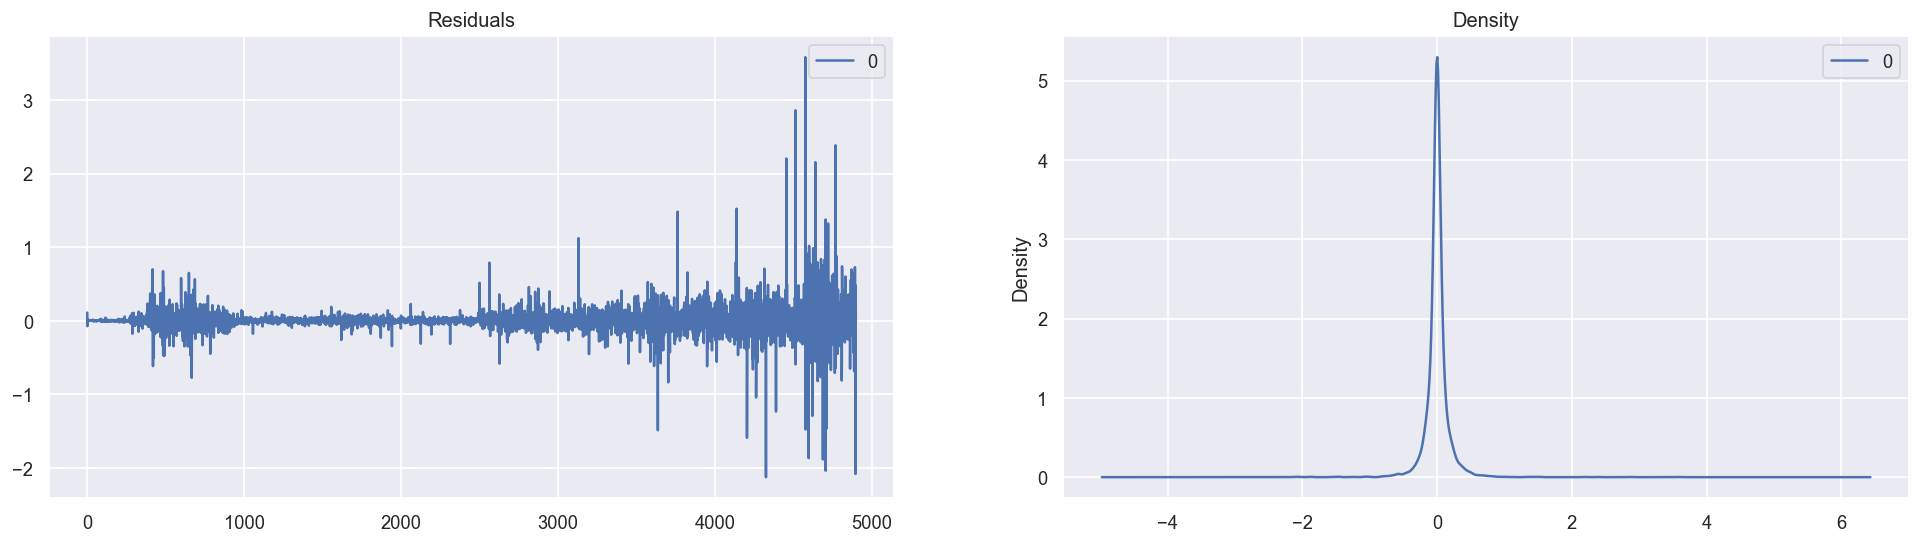

c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['alpha']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


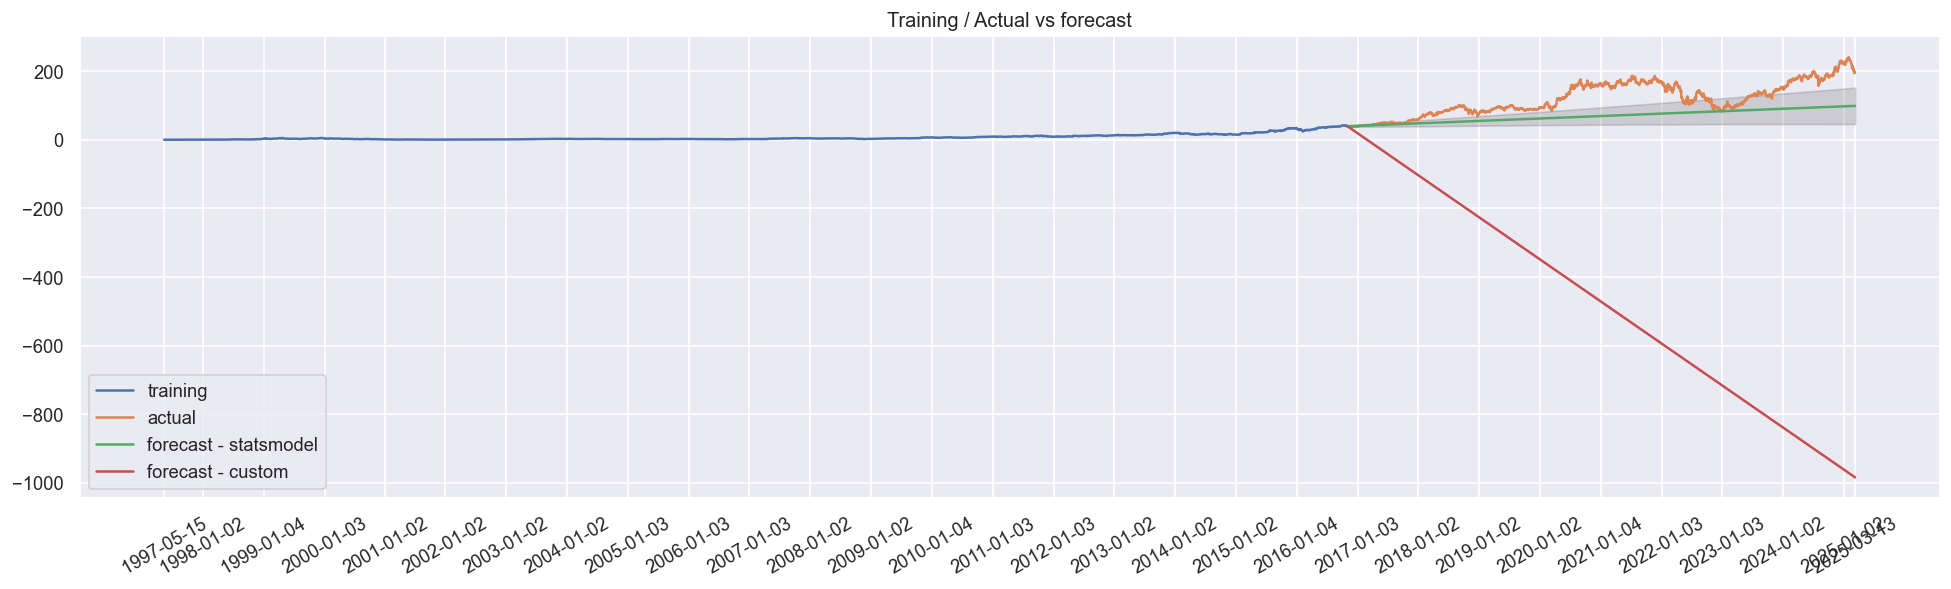

Train / Test based on:
order -> (4, 1, 3)
train_rate -> 0.7


c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                 4900
Model:                 ARIMA(4, 1, 3)   Log Likelihood                1059.551
Date:                Thu, 13 Mar 2025   AIC                          -2103.102
Time:                        15:52:57   BIC                          -2051.128
Sample:                             0   HQIC                         -2084.867
                               - 4900                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6431      0.056     11.553      0.000       0.534       0.752
ar.L2          0.3711      0.086      4.318      0.000       0.203       0.540
ar.L3         -0.9996      0.061    -16.469      0.0

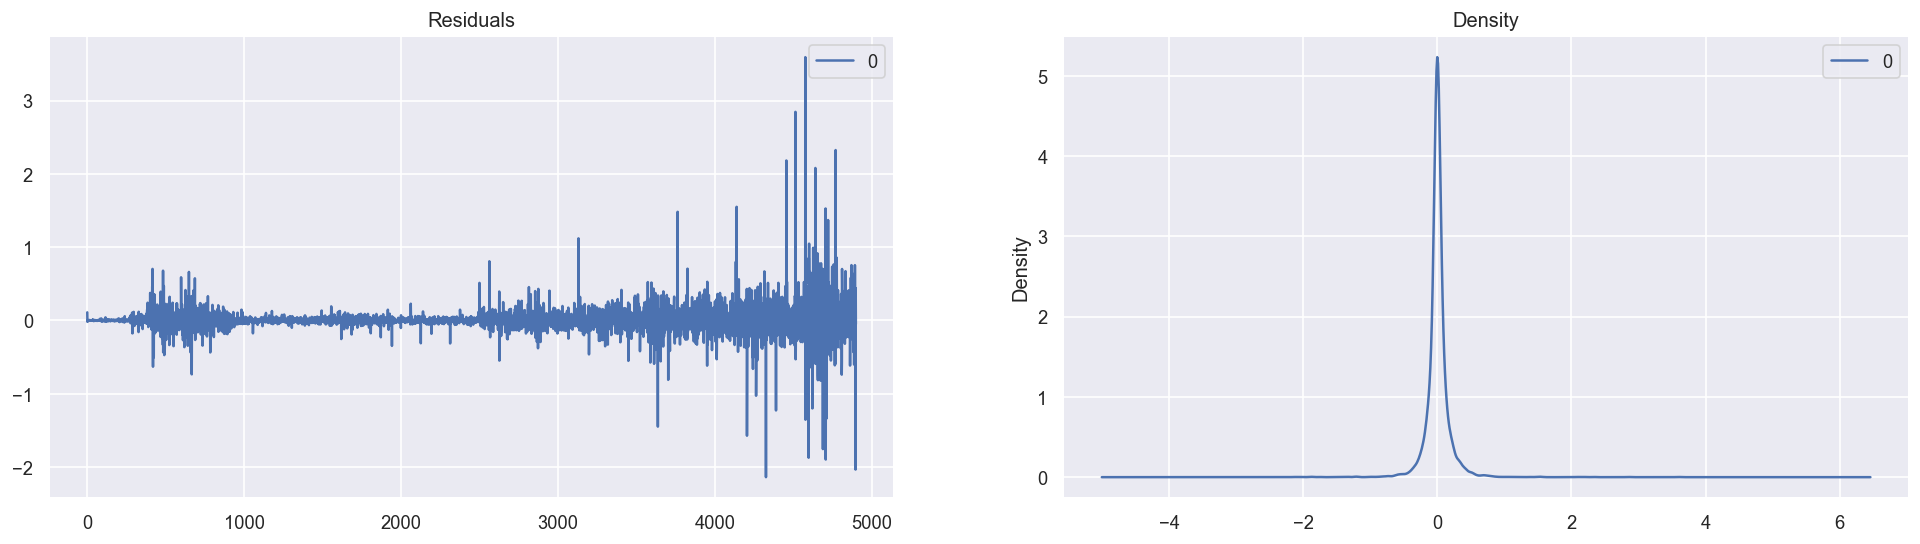

c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['alpha']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


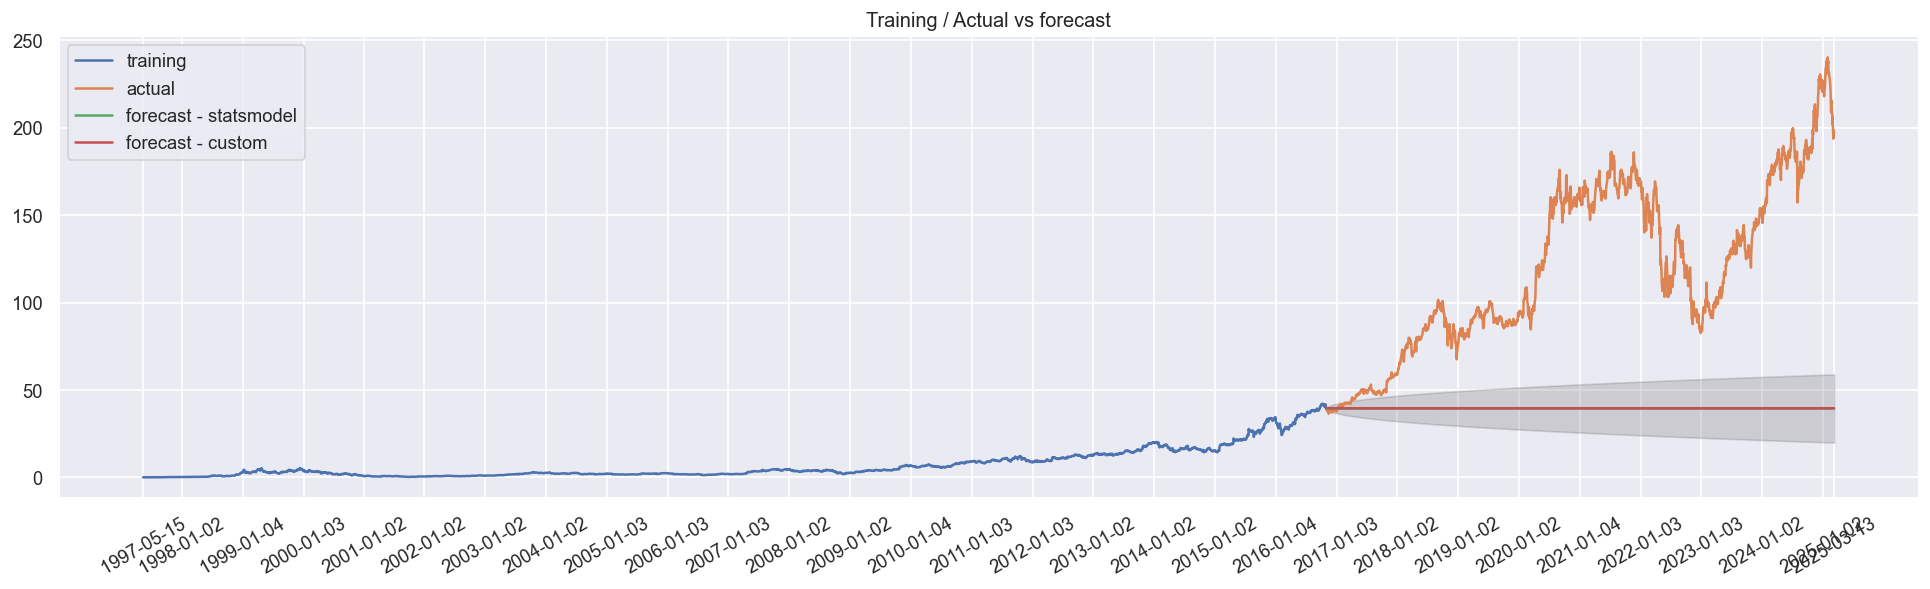

Train / Test based on:
order -> (3, 2, 1)
train_rate -> 0.8
                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                 5600
Model:                 ARIMA(3, 2, 1)   Log Likelihood               -3409.538
Date:                Thu, 13 Mar 2025   AIC                           6829.076
Time:                        15:53:13   BIC                           6862.227
Sample:                             0   HQIC                          6840.629
                               - 5600                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1708      0.004     46.595      0.000       0.164       0.178
ar.L2         -0.0547      0.004    -13.339      0.000      -0.063     

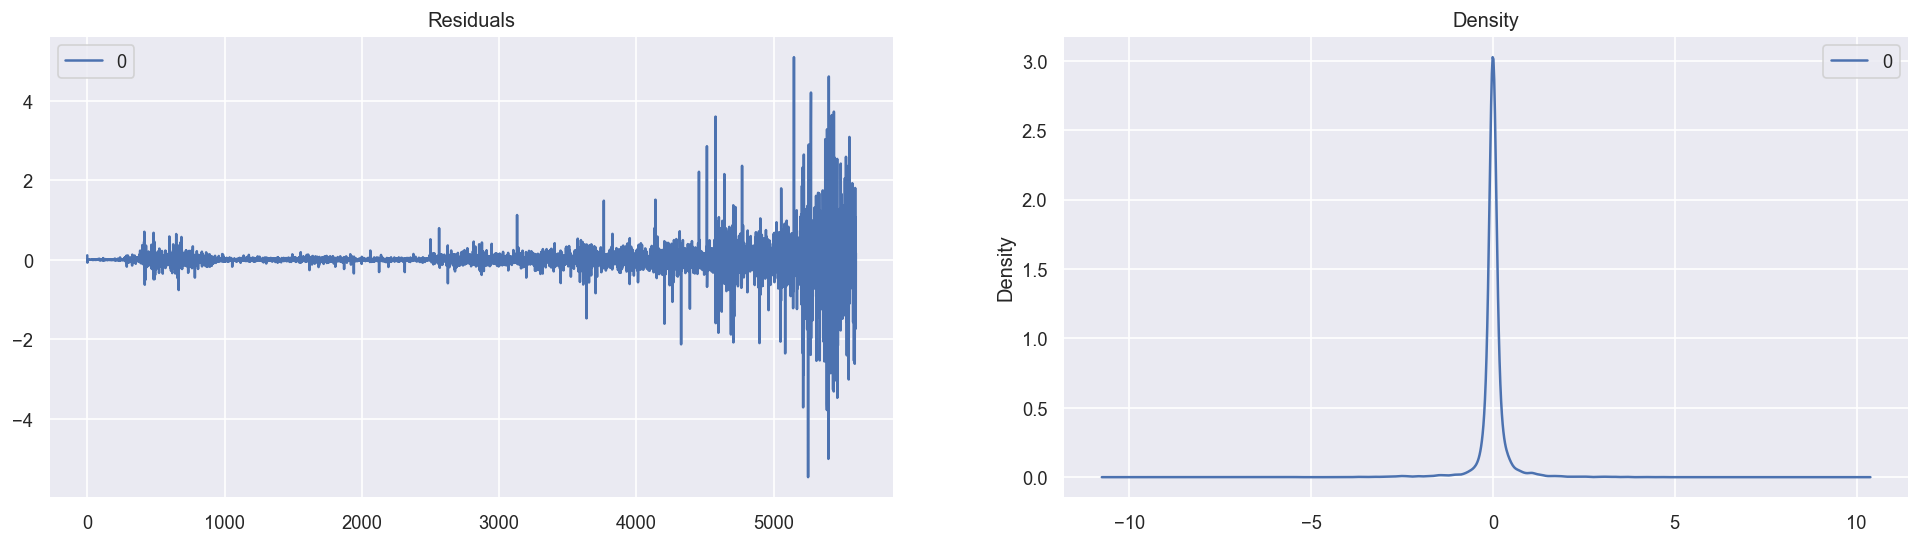

c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['alpha']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


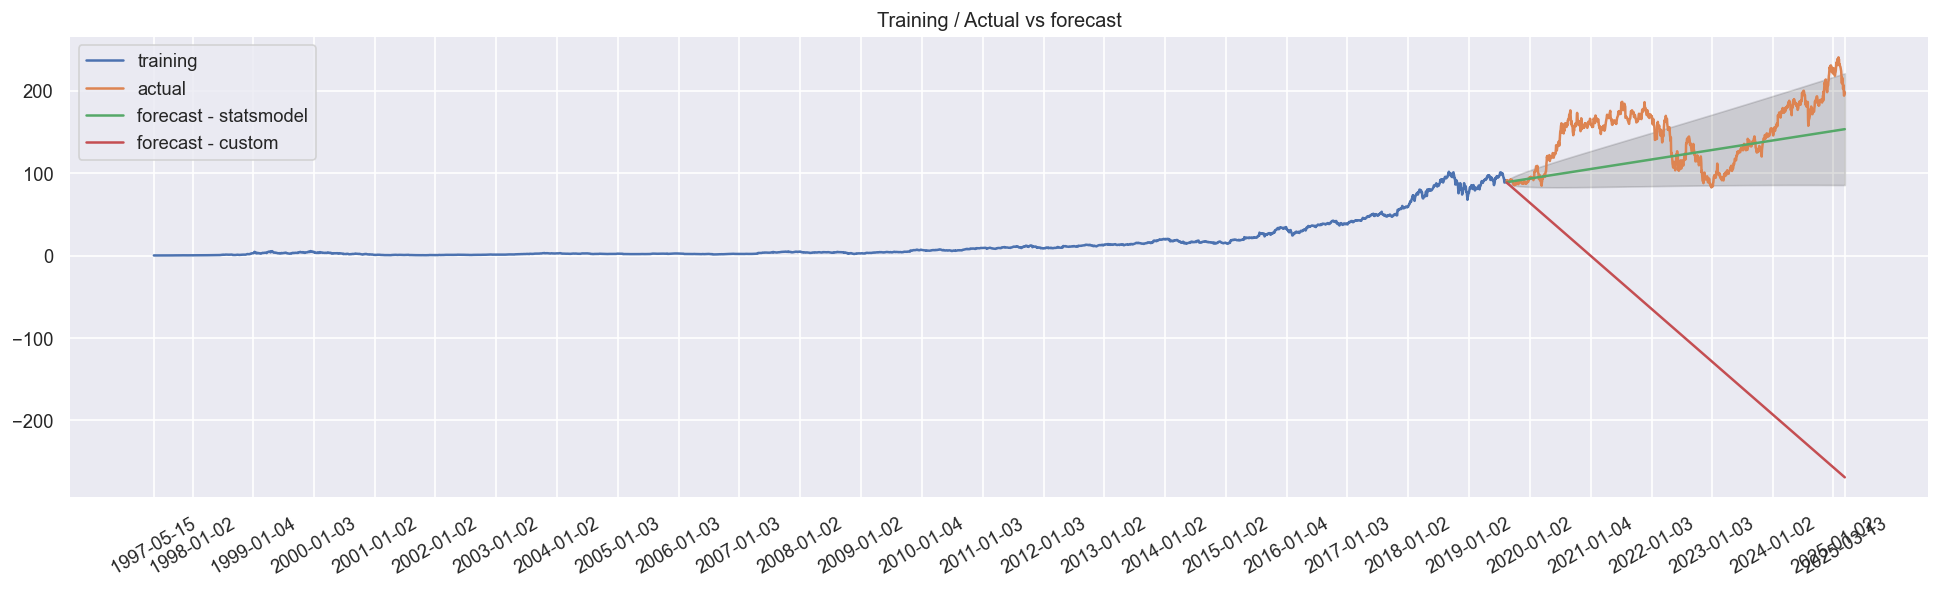

Train / Test based on:
order -> (4, 1, 3)
train_rate -> 0.8


c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                 5600
Model:                 ARIMA(4, 1, 3)   Log Likelihood               -3387.179
Date:                Thu, 13 Mar 2025   AIC                           6790.359
Time:                        15:53:41   BIC                           6843.401
Sample:                             0   HQIC                          6808.843
                               - 5600                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0149      0.007     -2.112      0.035      -0.029      -0.001
ar.L2         -0.1688      0.006    -27.852      0.000      -0.181      -0.157
ar.L3         -0.9480      0.007   -142.206      0.0

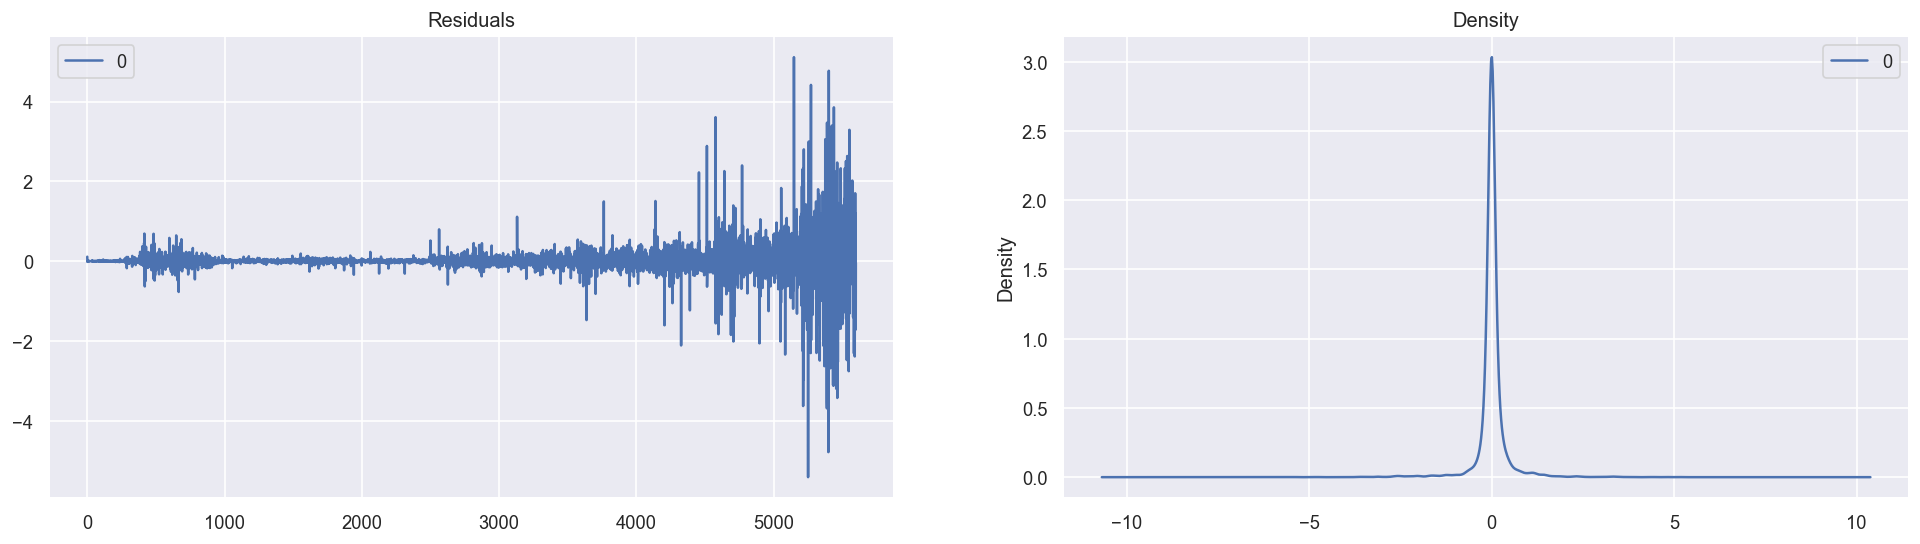

c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['alpha']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


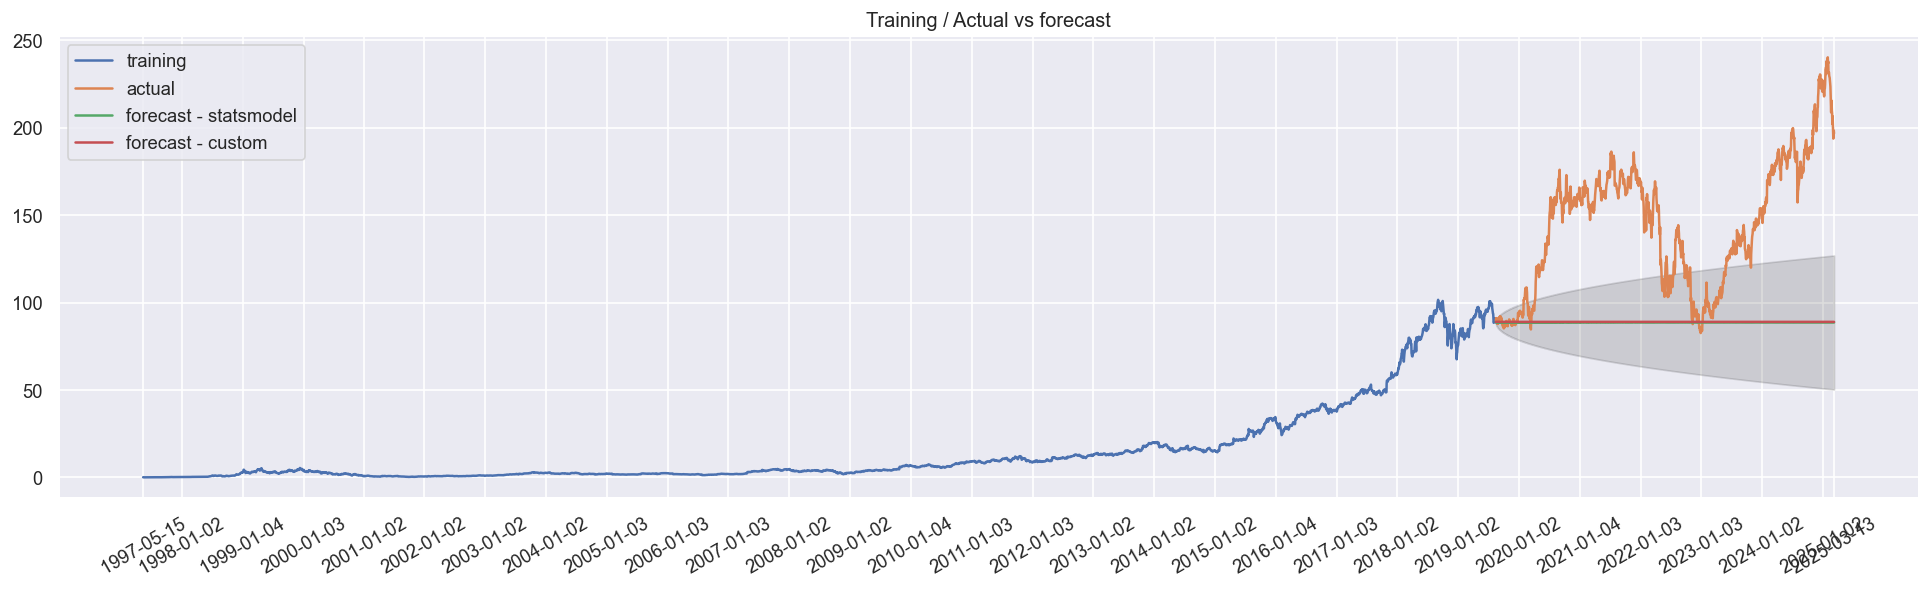

Train / Test based on:
order -> (3, 2, 1)
train_rate -> 0.9
                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                 6300
Model:                 ARIMA(3, 2, 1)   Log Likelihood               -8542.729
Date:                Thu, 13 Mar 2025   AIC                          17095.457
Time:                        15:53:52   BIC                          17129.197
Sample:                             0   HQIC                         17107.145
                               - 6300                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1928      0.004     48.084      0.000       0.185       0.201
ar.L2         -0.0792      0.005    -14.697      0.000      -0.090     

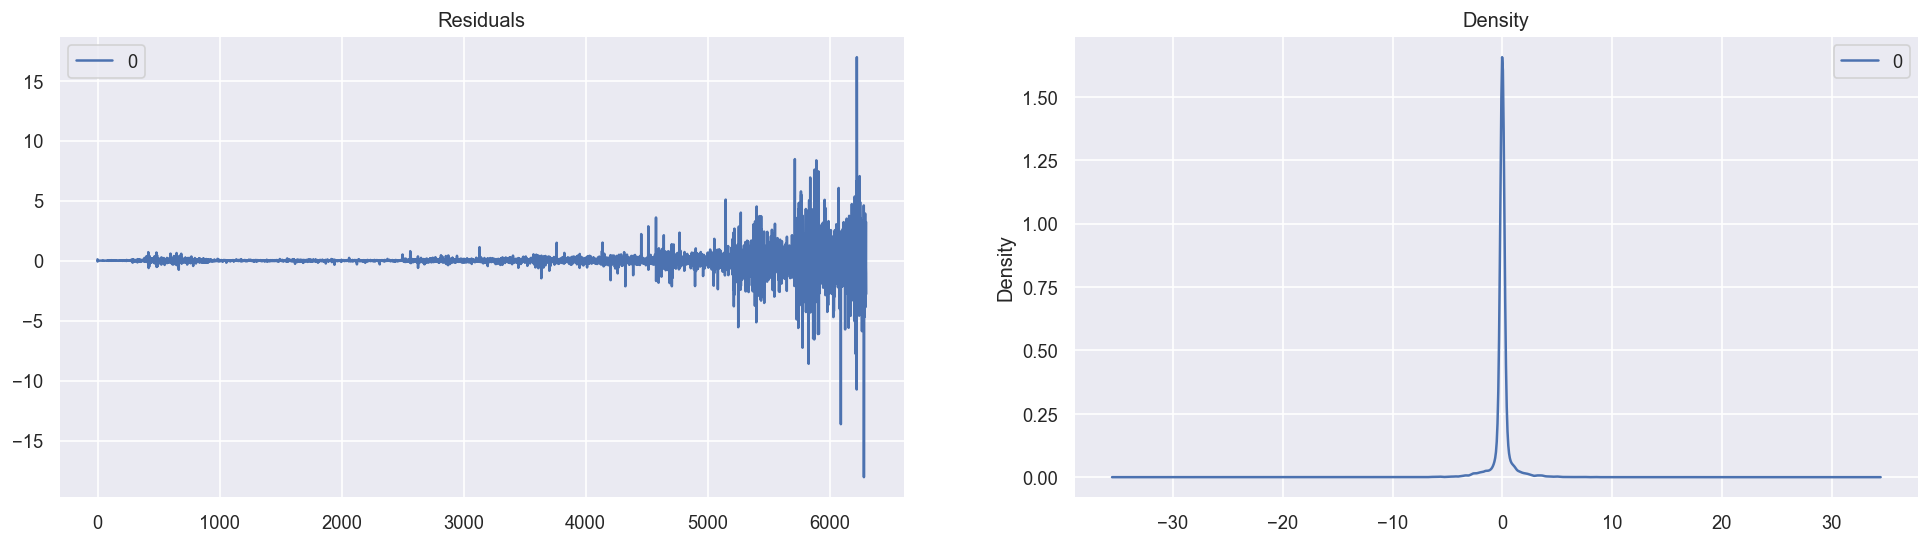

c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['alpha']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


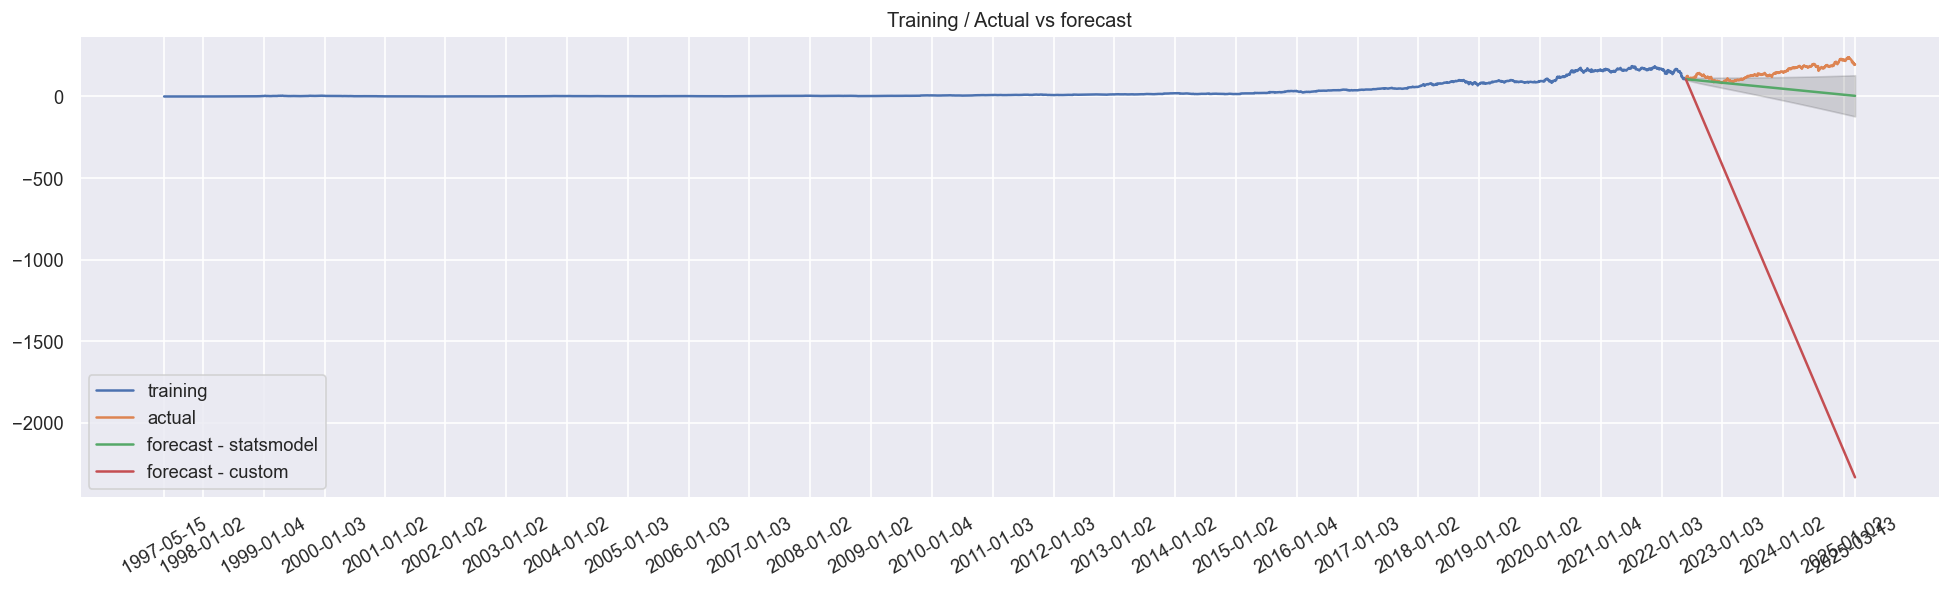

C:\Users\Roey\AppData\Local\Temp\ipykernel_18592\2499829597.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  date_filter['year'] = date_filter['date'].str.split('-').str[0]
C:\Users\Roey\AppData\Local\Temp\ipykernel_18592\2499829597.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  date_filter.loc[0] = dataset.iloc[0]
C:\Users\Roey\AppData\Local\Temp\ipykernel_18592\2499829597.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/use

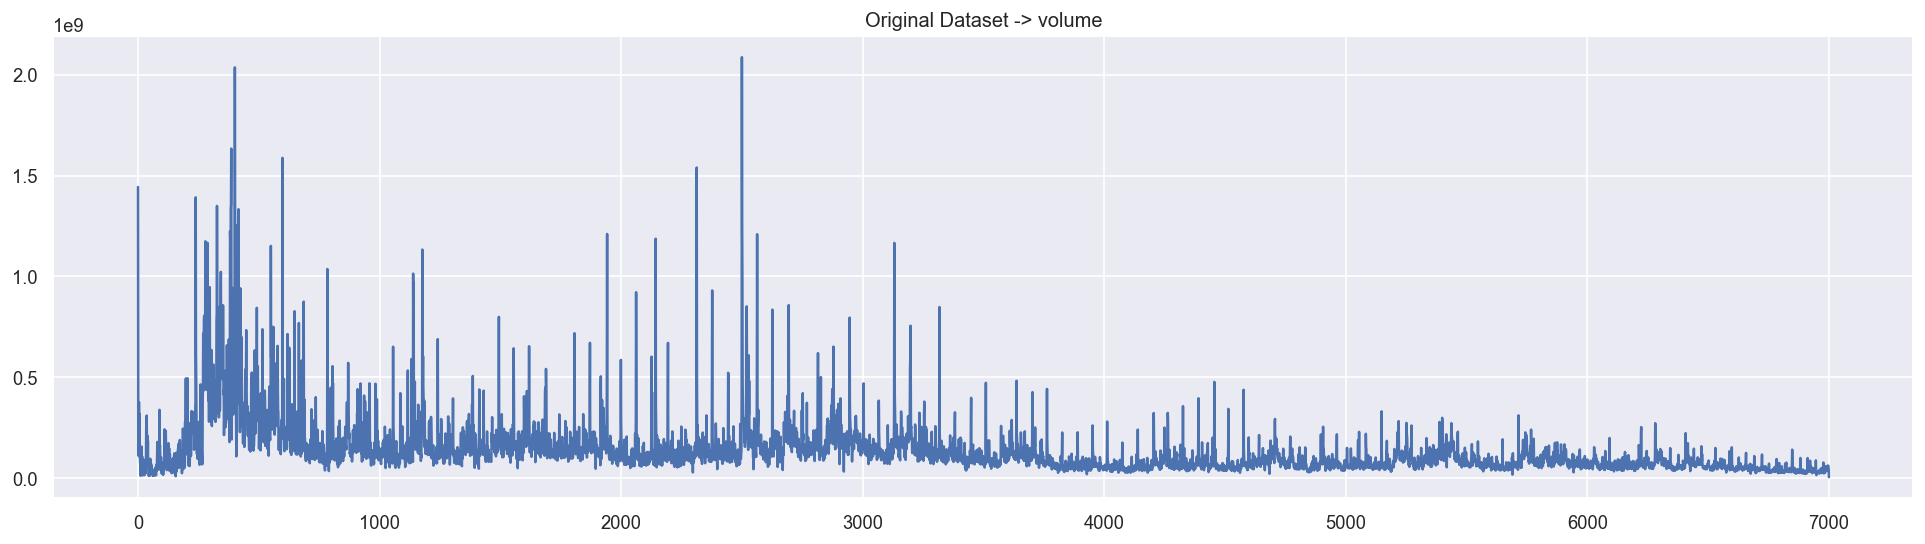

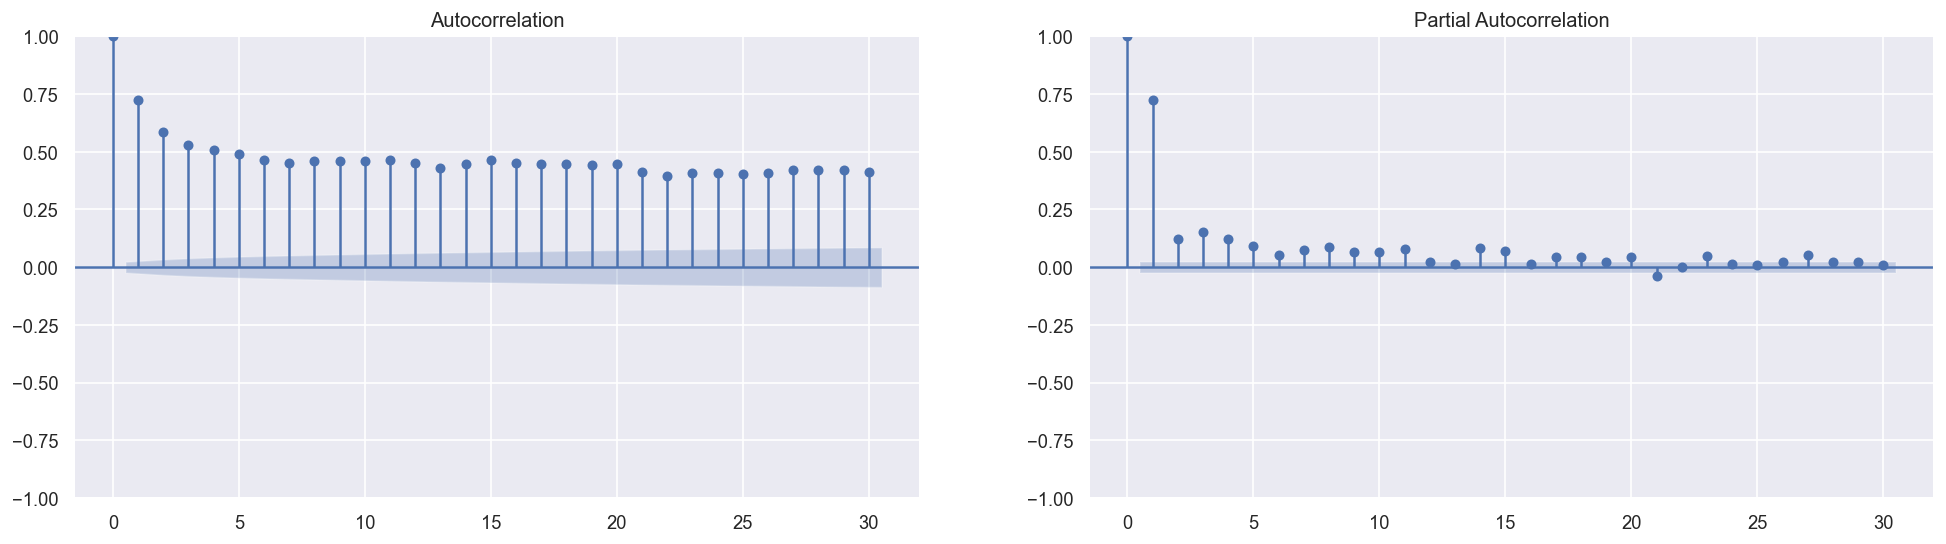

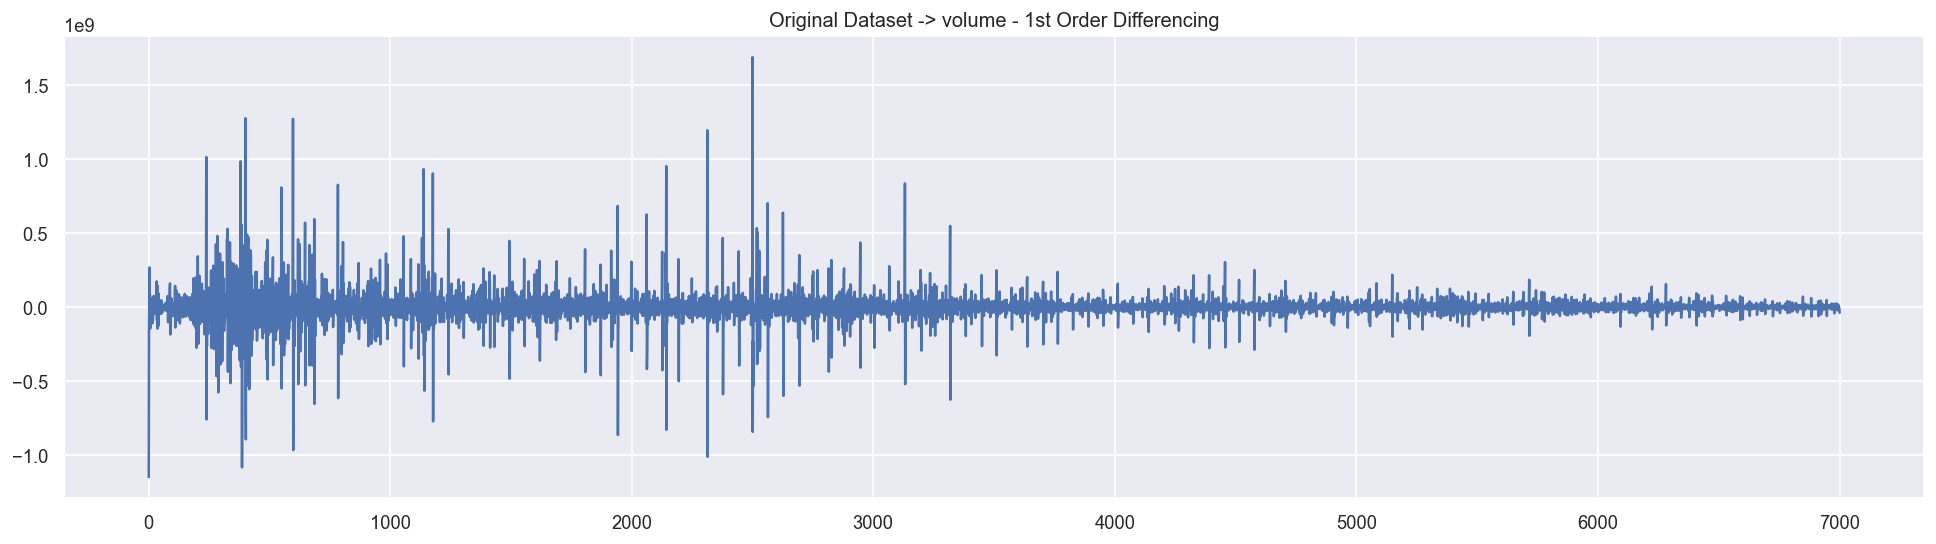

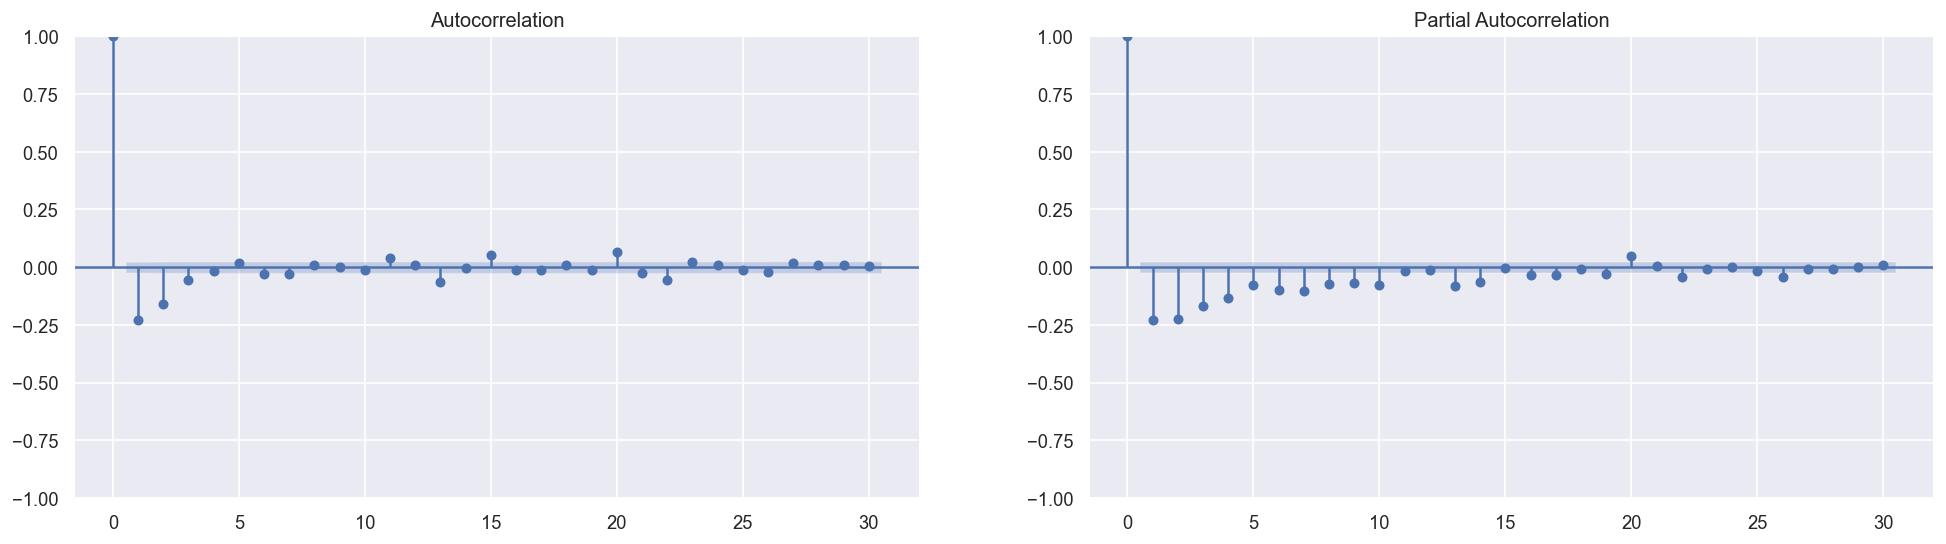

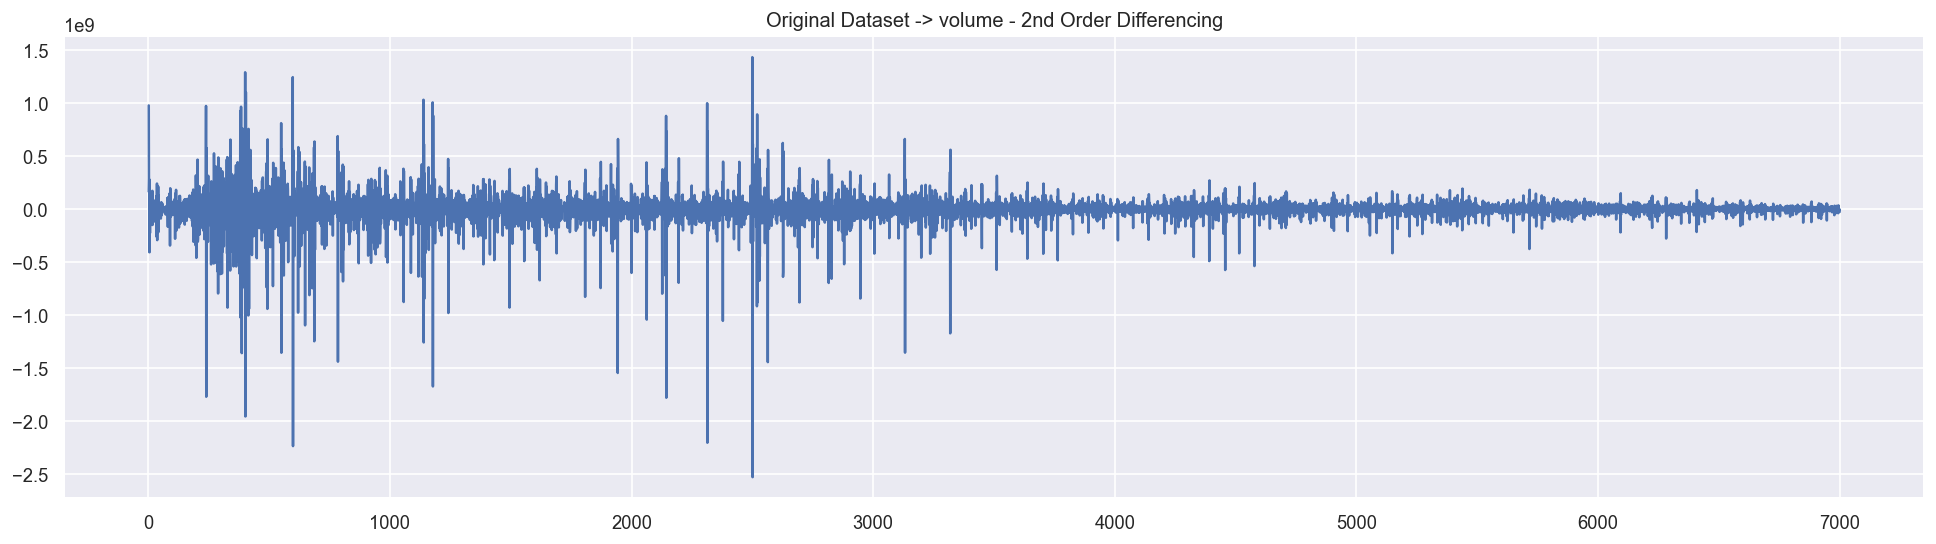

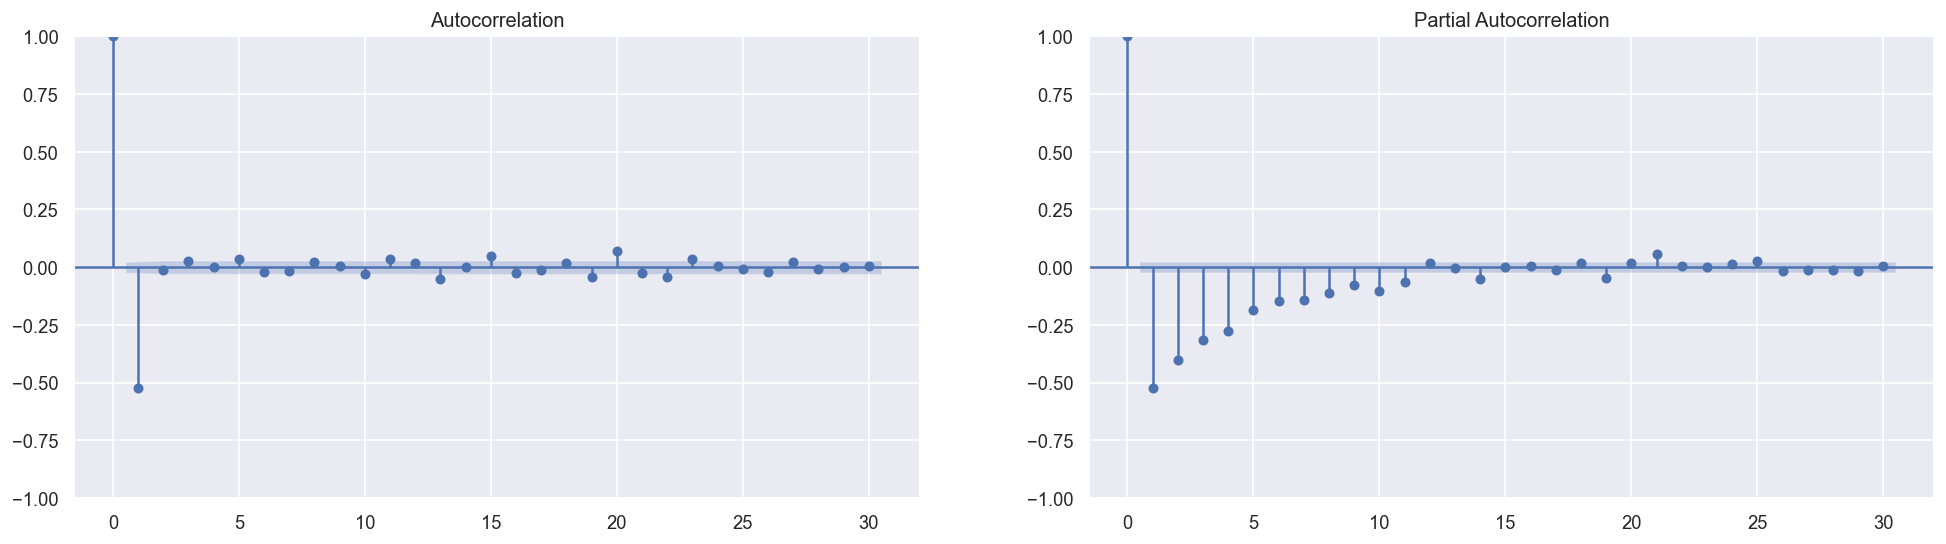

Train / Test based on:
order -> (1, 1, 2)
train_rate -> 0.7
                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                 4900
Model:                 ARIMA(1, 1, 2)   Log Likelihood              -97416.313
Date:                Thu, 13 Mar 2025   AIC                         194840.627
Time:                        15:54:10   BIC                         194866.614
Sample:                             0   HQIC                        194849.744
                               - 4900                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4634      0.016     29.383      0.000       0.432       0.494
ma.L1         -0.9243      0.017    -53.684      0.000      -0.958     

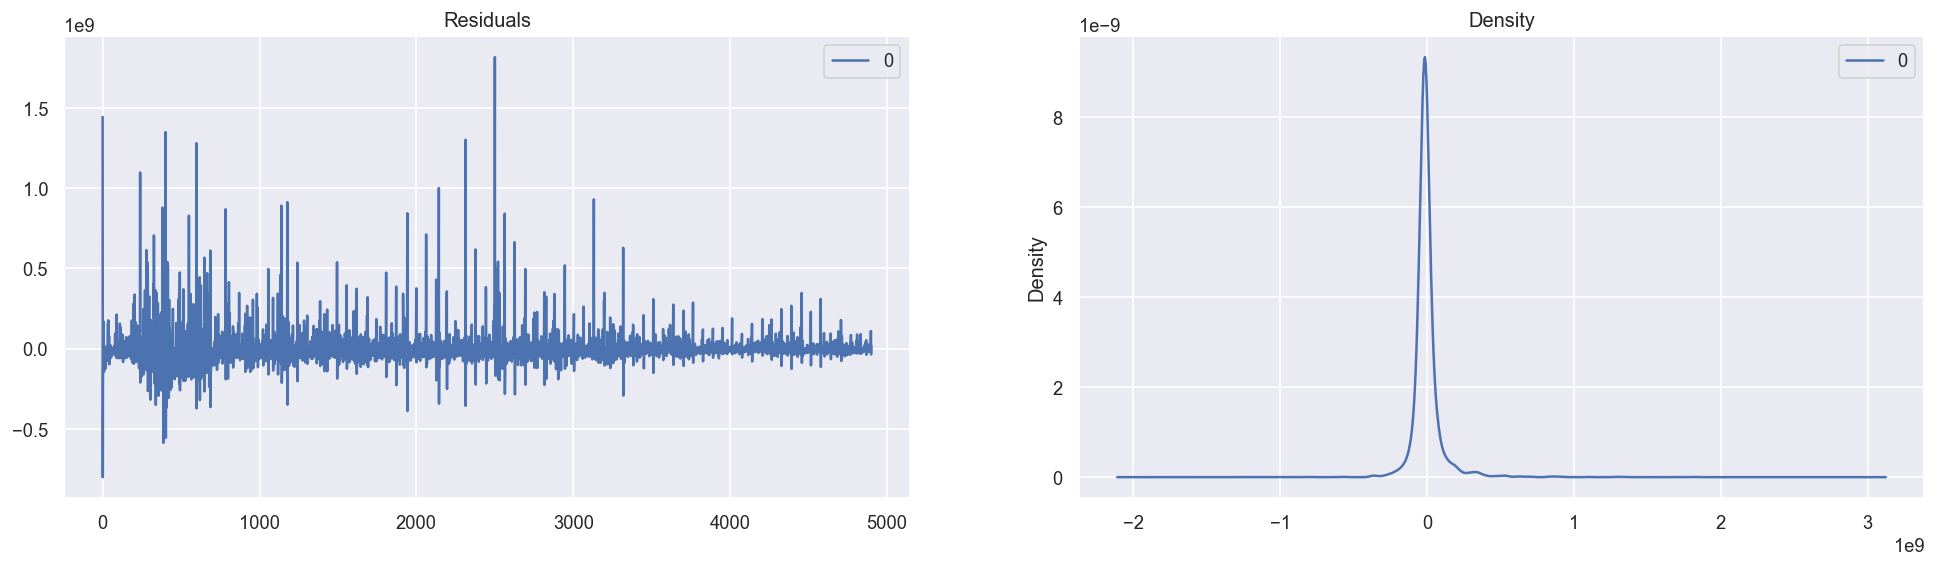

c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['alpha']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


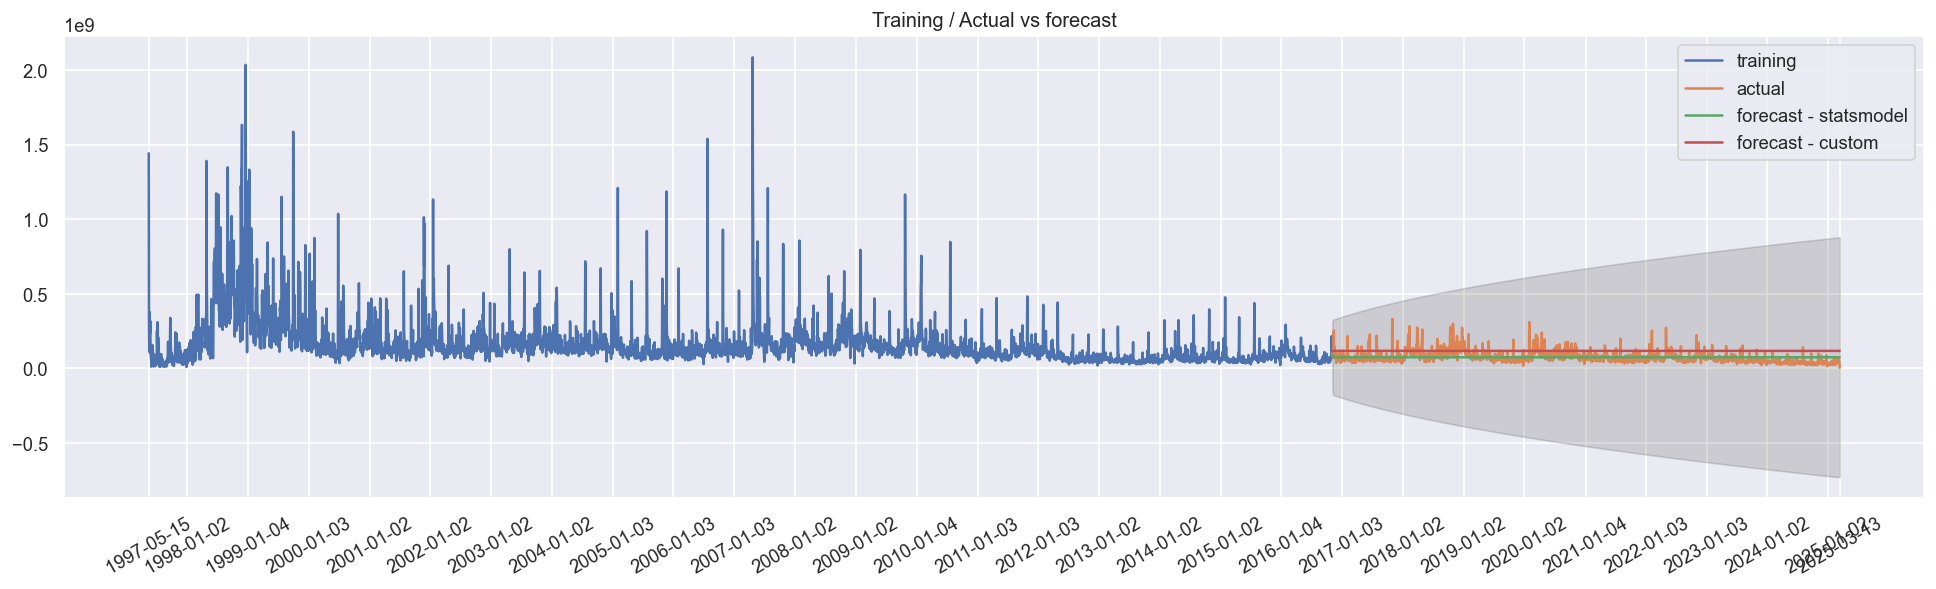

Train / Test based on:
order -> (1, 1, 1)
train_rate -> 0.7
                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                 4900
Model:                 ARIMA(1, 1, 1)   Log Likelihood              -97423.051
Date:                Thu, 13 Mar 2025   AIC                         194852.101
Time:                        15:54:21   BIC                         194871.591
Sample:                             0   HQIC                        194858.939
                               - 4900                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4925      0.007     70.589      0.000       0.479       0.506
ma.L1         -0.9608      0.003   -319.344      0.000      -0.967     

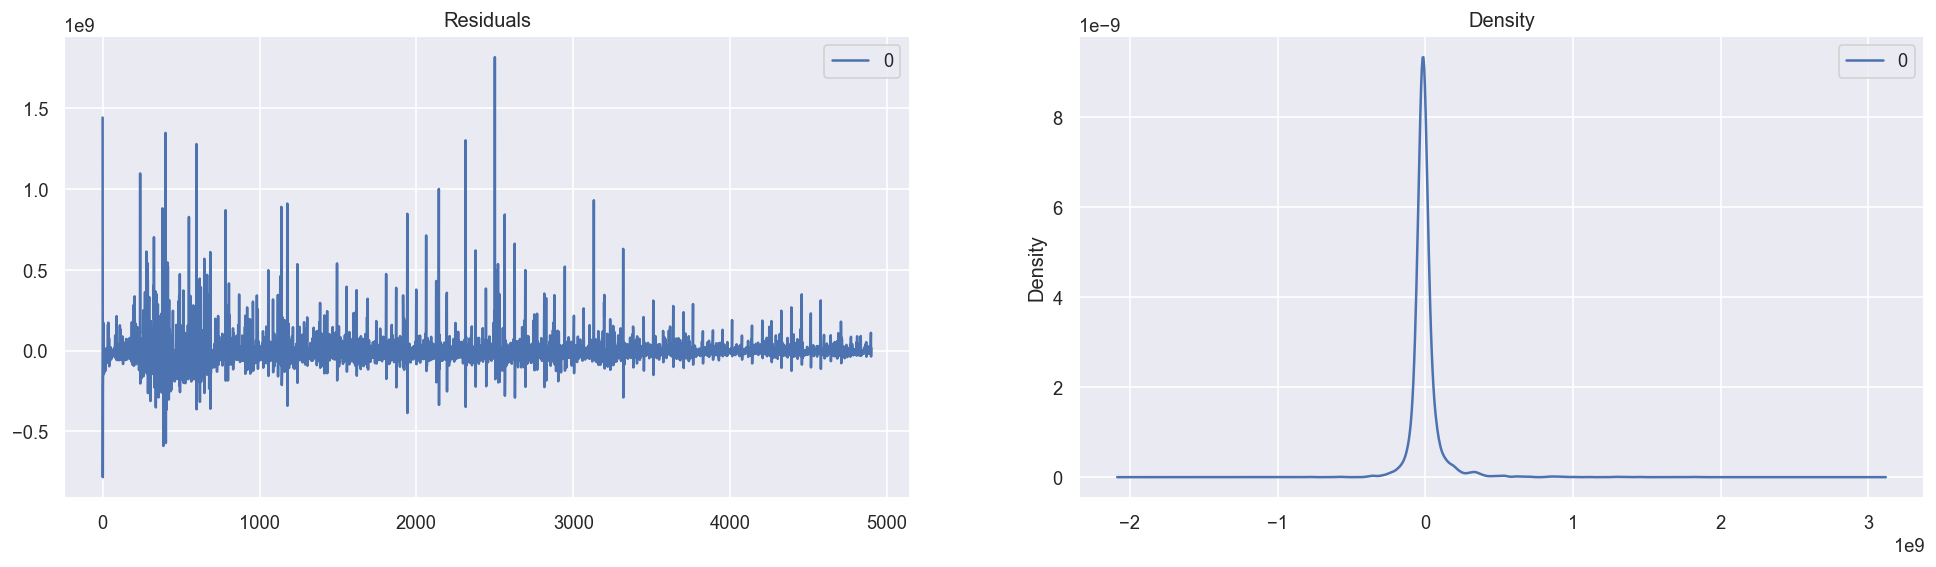

c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['alpha']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


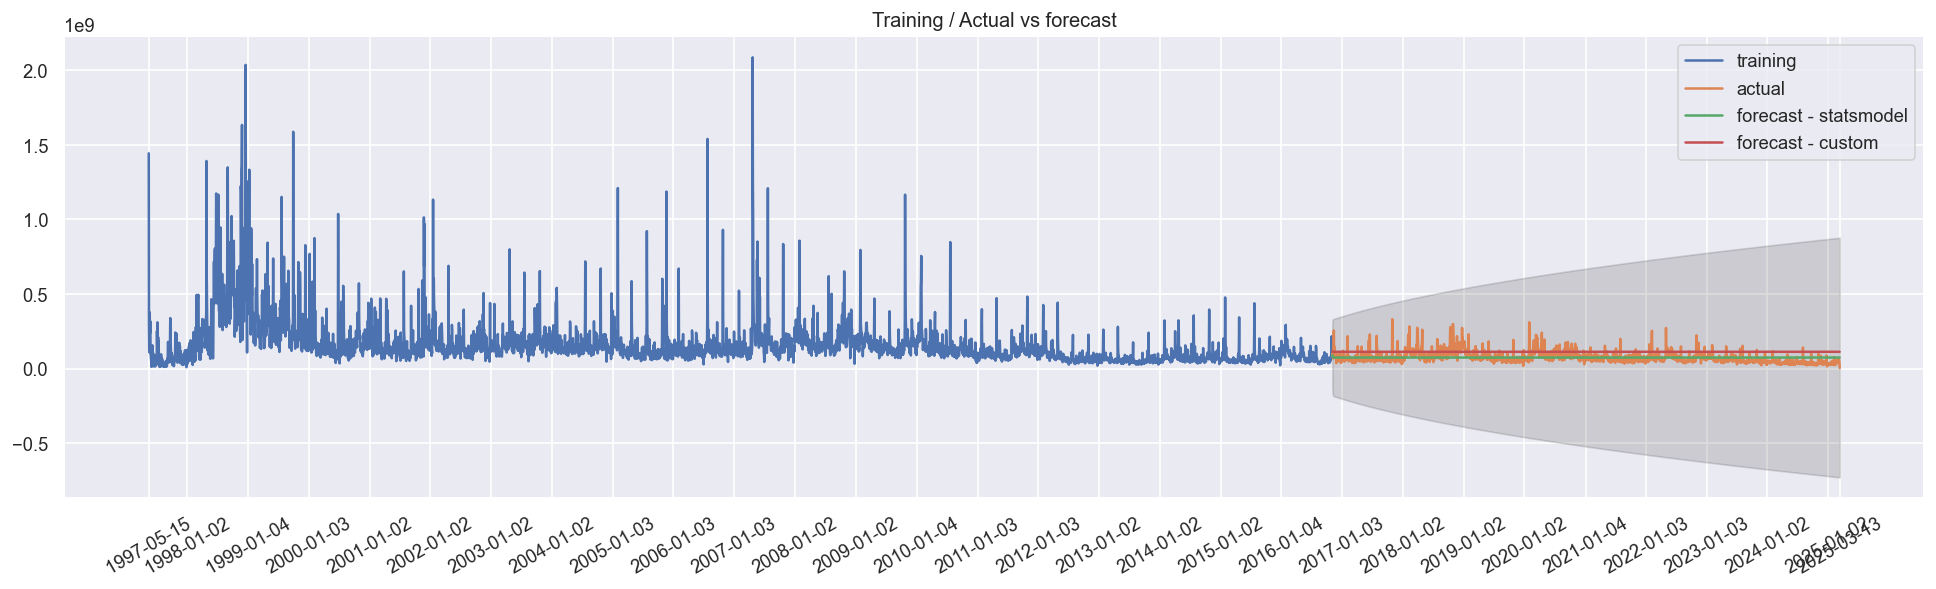

Train / Test based on:
order -> (3, 2, 3)
train_rate -> 0.7


c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                 4900
Model:                 ARIMA(3, 2, 3)   Log Likelihood              -97462.373
Date:                Thu, 13 Mar 2025   AIC                         194938.746
Time:                        15:54:54   BIC                         194984.222
Sample:                             0   HQIC                        194954.701
                               - 4900                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4873      0.012    -40.934      0.000      -0.511      -0.464
ar.L2          0.4854      0.012     41.931      0.000       0.463       0.508
ar.L3         -0.0271      0.010     -2.800      0.0

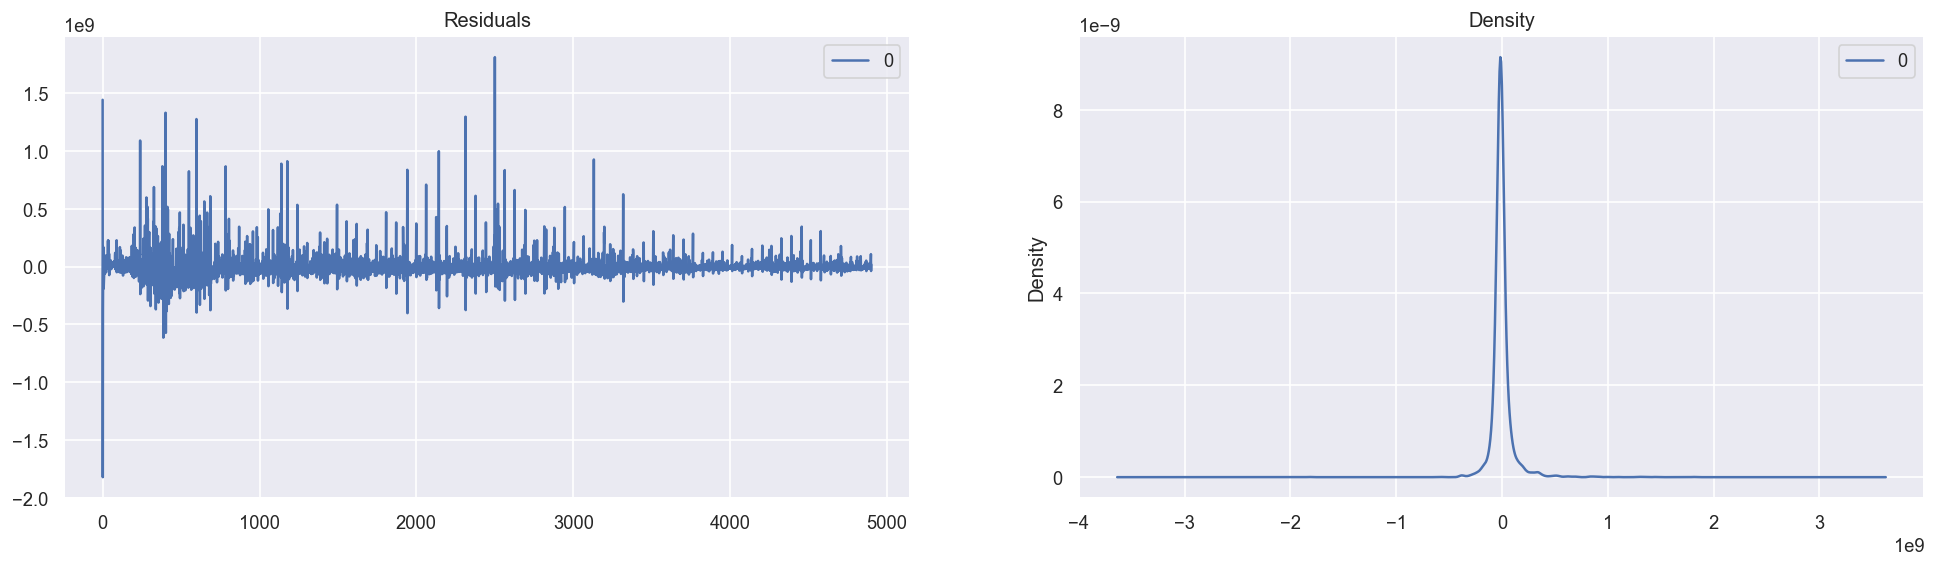

c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['alpha']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


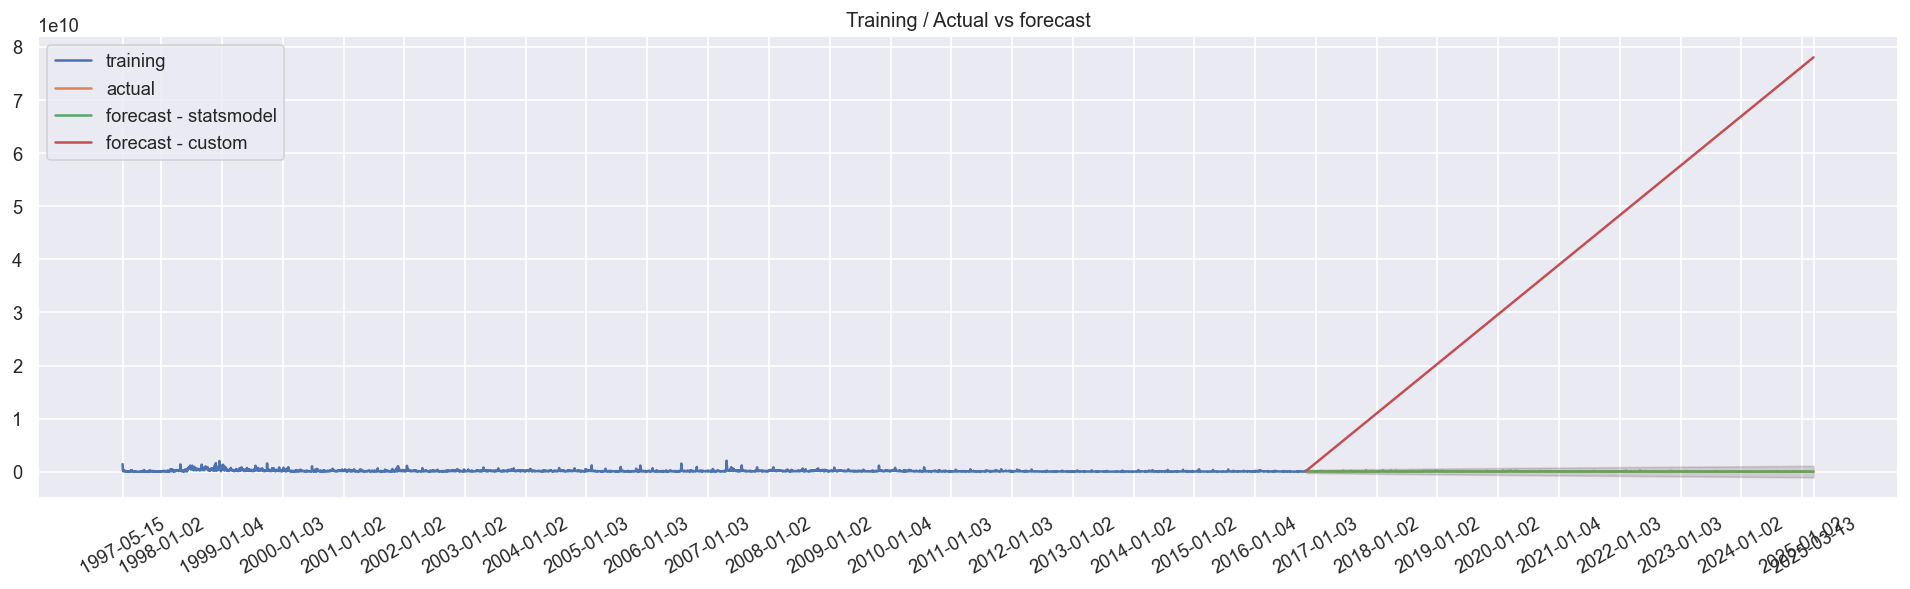

Train / Test based on:
order -> (3, 2, 1)
train_rate -> 0.7
                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                 4900
Model:                 ARIMA(3, 2, 1)   Log Likelihood              -97820.613
Date:                Thu, 13 Mar 2025   AIC                         195651.225
Time:                        15:55:15   BIC                         195683.708
Sample:                             0   HQIC                        195662.622
                               - 4900                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3250      0.008    -41.070      0.000      -0.341      -0.309
ar.L2         -0.2859      0.010    -29.203      0.000      -0.305     

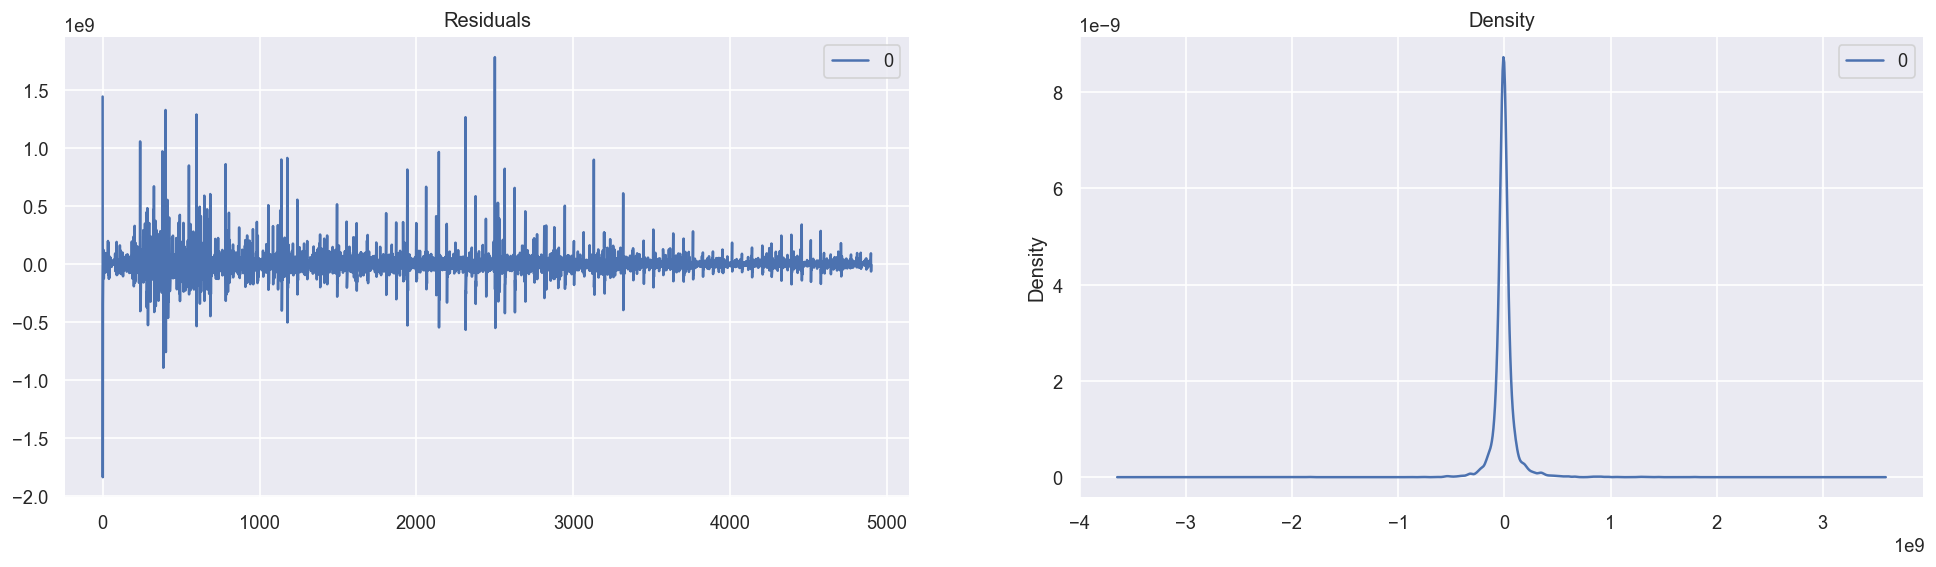

c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['alpha']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


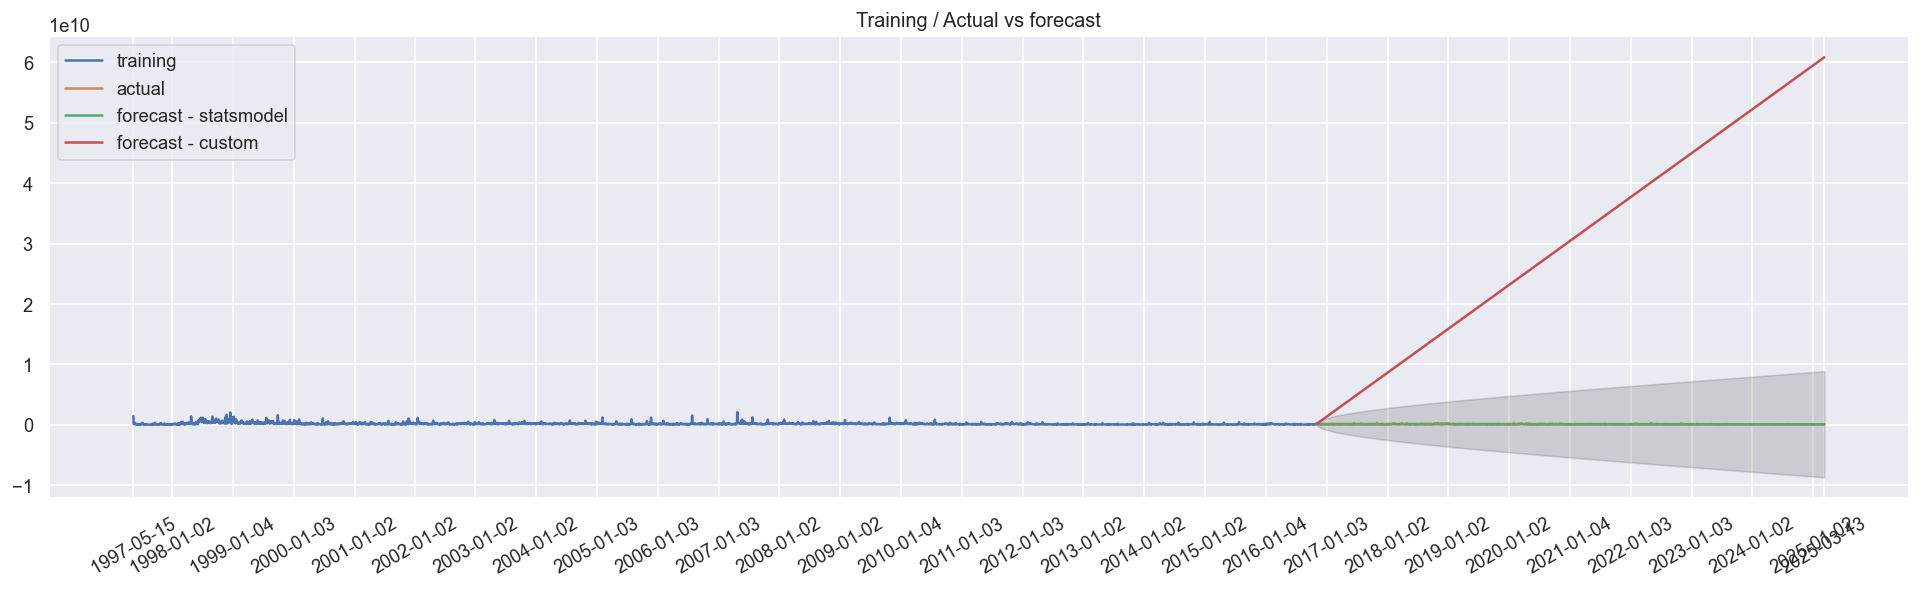

Train / Test based on:
order -> (4, 1, 3)
train_rate -> 0.7


c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                 4900
Model:                 ARIMA(4, 1, 3)   Log Likelihood              -97407.946
Date:                Thu, 13 Mar 2025   AIC                         194831.893
Time:                        15:55:41   BIC                         194883.867
Sample:                             0   HQIC                        194850.128
                               - 4900                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1470      0.192     -0.764      0.445      -0.524       0.230
ar.L2          0.6365      0.097      6.535      0.000       0.446       0.827
ar.L3         -0.1579      0.094     -1.675      0.0

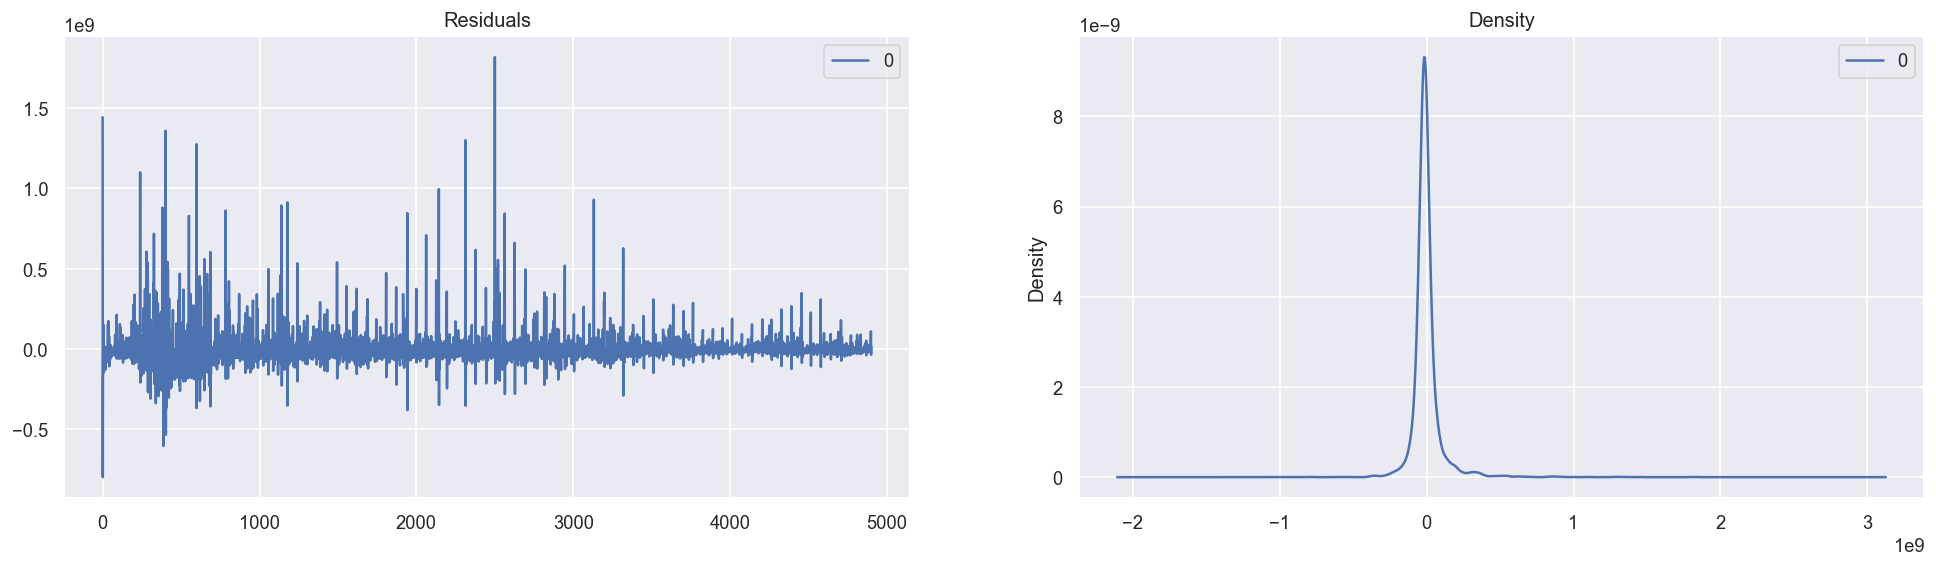

c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['alpha']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


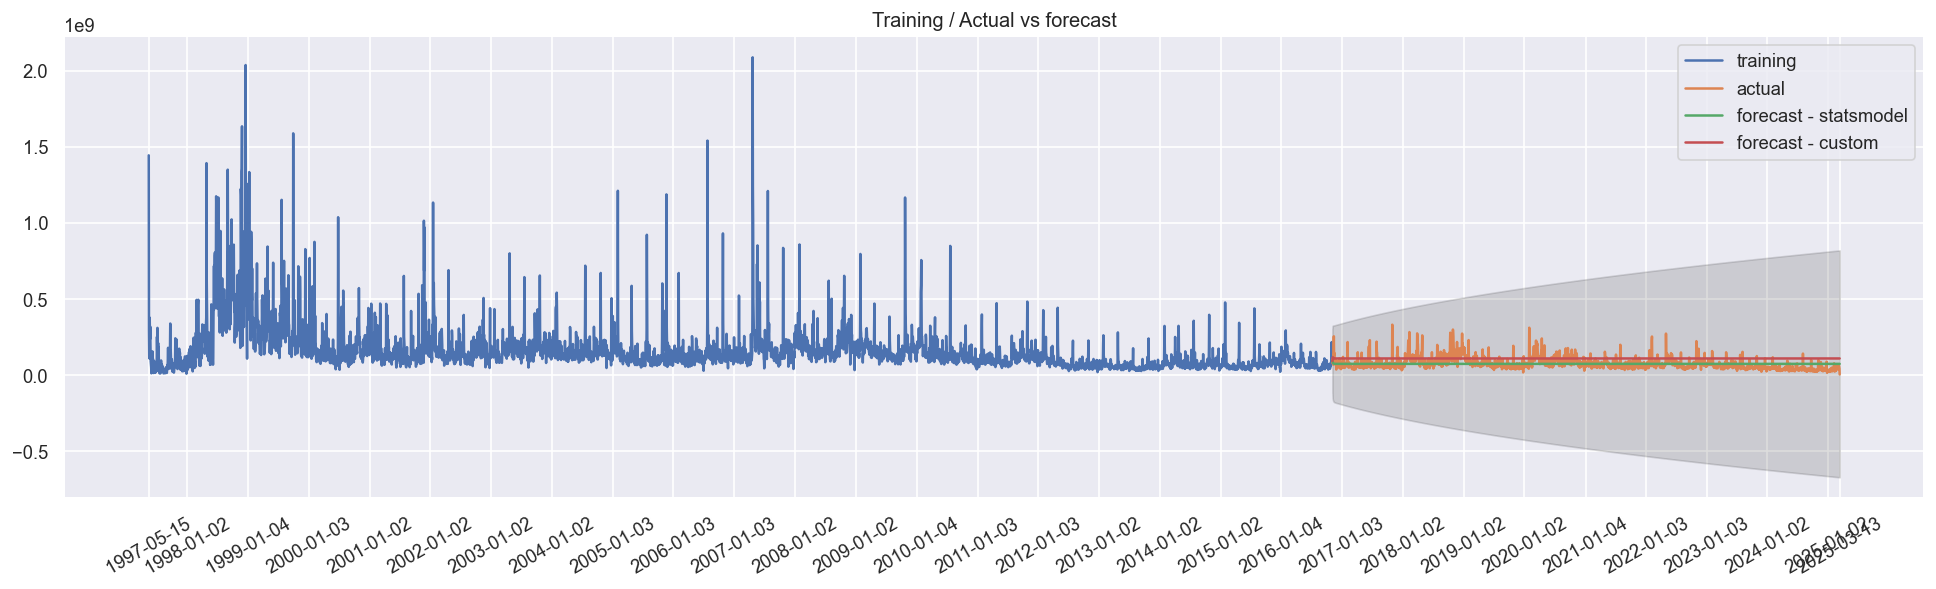

Train / Test based on:
order -> (3, 2, 1)
train_rate -> 0.8
                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                 5600
Model:                 ARIMA(3, 2, 1)   Log Likelihood             -111462.115
Date:                Thu, 13 Mar 2025   AIC                         222934.231
Time:                        15:55:57   BIC                         222967.381
Sample:                             0   HQIC                        222945.783
                               - 5600                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3246      0.007    -46.323      0.000      -0.338      -0.311
ar.L2         -0.2856      0.009    -32.957      0.000      -0.303     

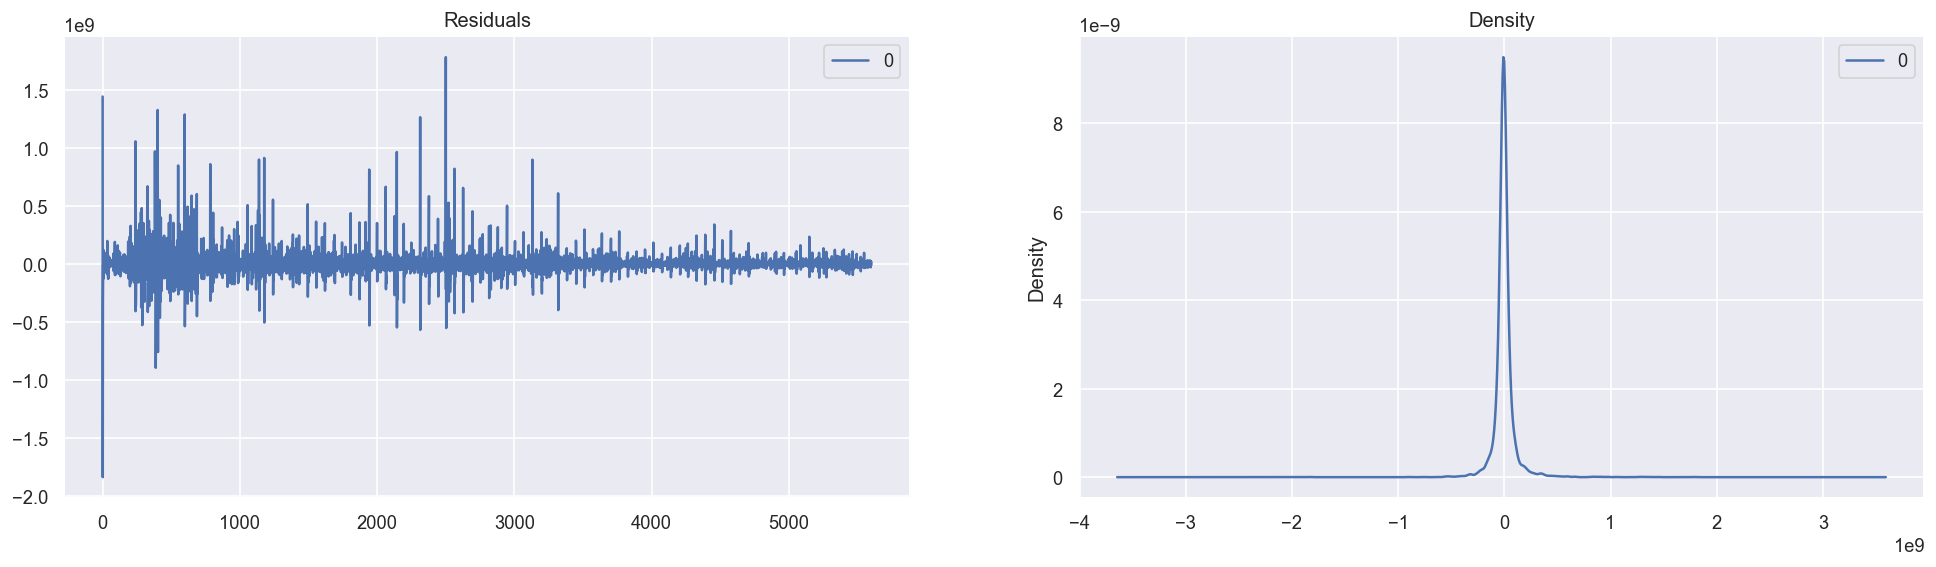

c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['alpha']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


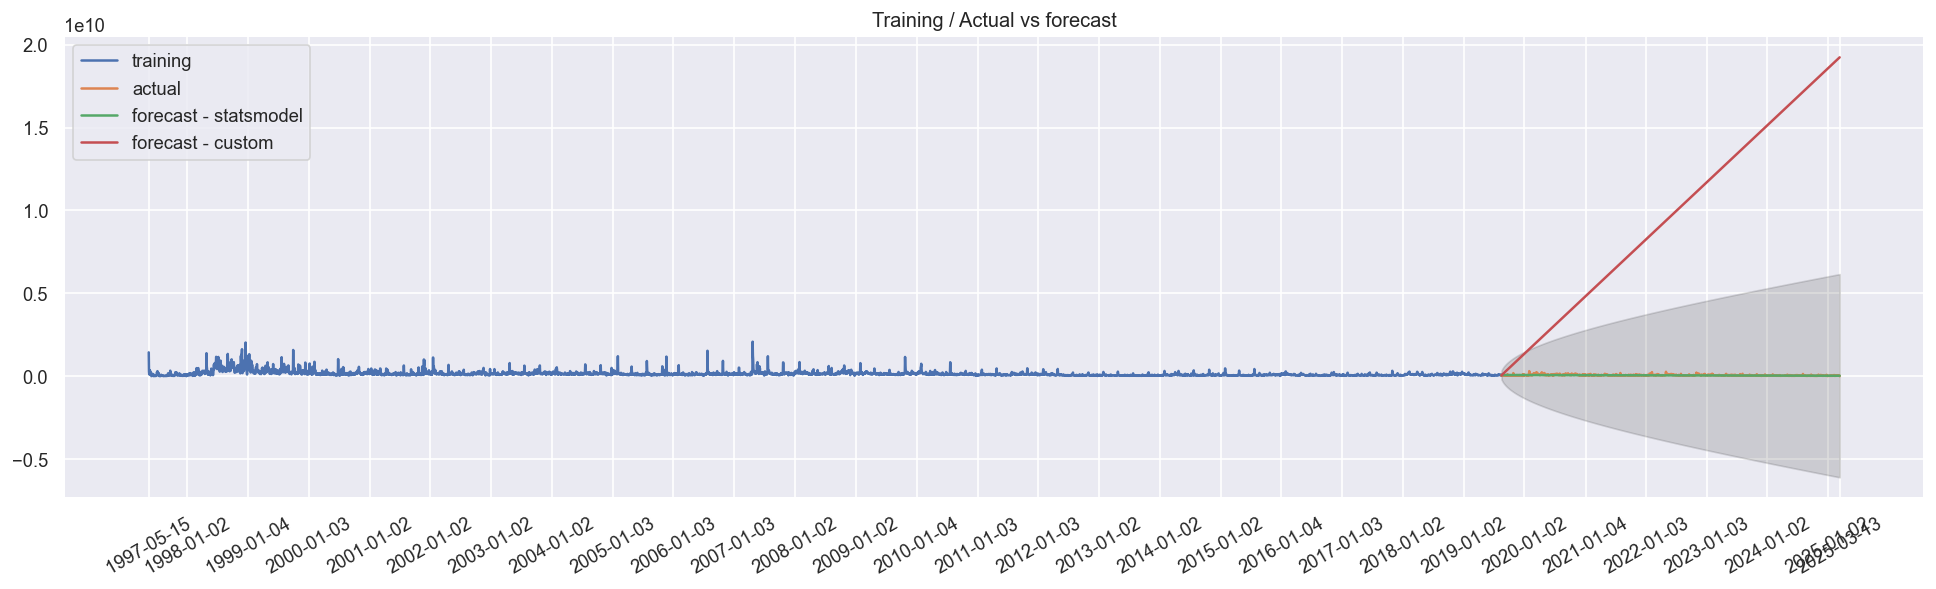

Train / Test based on:
order -> (4, 1, 3)
train_rate -> 0.8


c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                 5600
Model:                 ARIMA(4, 1, 3)   Log Likelihood             -110989.696
Date:                Thu, 13 Mar 2025   AIC                         221995.392
Time:                        15:56:22   BIC                         222048.434
Sample:                             0   HQIC                        222013.876
                               - 5600                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1470      0.169     -0.872      0.383      -0.478       0.184
ar.L2          0.6363      0.085      7.472      0.000       0.469       0.803
ar.L3         -0.1571      0.083     -1.896      0.0

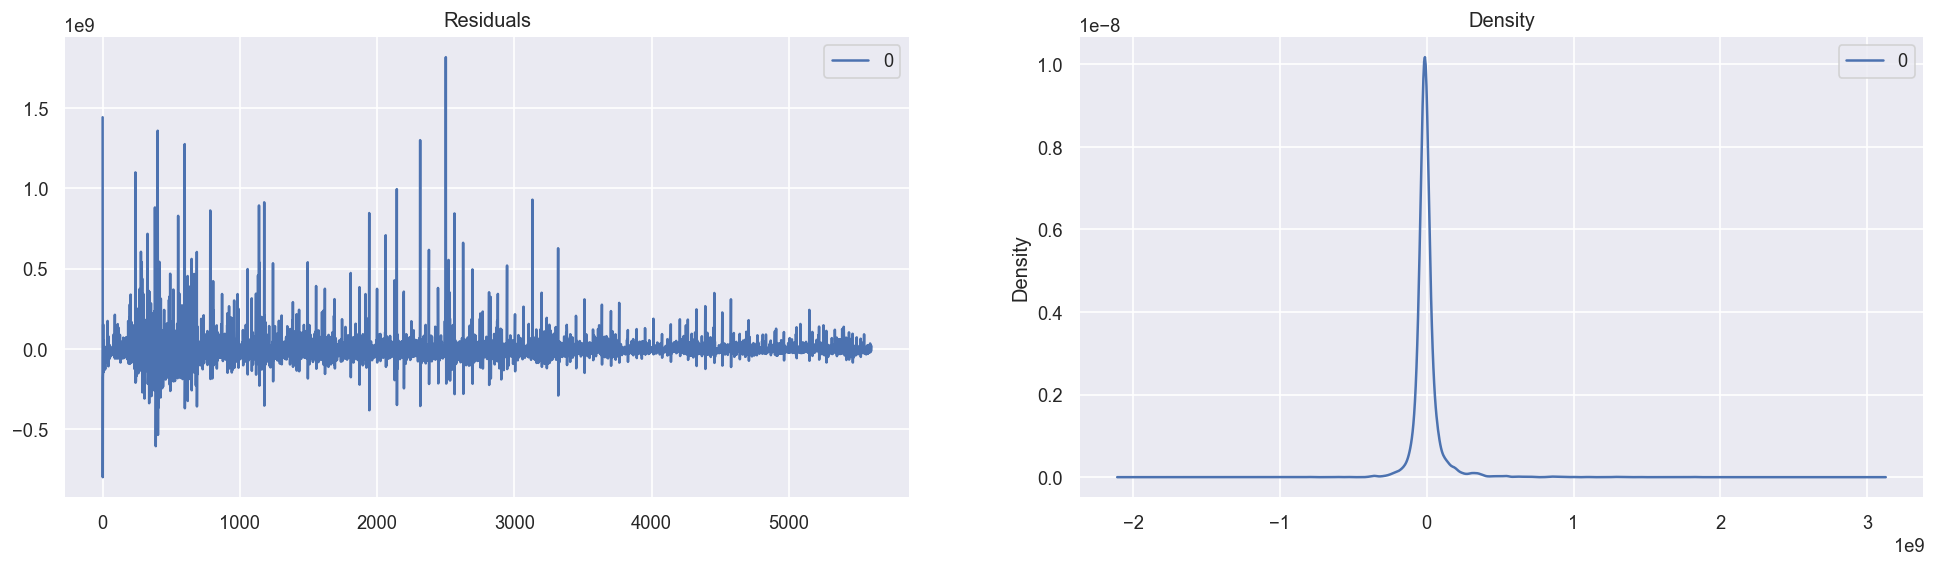

c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['alpha']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


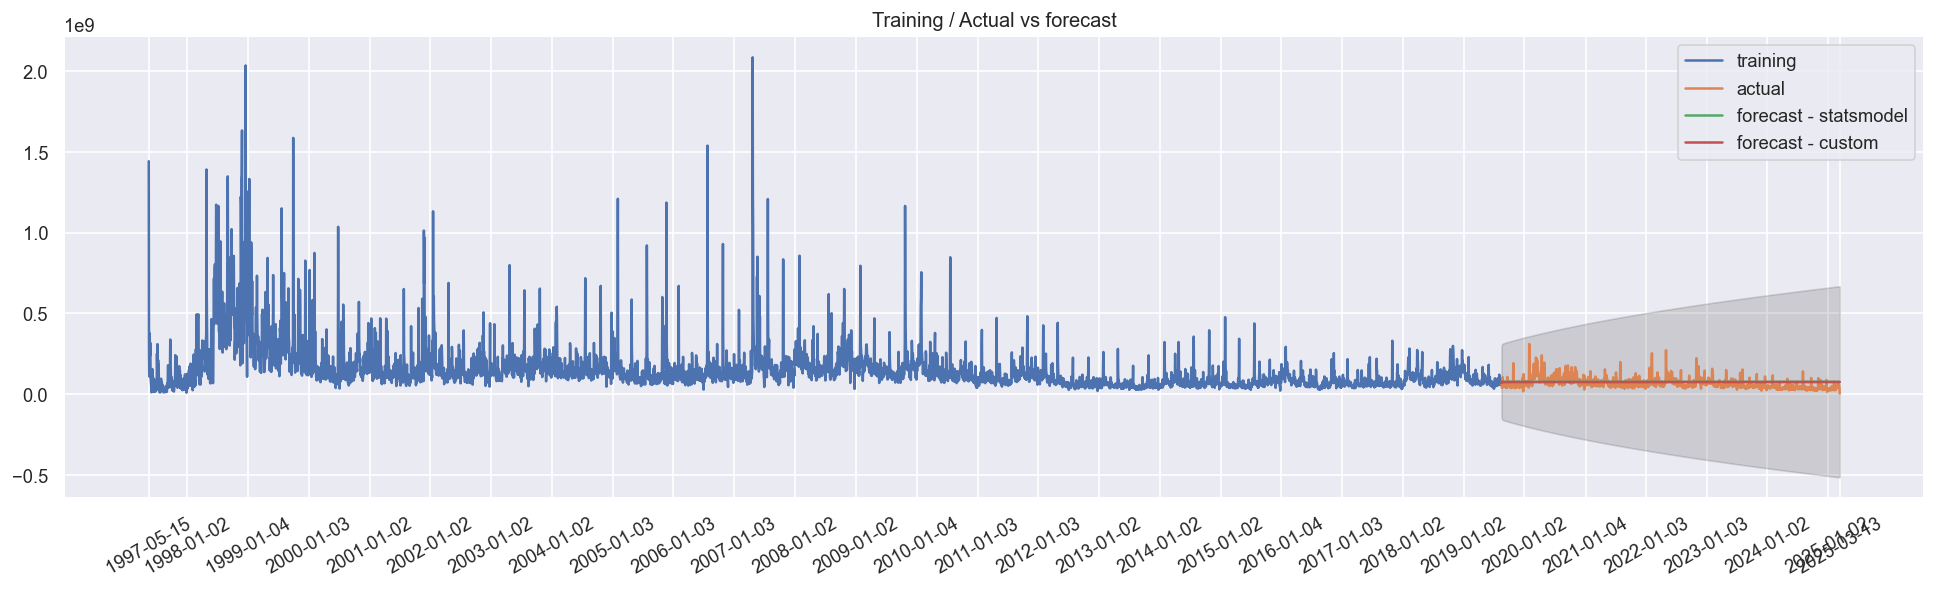

Train / Test based on:
order -> (3, 2, 1)
train_rate -> 0.9
                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                 6300
Model:                 ARIMA(3, 2, 1)   Log Likelihood             -125058.373
Date:                Thu, 13 Mar 2025   AIC                         250126.745
Time:                        15:56:40   BIC                         250160.485
Sample:                             0   HQIC                        250138.434
                               - 6300                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3246      0.006    -51.591      0.000      -0.337      -0.312
ar.L2         -0.2858      0.008    -36.766      0.000      -0.301     

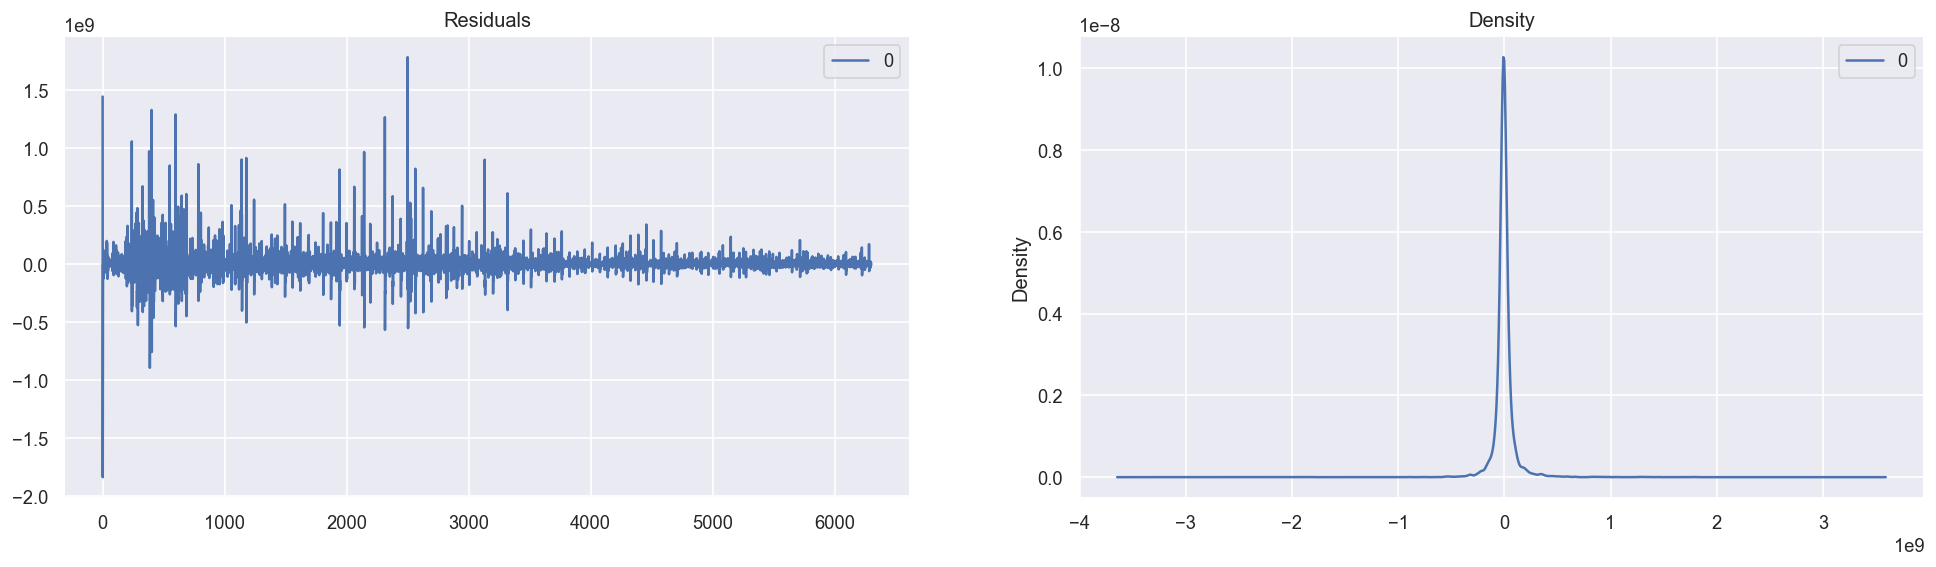

c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['alpha']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


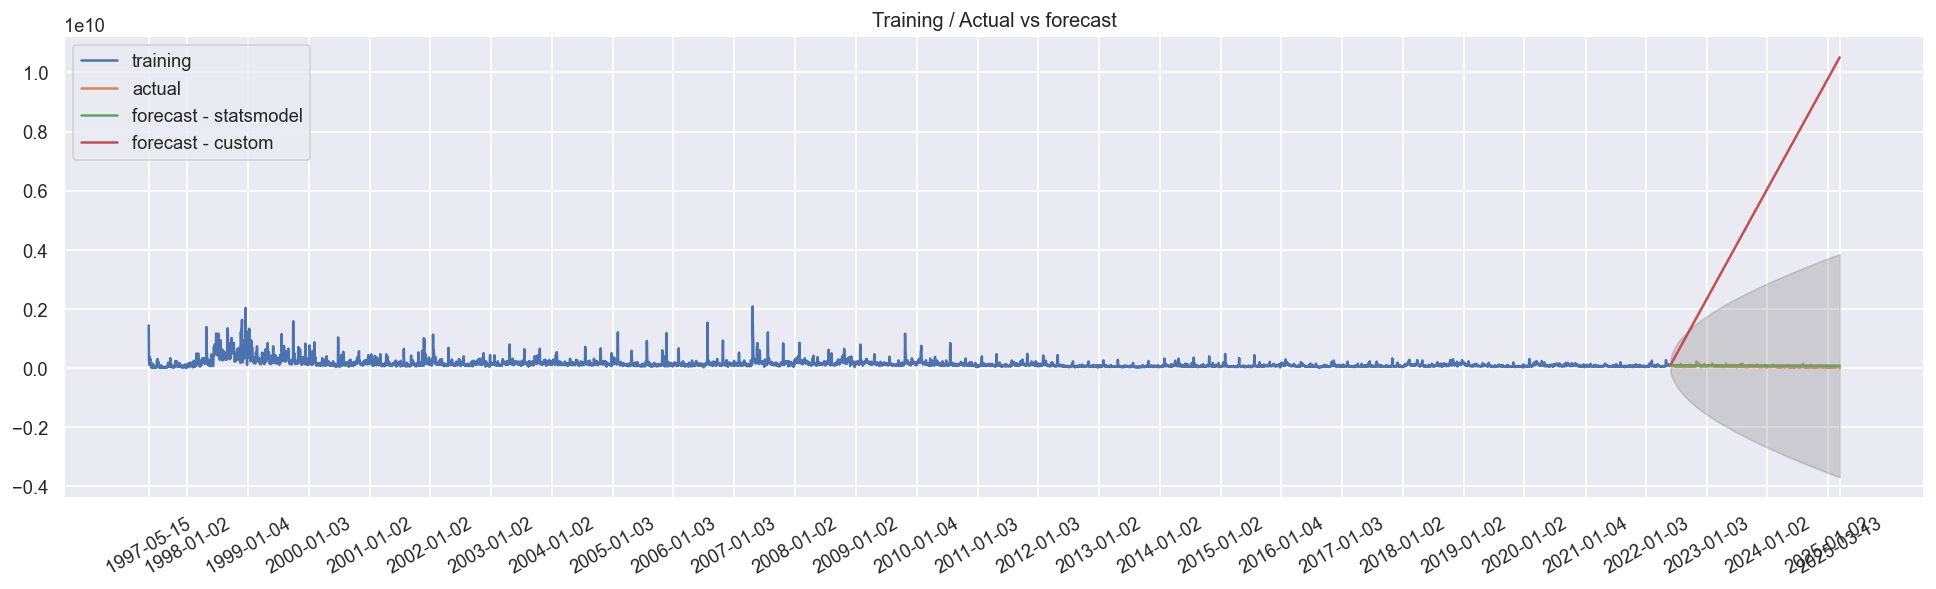

In [25]:
hyperparams = [{
    "order": (1, 1, 2),
    "train_rate": 0.7
},{
    "order": (1, 1, 1),
    "train_rate": 0.7
},{
    "order": (3, 2, 3),
     "train_rate": 0.7
},{
    "order": (3, 2 ,1),
     "train_rate": 0.7
},{
    "order": (4, 1, 3),
    "train_rate": 0.7
},{
    "order": (3, 2 ,1),
     "train_rate": 0.8
},{
    "order": (4, 1, 3),
    "train_rate": 0.8
},{
    "order": (3, 2 ,1),
     "train_rate": 0.9
}]

# Monthly correlation
SAMPLES_PER_LAG = 30

for dataset_type, dataset in datasets.items():
    date_labels = get_date_labels_amzn(dataset)

    #print(date_labels)
    
    plot_acf(dataset.value, f"Original Dataset -> {dataset_type}", SAMPLES_PER_LAG)
    print("==================================================================================================")
    for idx, hyperparam in enumerate(hyperparams):
        predicted_dataset = run_arima_train_test(dataset, hyperparam, date_labels)
        print("==================================================================================================")

# Use of generative AI

Please use the cell below to describe your use of generative AI in this assignment.


In this assignment we used ChatGPT in explenations and especially during the documentation part. We wanted to have an information about each term and what does it exactly means, so ChatGPT gave a great summary